# 12 — STEMI v2: xác minh dữ liệu, trực quan hoá ca khó, hiệu chuẩn ensemble

**Bản cải tiến từ [`08_stemi_stability_calibration.ipynb`](08_stemi_stability_calibration.ipynb) dựa trên gói TIP-STEMI (TIP-01→05)** — vá 5 điểm hở phát hiện từ error analysis mục 22–23 của notebook 08: xác minh 2 bản ghi bị cắt ngắn, trực quan hoá 12 chuyển đạo cho ca khó nhất, định lượng độ nhất quán dự đoán nội bộ bệnh nhân đa-ECG, đối chiếu nhãn NSTEMI/UA riêng cho cụm FP cứng nhất, và thử ensemble hiệu chuẩn Platt cross-fit.

**Dự án ACS-ECG-AI (Vinmec)** · nối tiếp [`03_stemi_model_comparison.ipynb`](03_stemi_model_comparison.ipynb)

Notebook `03` xếp hạng mười kiến trúc trên **một** lần chia train/val, **một** seed. Chính nó cũng ghi
nhận chạy lại cùng cấu hình dao động **±0,015 AUROC**, mà `PlainCNN` (AUPRC 0,6675) chỉ hơn
`WBF-ensemble` (0,6648) và `ResNet1D` (0,6530) trong khoảng đó. Nghĩa là **thứ hạng ấy chưa có căn cứ**.

Notebook này trả lời ba câu hỏi:

1. **`PlainCNN` có thật sự tốt hơn không**, hay chênh lệch chỉ là nhiễu của một lần chạy? → 5-fold
   theo bệnh nhân, cùng bộ fold cho mọi model, kiểm định ghép cặp (mục 13–16).
2. **Ở cùng một điểm vận hành thì model nào hơn?** `Sensitivity` ở bảng cũ đo tại ngưỡng Youden's J
   riêng của từng model nên không so được với nhau. Mục 17 ép tất cả về cùng Specificity = 0,85.
3. **Xác suất đầu ra đọc được như xác suất thật không, và ngưỡng vận hành sai số bao nhiêu?**
   → hiệu chuẩn cross-fit (mục 18) và bootstrap CI theo bệnh nhân cho ngưỡng ba mức (mục 19).

**Phạm vi:** huấn luyện lại các model nằm trong vùng nhiễu **±0,015 AUROC** so với model đơn tốt
nhất của `03` (`XResNet1D`, AUROC 0,9297) — **8 ứng viên**: `PlainCNN`, `XResNet1D`, `ConvNeXtV2_1D`,
`AiTiAMI`, `ResNet1D`, `SEResNet1D`, `CNN+BiLSTM`, `InceptionTime1D`. `TCN1D` (0,9128, lệch 0,0169 —
vừa ngoài ngưỡng) và `Transformer1D` (0,7962, kém rõ rệt) không đưa vào; hai model này chỉ được
**chấm lại bằng checkpoint cũ** ở mục 17(a). `WBF-ensemble`/`Average-ensemble` không thể "huấn luyện
lại" vì là tổ hợp trọng số của cả mười model gốc; mục 14b dựng lại đúng công thức đó trên các ứng
viên đã qua K-Fold, đặt tên `WBF-CV`/`Average-CV` — không gắn số lượng cụ thể để không lỗi thời
khi danh sách ứng viên thay đổi, và không trùng với `WBF-ensemble`/`Average-ensemble` ở mục
17a (ensemble của cả 10 kiến trúc gốc từ notebook 03, khác hẳn phạm vi).

Notebook đã chạy đầy đủ 8 ứng viên (mục 14), model FINAL trên toàn bộ POOL (mục 14c), và
đánh giá trên TEST giữ riêng (mục 21b) — xem kết quả thật ở output từng mục.

**Tập test ẩn 10% không được chạm tới ở bất kỳ bước nào.**

## 1. Cài thư viện

Chỉ cài `wfdb` nếu môi trường chưa có. Trên Colab cần cài lại mỗi phiên (~10 giây).

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("wfdb") is None:
    print("Đang cài wfdb ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wfdb"], check=True)

import wfdb

print("wfdb", wfdb.__version__)

Đang cài wfdb ...
wfdb 4.3.1


## 2. Cấu hình

Notebook chạy được trên **Google Colab** và **máy cá nhân**, tự nhận diện môi trường.
Chỉ cần sửa đúng một chỗ:

- **Colab** → `DRIVE_PROJECT` (tên thư mục trên Drive chứa `datasets.zip`)
- **Máy cá nhân** → `LOCAL_DATA_ROOT`

Ngoài ra đổi `RUN_MODE` khi muốn chuyển từ chạy thử sang chạy thật.

**Thư mục `outputs/` chỉ giữ hai thứ:** checkpoint mô hình và cache tín hiệu. Hình và bảng số
đều hiển thị ngay trong notebook nên không ghi ra file nữa.

Trên Colab, cache đặt ở `/content` (nhanh, mất khi hết phiên) và được sao lưu lên Drive để phiên
sau khỏi tiền xử lý lại; checkpoint ghi thẳng lên Drive để không mất khi đứt phiên.

In [2]:
import os
from pathlib import Path

import torch

# ===================== CHẾ ĐỘ CHẠY =====================
RUN_MODE = "full"        # "debug" = 200 bản ghi / 3 epoch  |  "full" = toàn bộ / 30 epoch

# ===================== ĐƯỜNG DẪN =======================
IS_COLAB = importlib.util.find_spec("google.colab") is not None

if IS_COLAB:
    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")   # <<< SỬA nếu đặt tên khác
    DRIVE_DATA_ZIP = DRIVE_PROJECT / "datasets.zip"             # <<< SỬA nếu tên zip khác
    DATA_ROOT = Path("/content/datasets")      # giải nén ra đĩa local cho nhanh
    WORK_DIR = Path("/content/work")           # tạm, mất khi hết phiên
    PERSIST_DIR = DRIVE_PROJECT / "outputs"    # bền qua các phiên
else:
    LOCAL_DATA_ROOT = r"C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets"                    # <<< SỬA khi chạy máy cá nhân
    DATA_ROOT = Path(LOCAL_DATA_ROOT)
    WORK_DIR = DATA_ROOT.parent / "outputs"
    PERSIST_DIR = WORK_DIR

CACHE_DIR = WORK_DIR / "cache"                     # cache tín hiệu (sinh lại được)
MODEL_DIR = PERSIST_DIR / "models" / "stemi_compare"  # checkpoint (không được mất)
DRIVE_CACHE_DIR = (PERSIST_DIR / "cache") if IS_COLAB else None

# ===================== THAM SỐ =========================
SEED = 42
FS, SIGNAL_LEN, NUM_LEADS = 500, 5000, 12      # 12 chuyển đạo × 10 giây @ 500 Hz
BP_LOW, BP_HIGH, BP_ORDER = 0.5, 40.0, 3       # bandpass Butterworth
VAL_SIZE = 0.15                                 # chia theo bệnh nhân 85/15
LR, WEIGHT_DECAY = 1e-3, 1e-4
EARLY_STOP_PATIENCE, LR_PATIENCE = 10, 5
ECE_BINS = 10
TARGET_LABEL = "STEMI"
CLASS_NAME = "STEMI"

# Số bản ghi trong paper (tính trên toàn bộ 19.955); ta chỉ có nhãn cho 90% nên dung sai ±10%
PAPER_COUNTS = {"STEMI": 1513, "NSTEMI": 1274, "UA": 6197}
SANITY_TOL = 0.10

# ===================== SUY RA ==========================
GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if GPU_AVAILABLE else "cpu")
DEBUG_LIMIT = 200
EPOCHS = 3 if RUN_MODE == "debug" else 30
BATCH_SIZE = 8 if RUN_MODE == "debug" else (64 if GPU_AVAILABLE else 16)
USE_AMP = GPU_AVAILABLE

print("Môi trường :", "Google Colab" if IS_COLAB else "máy cá nhân")
print("Thiết bị   :", DEVICE)
print("Chế độ     :", RUN_MODE, f"({EPOCHS} epoch, batch {BATCH_SIZE})")
print("Nhãn đích  :", TARGET_LABEL)

# ============ K-FOLD + HIỆU CHUẨN (notebook 08) ============
ORIG_MODEL_DIR = MODEL_DIR                 # checkpoint của notebook 03 — CHỈ đọc, để inference lại
# "_holdout": thử nghiệm này train trên 85% (đã trích 15% làm TEST riêng ở mục 12b) -- khác dữ liệu
# với thử nghiệm K-Fold cũ (train trên toàn bộ 17.960 bản ghi). Đặt thư mục/tên file riêng để
# không ghi đè checkpoint và OOF của thử nghiệm cũ.
MODEL_DIR = PERSIST_DIR / "models" / "stemi_kfold_holdout"
OOF_DIR = PERSIST_DIR / "oof"

K_FOLDS = 5
N_REPEATS = 1          # 2 -> 10 cặp, Wilcoxon HAI phía mới đủ lực (xem mục 16). Gấp đôi chi phí GPU.
CANDIDATES = ["PlainCNN", "XResNet1D", "ConvNeXtV2_1D", "AiTiAMI", "ResNet1D",
              "SEResNet1D", "CNN+BiLSTM", "InceptionTime1D"]  # vùng nhiễu ±0,015 AUROC quanh model đơn tốt nhất (03)
SPEC_TARGET = 0.85     # điểm vận hành chung để so matched-threshold
RULE_OUT_NPV = 0.99    # ngưỡng rule-out lâm sàng
N_BOOTSTRAP = 1000
RUN_SWEEP = False      # True = chạy mục 20 (sweep hyperparameter), tốn thêm nhiều giờ GPU

N_FOLDS_RUN = 1 if RUN_MODE == "debug" else K_FOLDS   # debug chỉ chạy fold đầu

print("Ứng viên   :", ", ".join(CANDIDATES))
print("K-Fold     :", f"{K_FOLDS} fold × {N_REPEATS} lần lặp, chạy {N_FOLDS_RUN} fold ở chế độ {RUN_MODE}")
print("Checkpoint :", MODEL_DIR)

Môi trường : Google Colab
Thiết bị   : cuda
Chế độ     : full (30 epoch, batch 64)
Nhãn đích  : STEMI
Ứng viên   : PlainCNN, XResNet1D, ConvNeXtV2_1D, AiTiAMI, ResNet1D, SEResNet1D, CNN+BiLSTM, InceptionTime1D
K-Fold     : 5 fold × 1 lần lặp, chạy 5 fold ở chế độ full
Checkpoint : /content/drive/MyDrive/ACS-ECG-AI/outputs/models/stemi_kfold_holdout


### 2b. Chuẩn bị dữ liệu

Trên máy cá nhân cell này chỉ tạo thư mục. Trên Colab nó mount Drive (sẽ hiện popup xin quyền —
đây là thao tác thủ công duy nhất), copy `datasets.zip` về `/content` rồi giải nén.

Phải đi vòng qua zip vì bộ dữ liệu có **59.867 file**, mà Drive tính mỗi lần mở file là một lệnh
gọi mạng — đọc trực tiếp từ Drive sẽ chậm hơn hàng chục lần.

In [3]:
import shutil
import time
import zipfile


def _locate_data_root(search_root: Path) -> Path:
    """Tìm thư mục thật chứa dữ liệu, chịu được việc zip có bọc thêm lớp thư mục."""
    wanted = {"csv", "row_data", "raw_data", "med_data"}
    best, best_score = search_root, -1
    for cand in [search_root, *[p for p in search_root.rglob("*") if p.is_dir()]]:
        try:
            names = {c.name.lower() for c in cand.iterdir() if c.is_dir()}
        except OSError:
            continue
        if len(names & wanted) > best_score:
            best, best_score = cand, len(names & wanted)
        if best_score >= 2:
            break
    return best


def stage_colab_data() -> Path:
    marker = DATA_ROOT / ".staged_ok"
    if marker.exists():
        real = Path(marker.read_text().strip())
        print("Dữ liệu đã sẵn sàng:", real)
        return real

    if not DRIVE_DATA_ZIP.exists():
        có_gì = sorted(p.name for p in DRIVE_PROJECT.iterdir())[:40]
        raise FileNotFoundError(
            f"Không thấy {DRIVE_DATA_ZIP}\nTrong {DRIVE_PROJECT} hiện có: {có_gì}"
        )

    local_zip = Path("/content/_dataset.zip")
    size = DRIVE_DATA_ZIP.stat().st_size
    if not (local_zip.exists() and local_zip.stat().st_size == size):
        print(f"Copy zip {size / 1024 ** 3:.2f} GB từ Drive ...")
        t0 = time.time()
        shutil.copy2(DRIVE_DATA_ZIP, local_zip)
        print(f"  {time.time() - t0:.0f}s")

    extract_to = Path("/content/_extract")
    if extract_to.exists():
        shutil.rmtree(extract_to)
    print("Giải nén ...")
    t0 = time.time()
    with zipfile.ZipFile(local_zip) as zf:
        zf.extractall(extract_to)
    print(f"  {time.time() - t0:.0f}s")

    real = _locate_data_root(extract_to)
    real.mkdir(parents=True, exist_ok=True)
    (real / ".staged_ok").write_text(str(real))
    return real


if IS_COLAB:
    if str(DRIVE_PROJECT).startswith(("http://", "https://", "www.")):
        raise ValueError(
            "DRIVE_PROJECT đang là URL chia sẻ Drive. Phải là đường dẫn sau khi mount:\n"
            '    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")'
        )
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    if not DRIVE_PROJECT.exists():
        my = Path("/content/drive/MyDrive")
        có_gì = sorted(p.name for p in my.iterdir() if p.is_dir())[:40] if my.exists() else []
        raise FileNotFoundError(
            f"Không thấy {DRIVE_PROJECT}\nCác thư mục trong MyDrive: {có_gì}"
        )

for d in [CACHE_DIR, MODEL_DIR] + ([DRIVE_CACHE_DIR] if DRIVE_CACHE_DIR else []):
    d.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    DATA_ROOT = stage_colab_data()

print("DATA_ROOT:", DATA_ROOT, "| tồn tại:", DATA_ROOT.exists())

Mounted at /content/drive
Copy zip 1.33 GB từ Drive ...
  22s
Giải nén ...
  27s
DATA_ROOT: /content/_extract/datasets | tồn tại: True


## 3. Seed & GPU

In [4]:
import random

import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Input cố định (12 × 5000) nên cuDNN chọn thuật toán nhanh nhất một lần rồi giữ nguyên.
# Đánh đổi: epoch đầu chậm hơn vài giây, và kết quả không tái lập chính xác 100%.
torch.backends.cudnn.benchmark = GPU_AVAILABLE

print("torch", torch.__version__, "| GPU:", torch.cuda.get_device_name(0) if GPU_AVAILABLE else "không có")
if IS_COLAB and not GPU_AVAILABLE:
    print("\n" + "!" * 70)
    print("!! COLAB KHÔNG CÓ GPU -> Runtime > Change runtime type > GPU, rồi Run all lại.")
    print("!" * 70)

torch 2.11.0+cu128 | GPU: NVIDIA A100-SXM4-40GB


## 4. Dữ liệu và nhãn

Nhãn chỉ có trong `train.csv` (phần 90% chính thức). `test.csv` là tập test ẩn, không có cột nhãn
và **không bao giờ được đọc** trong notebook này.

Sanity check đối chiếu số ca với paper. Dung sai ±10% chứ không phải ±2%, vì số của paper tính trên
toàn bộ 19.955 bản ghi còn ta chỉ đếm được trên 90% có nhãn.

In [5]:
import pandas as pd

pd.set_option("display.width", 200)


def find_dir(root: Path, names):
    wanted = {n.lower() for n in names}
    for c in sorted(root.iterdir()):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    for c in root.rglob("*"):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    return None


RAW_DIR = find_dir(DATA_ROOT, ["row_data", "raw_data"])
CSV_DIR = find_dir(DATA_ROOT, ["CSV", "csv"])
assert RAW_DIR and CSV_DIR, f"Không thấy row_data/ hoặc CSV/ trong {DATA_ROOT}"

df_raw = pd.read_csv(CSV_DIR / "train.csv")
df_raw["record_stem"] = df_raw["ecg_row_record"].astype(str).str.replace(".dat", "", regex=False)

COL_PATIENT, COL_AGE, COL_GENDER = "Patient_id", "age", "gender"
print(f"{len(df_raw):,} bản ghi | {df_raw[COL_PATIENT].nunique():,} bệnh nhân | "
      f"{len(list(RAW_DIR.glob('*.dat'))):,} file .dat")

# --- Sanity check ---
print(f"\n{'nhãn':<8}{'đếm được':>11}{'paper':>9}{'lệch':>9}")
ok_all = True
for name, expected in PAPER_COUNTS.items():
    got = int(df_raw[name].sum())
    delta = (got - expected) / expected
    ok_all &= abs(delta) <= SANITY_TOL
    print(f"{name:<8}{got:>11,}{expected:>9,}{delta:>8.1%}   {'OK' if abs(delta) <= SANITY_TOL else 'LỆCH'}")
if not ok_all:
    print("\n!! CẢNH BÁO: số ca lệch quá ±10% so với paper — kiểm tra lại nguồn dữ liệu.")

# --- Nhãn đích ---
df_all = df_raw.copy()
df_all[TARGET_LABEL] = df_all["STEMI"].astype(int)
print("Nhãn = cột STEMI (lấy trực tiếp)")

n_pos = int(df_all[TARGET_LABEL].sum())
print(f"\nNhãn {TARGET_LABEL}: {n_pos:,} dương ({n_pos / len(df_all):.2%}) / "
      f"{len(df_all) - n_pos:,} âm")

17,960 bản ghi | 17,018 bệnh nhân | 19,955 file .dat

nhãn       đếm được    paper     lệch
STEMI         1,442    1,513   -4.7%   OK
NSTEMI        1,235    1,274   -3.1%   OK
UA            6,213    6,197    0.3%   OK
Nhãn = cột STEMI (lấy trực tiếp)

Nhãn STEMI: 1,442 dương (8.03%) / 16,518 âm


## 5. Lấy mẫu khi chạy thử

Ở `RUN_MODE="debug"` lấy 200 bản ghi **stratified** theo nhãn, để tập mẫu không rơi vào toàn 0
hoặc toàn 1 (khi đó mọi metric sẽ vô định).

In [6]:
from sklearn.model_selection import train_test_split

if RUN_MODE == "debug" and len(df_all) > DEBUG_LIMIT:
    df, _ = train_test_split(df_all, train_size=DEBUG_LIMIT,
                             stratify=df_all[TARGET_LABEL], random_state=SEED)
    df = df.reset_index(drop=True)
else:
    df = df_all.reset_index(drop=True)

n_pos = int(df[TARGET_LABEL].sum())
print(f"Dùng {len(df):,} bản ghi | {n_pos:,} dương ({n_pos / len(df):.2%})")
assert 0 < n_pos < len(df), "Tập chỉ có một lớp — không train được."

Dùng 17,960 bản ghi | 1,442 dương (8.03%)


## 7. Tiền xử lý và cache

Với mỗi bản ghi: đọc WFDB → NaN→0 → cắt/đệm về đúng 5000 mẫu → bandpass Butterworth 0,5–40 Hz
(`filtfilt`, zero-phase). **Chuẩn hoá z-score làm sau**, ở bước 9, với mean/std tính riêng trên tập
train để không rò rỉ thống kê của val sang train.

Lọc lại toàn bộ ở mỗi epoch là nút thắt cổ chai, nên tín hiệu đã lọc được cache **một lần** vào
memmap `float16` (~2,2 GB cho 17.960 bản ghi). Cache nối tiếp được nếu bị ngắt giữa chừng, và trên
Colab được sao lưu lên Drive.

> **Hai bản ghi lỗi trong dữ liệu gốc.** `03228` và `14262` có file `.dat` chỉ chứa 3.500/5.000 mẫu,
> khiến `wfdb.rdrecord()` báo lỗi. Hàm dưới bắt lỗi đó, đọc phần thực có rồi để bước zero-pad bù nốt.

In [7]:
import hashlib
import json

from scipy.signal import butter, filtfilt

_B, _A = butter(BP_ORDER, [BP_LOW / (FS / 2), BP_HIGH / (FS / 2)], btype="band")
TRUNCATED = []


def load_signal(stem: str) -> np.ndarray:
    path = str(RAW_DIR / stem)
    try:
        rec = wfdb.rdrecord(path)
    except ValueError:                     # .dat ngắn hơn header khai báo
        n_sig = int((RAW_DIR / f"{stem}.hea").read_text().splitlines()[0].split()[1])
        n = (RAW_DIR / f"{stem}.dat").stat().st_size // (n_sig * 2)
        rec = wfdb.rdrecord(path, sampto=n)
        TRUNCATED.append(stem)
    return np.asarray(rec.p_signal, dtype=np.float32).T


def preprocess(sig: np.ndarray) -> np.ndarray:
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    if sig.shape[1] < SIGNAL_LEN:
        sig = np.pad(sig, ((0, 0), (0, SIGNAL_LEN - sig.shape[1])))
    return np.ascontiguousarray(filtfilt(_B, _A, sig[:, :SIGNAL_LEN], axis=1), dtype=np.float32)


records = df["record_stem"].tolist()
_hash = hashlib.md5("|".join(records).encode()).hexdigest()[:8]
CACHE_NPY = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.npy"
CACHE_META = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.meta.json"


def _complete(meta_p: Path, npy_p: Path) -> bool:
    if not (meta_p.exists() and npy_p.exists()):
        return False
    try:
        return json.loads(meta_p.read_text()).get("n_done", 0) >= len(records)
    except (OSError, ValueError):
        return False


def build_cache() -> np.ndarray:
    # Colab: thử lấy lại cache của phiên trước từ Drive
    if DRIVE_CACHE_DIR and not _complete(CACHE_META, CACHE_NPY):
        d_npy, d_meta = DRIVE_CACHE_DIR / CACHE_NPY.name, DRIVE_CACHE_DIR / CACHE_META.name
        if _complete(d_meta, d_npy):
            print(f"Lấy cache từ Drive ({d_npy.stat().st_size / 1024 ** 3:.2f} GB) ...")
            t0 = time.time()
            shutil.copy2(d_npy, CACHE_NPY)
            shutil.copy2(d_meta, CACHE_META)
            print(f"  {time.time() - t0:.0f}s — bỏ qua tiền xử lý")

    if _complete(CACHE_META, CACHE_NPY):
        print("Cache đã đầy đủ:", CACHE_NPY.name)
        return np.load(CACHE_NPY, mmap_mode="r")

    meta = json.loads(CACHE_META.read_text()) if CACHE_META.exists() else {}
    start = int(meta.get("n_done", 0)) if CACHE_NPY.exists() else 0
    if start:
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="r+")
        print(f"Build tiếp từ {start}/{len(records)}")
    else:
        print(f"Build cache {len(records):,} bản ghi "
              f"(~{len(records) * NUM_LEADS * SIGNAL_LEN * 2 / 1024 ** 3:.2f} GB)")
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="w+", dtype=np.float16,
                                        shape=(len(records), NUM_LEADS, SIGNAL_LEN))

    t0 = time.time()
    step = max(1, len(records) // 8)
    for i in range(start, len(records)):
        arr[i] = preprocess(load_signal(records[i])).astype(np.float16)
        if (i + 1) % step == 0 or i + 1 == len(records):
            arr.flush()
            CACHE_META.write_text(json.dumps({"n_done": i + 1}))
            el = max(time.time() - t0, 1e-6)
            done = i + 1 - start
            print(f"  {i + 1:>6,}/{len(records):,}  {done / el:5.0f} rec/s  "
                  f"ETA {(len(records) - i - 1) / (done / el):4.0f}s")
    del arr
    print(f"Xong trong {time.time() - t0:.0f}s")

    if DRIVE_CACHE_DIR:
        print("Sao lưu cache lên Drive ...")
        shutil.copy2(CACHE_NPY, DRIVE_CACHE_DIR / CACHE_NPY.name)
        shutil.copy2(CACHE_META, DRIVE_CACHE_DIR / CACHE_META.name)
    return np.load(CACHE_NPY, mmap_mode="r")


CACHE = build_cache()
print("Cache:", CACHE.shape, CACHE.dtype)
if TRUNCATED:
    print(f"Bản ghi bị cắt ngắn, đã zero-pad: {TRUNCATED}")

Lấy cache từ Drive (2.01 GB) ...
  18s — bỏ qua tiền xử lý
Cache đã đầy đủ: sig_full_n17960_c20c6dba.npy
Cache: (17960, 12, 5000) float16


## 9. Chia train/val theo bệnh nhân

Bắt buộc chia theo `Patient_id`: một bệnh nhân có thể có nhiều ECG trong 7 ngày trước DSA, chia theo
bản ghi sẽ khiến cùng một người xuất hiện ở cả train lẫn val.

Stratify ở **cấp bệnh nhân** (lấy `max` nhãn của người đó) — cần thiết vì có bệnh nhân mang nhãn
không đồng nhất giữa các bản ghi của chính mình (xem mục 6).

Ngay sau khi chia, mean/std cho z-score được tính **chỉ trên các bản ghi thuộc train**.

In [8]:
pat = df.groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
strat = pat[TARGET_LABEL] if pat[TARGET_LABEL].value_counts().min() >= 2 else None
pat_tr, pat_va = train_test_split(pat, test_size=VAL_SIZE, stratify=strat, random_state=SEED)

train_idx = df.index[df[COL_PATIENT].isin(set(pat_tr[COL_PATIENT]))].to_numpy()
val_idx = df.index[df[COL_PATIENT].isin(set(pat_va[COL_PATIENT]))].to_numpy()
y = df[TARGET_LABEL].values.astype(np.float32)

assert not (set(pat_tr[COL_PATIENT]) & set(pat_va[COL_PATIENT])), "RÒ RỈ: bệnh nhân ở cả 2 tập"
print("Giao nhau patient_id: RỖNG -> OK\n")

display(pd.DataFrame({
    "tập": ["train", "val"],
    "bệnh nhân": [len(pat_tr), len(pat_va)],
    "bản ghi": [len(train_idx), len(val_idx)],
    "dương": [int(y[train_idx].sum()), int(y[val_idx].sum())],
    "tỷ lệ dương": [f"{y[train_idx].mean():.2%}", f"{y[val_idx].mean():.2%}"],
}))


def norm_stats(idx, chunk=256):
    order = np.sort(np.asarray(idx))
    s = np.zeros(NUM_LEADS)
    ss = np.zeros(NUM_LEADS)
    cnt = 0
    for i in range(0, len(order), chunk):
        b = np.asarray(CACHE[order[i:i + chunk]], dtype=np.float64)
        s += b.sum(axis=(0, 2))
        ss += (b ** 2).sum(axis=(0, 2))
        cnt += b.shape[0] * b.shape[2]
    m = s / cnt
    return m.astype(np.float32), np.sqrt(np.maximum(ss / cnt - m ** 2, 1e-12)).astype(np.float32)


LEAD_MEAN, LEAD_STD = norm_stats(train_idx)
print(f"\nz-score fit trên {len(train_idx):,} bản ghi TRAIN")

Giao nhau patient_id: RỖNG -> OK



,tập,bệnh nhân,bản ghi,dương,tỷ lệ dương
0,train,14465,15264,1225,8.03%
1,val,2553,2696,217,8.05%



z-score fit trên 15,264 bản ghi TRAIN


## 10. Dataset & DataLoader

In [9]:
from torch.utils.data import DataLoader, Dataset


class ECGDataset(Dataset):
    """Khác notebook 03 đúng một chỗ: nhận mean/std làm tham số.

    z-score phải fit lại trên tập train CỦA TỪNG FOLD, không dùng chung một bộ
    thống kê toàn cục được — nếu không thì thống kê của fold này rò rỉ sang fold kia.
    Mặc định vẫn là LEAD_MEAN/LEAD_STD của lần chia 85/15 gốc, để mục 17
    (nạp lại checkpoint cũ) chuẩn hoá y hệt lúc các model đó được huấn luyện.
    """

    def __init__(self, indices, labels, mean=None, std=None):
        self.indices = np.asarray(indices)
        self.labels = np.asarray(labels, dtype=np.float32)
        self.mean = (LEAD_MEAN if mean is None else mean).reshape(-1, 1)
        self.std = (LEAD_STD if std is None else std).reshape(-1, 1)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x = np.asarray(CACHE[self.indices[i]], dtype=np.float32)
        return torch.from_numpy((x - self.mean) / self.std), torch.tensor(self.labels[i])


# Windows tạo worker bằng spawn (mỗi worker nạp lại cả notebook) nên để 0; Linux dùng fork -> 2
NUM_WORKERS = 0 if os.name == "nt" else 2
_extra = dict(persistent_workers=True, prefetch_factor=4) if NUM_WORKERS else {}


def make_loaders(tr_idx, va_idx, mean=None, std=None):
    ds_tr = ECGDataset(tr_idx, y[tr_idx], mean, std)
    ds_va = ECGDataset(va_idx, y[va_idx], mean, std)
    tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
    va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
    return tr, va


# Loader của lần chia 85/15 GỐC — chỉ dùng ở mục 17 để chấm lại checkpoint của notebook 03
train_loader, val_loader = make_loaders(train_idx, val_idx)

xb, yb = next(iter(val_loader))
print(f"batch: {tuple(xb.shape)} {xb.dtype} | nhãn {tuple(yb.shape)} | "
      f"{len(train_loader)} batch train, {len(val_loader)} batch val (split 85/15 gốc)")

batch: (64, 12, 5000) torch.float32 | nhãn (64,) | 239 batch train, 43 batch val (split 85/15 gốc)


## 11. Hàm tính metric

`compute_metrics` an toàn với tập nhỏ: khi chỉ có một lớp hoặc mẫu số bằng 0, trả `nan` thay vì
ném lỗi hay trả 0 gây hiểu nhầm.

`per_class_report` cho bảng tách riêng **lớp âm tính (0)** và **lớp dương tính (1)** — mỗi lớp có
Precision/Recall/F1/Support riêng, kèm hai dòng trung bình macro và weighted.

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score)

plt.rcParams["figure.dpi"] = 110


def _div(a, b):
    return float(a) / float(b) if b else float("nan")


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob, dtype=np.float64).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    two = len(np.unique(y_true)) == 2
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, y_prob) if two else float("nan"),
        "auprc": average_precision_score(y_true, y_prob) if two else float("nan"),
        "sensitivity": _div(tp, tp + fn), "specificity": _div(tn, tn + fp),
        "ppv": _div(tp, tp + fp), "npv": _div(tn, tn + fn),
        "f1": _div(2 * tp, 2 * tp + fp + fn),
        "accuracy": _div(tp + tn, tp + tn + fp + fn),
        "brier": float(brier_score_loss(y_true, y_prob)) if two else float("nan"),
        "threshold": float(threshold),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "n": int(len(y_true)), "n_pos": int(y_true.sum()),
    }


def per_class_report(y_true, y_prob, threshold):
    """Bảng metric TÁCH RIÊNG cho lớp 0 và lớp 1, kiểu classification_report của sklearn."""
    y_true = np.asarray(y_true).astype(int).ravel()
    y_pred = (np.asarray(y_prob).ravel() >= threshold).astype(int)
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    rows = [
        {"Class": f"Negative (0) — không {CLASS_NAME}", "Precision": p[0], "Recall": r[0],
         "F1": f[0], "Support": int(s[0])},
        {"Class": f"Positive (1) — {CLASS_NAME}", "Precision": p[1], "Recall": r[1],
         "F1": f[1], "Support": int(s[1])},
    ]
    w = s / s.sum()
    rows.append({"Class": "macro avg", "Precision": p.mean(), "Recall": r.mean(),
                 "F1": f.mean(), "Support": int(s.sum())})
    rows.append({"Class": "weighted avg", "Precision": float(p @ w), "Recall": float(r @ w),
                 "F1": float(f @ w), "Support": int(s.sum())})
    return pd.DataFrame(rows).set_index("Class")


def style_df(df, pct_cols):
    fmt = {c: "{:.4f}" for c in pct_cols}
    fmt.update({c: "{:,d}" for c in df.columns if c not in pct_cols and df[c].dtype.kind in "iu"})
    try:
        return df.style.format(fmt, na_rep="n/a").background_gradient(
            cmap="Blues", vmin=0, vmax=1, subset=[c for c in pct_cols if c in df.columns])
    except Exception:
        return df.round(4)


print("self-test:", {k: round(v, 3) for k, v in
                     compute_metrics([0, 0, 1, 1], [.1, .4, .35, .8]).items()
                     if k in ("auroc", "f1", "sensitivity")})

self-test: {'auroc': np.float64(0.75), 'sensitivity': 0.5, 'f1': 0.667}


## 12. Mười kiến trúc

Tất cả nhận input `(batch, 12, 5000)` và trả về **một logit** cho mỗi mẫu, nên có thể thay thế nhau
trong đúng một vòng lặp huấn luyện.

Cả mười đều hạ chiều thời gian khá mạnh (5000 → vài chục/vài trăm) trước khi gộp, vì tín hiệu 10
giây ở 500 Hz là quá dài để giữ nguyên độ phân giải qua nhiều tầng.

> ⚠️ **`AiTiAMI` là tái hiện theo mô tả kiến trúc, không phải model/trọng số gốc.** Lee *et al.*
> (*Eur Heart J* 2025, ehaf004 — nghiên cứu ROMIAE) chỉ mô tả AiTiAMI v1.00.00 của Medical AI Co.
> là "an advanced algorithm... built on a residual neural network", đầu vào 500Hz 12 chuyển đạo
> thô, đầu ra điểm xác suất AMI 0-100. Không có chi tiết số khối, độ sâu, hay trọng số công khai —
> class `AiTiAMI` dưới đây là một ResNet1D sâu/rộng hơn `ResNet1D` sẵn có, kernel hẹp hơn (5 thay
> vì 7) để bắt chi tiết QRS/ST mịn hơn, head kết hợp avg+max-pool. Kết quả của nó **không thể**
> dùng để so sánh trực tiếp với AUROC 0,971 (STEMI) mà bài báo báo cáo cho AiTiAMI thật — bài báo
> đó đánh giá trên dữ liệu và quần thể bệnh nhân Hàn Quốc hoàn toàn khác.

In [11]:
import torch.nn as nn


# ---------------------------------------------------------------- 1. PlainCNN
class PlainCNN(nn.Module):
    """Mốc sàn: Conv-BN-ReLU-MaxPool xếp chồng, không có gì đặc biệt."""

    def __init__(self, channels=(32, 64, 128, 256)):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in channels:
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.features(x)).squeeze(-1)


# ---------------------------------------------------------------- 2. ResNet1D
class ResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class ResNet1D(nn.Module):
    """Skip connection giúp gradient đi xuyên qua mạng sâu."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(ResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 3. InceptionTime1D
class InceptionModule(nn.Module):
    """Nhiều độ dài kernel song song -> bắt được cả sóng nhanh lẫn biến thiên chậm."""

    def __init__(self, c_in, n_filters=32, kernels=(39, 19, 9), bottleneck=32):
        super().__init__()
        self.bottleneck = nn.Conv1d(c_in, bottleneck, 1, bias=False)
        self.convs = nn.ModuleList(
            [nn.Conv1d(bottleneck, n_filters, k, padding=k // 2, bias=False) for k in kernels])
        self.pool_conv = nn.Sequential(nn.MaxPool1d(3, stride=1, padding=1),
                                       nn.Conv1d(c_in, n_filters, 1, bias=False))
        self.bn = nn.BatchNorm1d(n_filters * (len(kernels) + 1))
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b = self.bottleneck(x)
        return self.relu(self.bn(torch.cat([c(b) for c in self.convs] + [self.pool_conv(x)], 1)))


class InceptionTime1D(nn.Module):
    def __init__(self, n_filters=32, depth=6):
        super().__init__()
        # hạ tần số ngay từ đầu, nếu không 5000 mẫu × nhiều kênh sẽ quá nặng
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 4, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True))
        c_out = n_filters * 4
        self.blocks = nn.ModuleList()
        self.shortcuts = nn.ModuleList()
        self.pools = nn.ModuleList()
        c_in = 32
        res_c = 32          # số kênh của tensor dùng làm residual, KHÁC c_in của khối hiện tại
        for d in range(depth):
            self.blocks.append(InceptionModule(c_in, n_filters))
            # residual mỗi 3 khối, kèm hạ chiều thời gian
            if d % 3 == 2:
                self.shortcuts.append(nn.Sequential(nn.Conv1d(res_c, c_out, 1, bias=False),
                                                    nn.BatchNorm1d(c_out)))
                self.pools.append(nn.MaxPool1d(4))
                res_c = c_out
            else:
                self.shortcuts.append(None)
                self.pools.append(None)
            c_in = c_out
        self.relu = nn.ReLU(inplace=True)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_out, 1))

    def forward(self, x):
        x = self.stem(x)
        res = x
        for blk, short, pool in zip(self.blocks, self.shortcuts, self.pools):
            x = blk(x)
            if short is not None:
                x = self.relu(x + short(res))
                x = pool(x)
                res = x
        return self.head(x).squeeze(-1)


# ---------------------------------------------------------------- 4. CNN + BiLSTM
class CNNBiLSTM(nn.Module):
    """CNN rút đặc trưng cục bộ, BiLSTM mô hình hoá quan hệ theo thời gian giữa các nhịp."""

    def __init__(self, hidden=128):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in (32, 64, 128):
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.cnn = nn.Sequential(*layers)                       # 5000 -> ~78
        self.lstm = nn.LSTM(c_in, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden * 2, 1))

    def forward(self, x):
        h = self.cnn(x).transpose(1, 2)                          # (B, T, C)
        out, _ = self.lstm(h)
        return self.head(out.mean(dim=1)).squeeze(-1)            # gộp trung bình theo thời gian

# ---------------------------------------------------------------- 5. SEResNet1D
class SEBlock1D(nn.Module):
    """Squeeze-excitation: học trọng số quan trọng theo từng kênh (feature map)."""

    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(nn.Linear(channels, hidden), nn.ReLU(inplace=True),
                                nn.Linear(hidden, channels), nn.Sigmoid())

    def forward(self, x):
        w = self.fc(self.pool(x).squeeze(-1)).unsqueeze(-1)
        return x * w


class SEResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.se = SEBlock1D(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.se(self.bn2(self.conv2(out)))
        return self.relu(out + idt)


class SEResNet1D(nn.Module):
    """ResNet1D + squeeze-excitation sau mỗi khối."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(SEResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 6. Transformer1D
class Transformer1D(nn.Module):
    """Cắt tín hiệu thành patch theo thời gian, học vị trí, qua self-attention."""

    def __init__(self, patch_len=250, d_model=128, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        assert SIGNAL_LEN % patch_len == 0
        n_patches = SIGNAL_LEN // patch_len
        self.patch_len = patch_len
        self.proj = nn.Linear(NUM_LEADS * patch_len, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 4,
                                           dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, 1))

    def forward(self, x):
        b = x.shape[0]
        patches = x.unfold(-1, self.patch_len, self.patch_len)          # (B, 12, n_patches, patch_len)
        patches = patches.permute(0, 2, 1, 3).reshape(b, patches.shape[2], -1)
        tok = self.proj(patches)
        tok = torch.cat([self.cls_token.expand(b, -1, -1), tok], dim=1) + self.pos_embed
        out = self.norm(self.encoder(tok))
        return self.head(out[:, 0]).squeeze(-1)


# ---------------------------------------------------------------- 7. TCN1D
class TCNBlock1D(nn.Module):
    """Conv1D giãn nở (dilated), residual — receptive field rộng mà giữ độ phân giải thời gian."""

    def __init__(self, c_in, c_out, k=7, dilation=1, dropout=0.1):
        super().__init__()
        pad = (k - 1) * dilation // 2
        self.conv1 = nn.Conv1d(c_in, c_out, k, padding=pad, dilation=dilation, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, padding=pad, dilation=dilation, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1, bias=False)

    def forward(self, x):
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.short(x))


class TCN1D(nn.Module):
    def __init__(self, channels=(32, 64, 128, 128, 256, 256), dropout=0.15):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for i, c_out in enumerate(channels):
            blocks.append(TCNBlock1D(c_in, c_out, dilation=2 ** i, dropout=dropout))
            if i % 2 == 1:                       # hạ chiều thời gian định kỳ, không hạ mỗi lớp
                blocks.append(nn.MaxPool1d(2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 8. XResNet1D
class XResBlock1D(nn.Module):
    """Nhánh tắt kiểu xResNet: AvgPool + 1x1 conv thay vì strided conv khi downsample."""

    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.act = nn.SiLU(inplace=True)
        if stride == 1 and c_in == c_out:
            self.short = nn.Identity()
        else:
            self.short = nn.Sequential(
                nn.AvgPool1d(stride, ceil_mode=True), nn.Conv1d(c_in, c_out, 1, bias=False),
                nn.BatchNorm1d(c_out))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.act(self.bn1(self.conv1(x))))
        out = self.bn2(self.conv2(out))
        return self.act(out + idt)


class XResNet1D(nn.Module):
    """Stem sâu (3 conv nhỏ xếp chồng) thay vì 1 conv to + SiLU — biến thể tối ưu hoá của ResNet1D."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(NUM_LEADS, 32, 5, 2, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(XResBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.SiLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 9. ConvNeXtV2_1D
class GRN1D(nn.Module):
    """Global Response Normalization (ConvNeXt V2) — chuẩn hoá theo norm toàn cục của từng kênh."""

    def __init__(self, channels):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, channels))
        self.beta = nn.Parameter(torch.zeros(1, 1, channels))

    def forward(self, x):                          # x: (B, L, C)
        gx = torch.norm(x, p=2, dim=1, keepdim=True)
        nx = gx / (gx.mean(dim=-1, keepdim=True) + 1e-6)
        return self.gamma * (x * nx) + self.beta + x


class ConvNeXtV2Block1D(nn.Module):
    def __init__(self, channels, expand=4, dropout=0.1):
        super().__init__()
        self.dwconv = nn.Conv1d(channels, channels, 7, padding=3, groups=channels, bias=False)
        self.norm = nn.LayerNorm(channels)
        self.pw1 = nn.Linear(channels, channels * expand)
        self.act = nn.GELU()
        self.grn = GRN1D(channels * expand)
        self.pw2 = nn.Linear(channels * expand, channels)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):                           # x: (B, C, L)
        idt = x
        x = self.dwconv(x).transpose(1, 2)           # (B, L, C)
        x = self.norm(x)
        x = self.pw2(self.grn(self.act(self.pw1(x))))
        x = self.drop(x).transpose(1, 2)
        return x + idt


class ConvNeXtV2Downsample1D(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.norm = nn.BatchNorm1d(c_in)
        self.conv = nn.Conv1d(c_in, c_out, 2, stride=2, bias=False)

    def forward(self, x):
        return self.conv(self.norm(x))


class ConvNeXtV2_1D(nn.Module):
    """Khối depthwise-conv + LayerNorm + MLP mở rộng + GRN — bản 1D của ConvNeXt V2."""

    def __init__(self, channels=(32, 64, 128, 256), depths=(1, 1, 2, 1), dropout=0.1):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, channels[0], 4, stride=4, bias=False),
                                  nn.BatchNorm1d(channels[0]))
        stages, c_in = [], channels[0]
        for stage_i, (c_out, depth) in enumerate(zip(channels, depths)):
            if stage_i > 0:
                stages.append(ConvNeXtV2Downsample1D(c_in, c_out))
            stages += [ConvNeXtV2Block1D(c_out, dropout=dropout) for _ in range(depth)]
            c_in = c_out
        self.stages = nn.Sequential(*stages)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.LayerNorm(c_in), nn.Dropout(dropout), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.stages(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 10. AiTiAMI (tái hiện)
class AiTiAMIBlock1D(nn.Module):
    """Residual block chuẩn, kernel hẹp hơn ResNet1D (5 thay vì 7) để bắt chi tiết QRS/ST mịn hơn."""

    def __init__(self, c_in, c_out, k=5, stride=2, dropout=0.15):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class AiTiAMI(nn.Module):
    """Tái hiện theo MÔ TẢ KIẾN TRÚC trong Lee et al., Eur Heart J 2025 (ehaf004, ROMIAE):
    "an advanced algorithm... built on a residual neural network", đầu vào 500Hz 12 chuyển đạo.
    KHÔNG PHẢI model/trọng số gốc của Medical AI Co., Ltd — bài báo không công bố kiến trúc chi
    tiết (sản phẩm thương mại). Sâu hơn (5 stage) và rộng hơn ResNet1D, head avg+max-pool nối tiếp.
    """

    def __init__(self, channels=(48, 96, 192, 256, 320), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 48, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(48), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 48
        for i, c_out in enumerate(channels):
            blocks.append(AiTiAMIBlock1D(c_in, c_out, stride=2 if i < 4 else 1))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.maxpool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(c_in * 2, 128), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(128, 1))

    def forward(self, x):
        feat = self.blocks(self.stem(x))
        pooled = torch.cat([self.avgpool(feat), self.maxpool(feat)], dim=1)
        return self.head(pooled).squeeze(-1)


MODELS = {
    "PlainCNN": PlainCNN,
    "ResNet1D": ResNet1D,
    "InceptionTime1D": InceptionTime1D,
    "CNN+BiLSTM": CNNBiLSTM,
    "SEResNet1D": SEResNet1D,
    "Transformer1D": Transformer1D,
    "TCN1D": TCN1D,
    "XResNet1D": XResNet1D,
    "ConvNeXtV2_1D": ConvNeXtV2_1D,
    "AiTiAMI": AiTiAMI,
}


rows = []
for name, cls in MODELS.items():
    m = cls().to(DEVICE)
    with torch.no_grad():
        out = m(torch.zeros(2, NUM_LEADS, SIGNAL_LEN, device=DEVICE))
    rows.append({"Mô hình": name, "Tham số": sum(p.numel() for p in m.parameters()),
                 "Output": str(tuple(out.shape))})
    del m
torch.cuda.empty_cache() if GPU_AVAILABLE else None
display(pd.DataFrame(rows).set_index("Mô hình"))

,Tham số,Output
Mô hình,,
PlainCNN,304961,"(2,)"
ResNet1D,986753,"(2,)"
InceptionTime1D,483137,"(2,)"
CNN+BiLSTM,339265,"(2,)"
SEResNet1D,998273,"(2,)"
Transformer1D,1180417,"(2,)"
TCN1D,2116929,"(2,)"
XResNet1D,993281,"(2,)"
ConvNeXtV2_1D,929601,"(2,)"


## 12b. Trích tập TEST giữ riêng (15%, trước khi chia K-Fold)

Toàn bộ mục 13-21 (K-Fold, chọn model, chọn ngưỡng, hiệu chuẩn) từ giờ chỉ chạy trên **85% bệnh
nhân** (gọi là POOL) — 15% còn lại (TEST) bị **cách ly hoàn toàn**, không xuất hiện trong bất kỳ
bước train/chọn model/chọn ngưỡng/hiệu chuẩn nào. Đây là bước bắt buộc để có một tập đánh giá cổ
điển đúng nghĩa (train/val chọn mọi thứ, test chỉ đánh giá một lần cuối, không được nhìn thấy trước).

Chia theo bệnh nhân (như mọi chỗ khác trong notebook), seed riêng để không trùng với 5-fold hay lần
chia 85/15 gốc của notebook 03.

In [12]:
TEST_SIZE = 0.15

pat_all = df.groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
pat_pool, pat_test = train_test_split(pat_all, test_size=TEST_SIZE,
                                      stratify=pat_all[TARGET_LABEL], random_state=SEED + 200)
TEST_PATIENTS = set(pat_test[COL_PATIENT])
IS_TEST = df[COL_PATIENT].isin(TEST_PATIENTS).to_numpy()
POOL_IDX = df.index[~IS_TEST].to_numpy()
TEST_IDX = df.index[IS_TEST].to_numpy()

assert not (set(df.loc[POOL_IDX, COL_PATIENT]) & TEST_PATIENTS), "RÒ RỈ: bệnh nhân TEST lọt vào POOL"
assert len(POOL_IDX) + len(TEST_IDX) == len(df), "POOL + TEST không phủ đúng toàn bộ df"

display(pd.DataFrame({
    "tập": ["POOL (train+val, 5-fold)", "TEST (giữ riêng)"],
    "bệnh nhân": [len(pat_pool), len(pat_test)],
    "bản ghi": [len(POOL_IDX), len(TEST_IDX)],
    "dương": [int(y[POOL_IDX].sum()), int(y[TEST_IDX].sum())],
    "tỷ lệ dương": [f"{y[POOL_IDX].mean():.2%}", f"{y[TEST_IDX].mean():.2%}"],
}))
print("\nTừ đây, mục 13 (K-Fold) chỉ dùng POOL_IDX -- TEST_IDX không được chạm tới cho đến mục 21b.")

,tập,bệnh nhân,bản ghi,dương,tỷ lệ dương
0,"POOL (train+val, 5-fold)",14465,15279,1225,8.02%
1,TEST (giữ riêng),2553,2681,217,8.09%



Từ đây, mục 13 (K-Fold) chỉ dùng POOL_IDX -- TEST_IDX không được chạm tới cho đến mục 21b.


## 13. Chia K-Fold theo bệnh nhân

Thay lần chia 85/15 duy nhất bằng `StratifiedKFold` chạy trên **bảng cấp bệnh nhân** (nhãn của một
bệnh nhân = `max` nhãn các bản ghi của họ, đúng như mục 9). Chia ở cấp bệnh nhân rồi mới map ngược
về bản ghi là cách duy nhất đảm bảo cứng rằng không bệnh nhân nào xuất hiện ở hai fold — chia trực
tiếp theo bản ghi sẽ rò rỉ, vì 855 bệnh nhân có nhiều hơn một ECG.

**Cùng một bộ fold dùng cho cả ba ứng viên** — đó là điều kiện để so sánh ở mục 16 là *paired*
(so từng fold một), chứ không phải so hai giá trị trung bình rời rạc.

In [13]:
from sklearn.model_selection import StratifiedKFold

pat_tbl = df.loc[POOL_IDX].groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
POS_RATE_ALL = float(y[POOL_IDX].mean())

FOLDS = {}          # (rep, k) -> (train_idx, val_idx) -- CHỈ trong POOL_IDX, không đụng TEST_IDX
for rep in range(N_REPEATS):
    skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED + rep)
    for k, (_, va_pos) in enumerate(skf.split(pat_tbl, pat_tbl[TARGET_LABEL])):
        va_pats = set(pat_tbl.iloc[va_pos][COL_PATIENT])
        in_va_pool = df.loc[POOL_IDX, COL_PATIENT].isin(va_pats).to_numpy()
        FOLDS[(rep, k)] = (POOL_IDX[~in_va_pool], POOL_IDX[in_va_pool])

# --- AC1: không bệnh nhân nào ở hai fold, không ai lọt vào TEST, mọi bản ghi POOL được val đúng 1 lần ---
for rep in range(N_REPEATS):
    seen = set()
    for k in range(K_FOLDS):
        pats_k = set(df.loc[FOLDS[(rep, k)][1], COL_PATIENT])
        assert not (seen & pats_k), f"RÒ RỈ: bệnh nhân nằm ở hai fold (rep {rep}, fold {k})"
        assert not (pats_k & TEST_PATIENTS), f"RÒ RỈ: bệnh nhân TEST lọt vào fold (rep {rep}, fold {k})"
        seen |= pats_k
        assert not (set(df.loc[FOLDS[(rep, k)][0], COL_PATIENT]) & pats_k), \
            f"RÒ RỈ: bệnh nhân vừa ở train vừa ở val (rep {rep}, fold {k})"
    cover = np.concatenate([FOLDS[(rep, k)][1] for k in range(K_FOLDS)])
    assert len(cover) == len(POOL_IDX) and len(set(cover)) == len(POOL_IDX), \
        "Các fold không phủ đúng POOL_IDX một lần"
print(f"Giao nhau bệnh nhân giữa các fold: RỖNG -> OK ({N_REPEATS} lần lặp) | TEST không lọt vào fold nào -> OK")

# --- AC1: tỷ lệ dương mỗi fold lệch không quá 2 điểm % so với toàn tập ---
rows, worst = [], 0.0
for (rep, k), (tr, va) in FOLDS.items():
    rate = float(y[va].mean())
    worst = max(worst, abs(rate - POS_RATE_ALL))
    rows.append({"lặp": rep, "fold": k, "bệnh nhân val": df.loc[va, COL_PATIENT].nunique(),
                 "bản ghi train": len(tr), "bản ghi val": len(va),
                 "dương val": int(y[va].sum()), "tỷ lệ dương val": rate,
                 "lệch (điểm %)": (rate - POS_RATE_ALL) * 100})
fold_df = pd.DataFrame(rows)
display(fold_df.style.format({"tỷ lệ dương val": "{:.2%}", "lệch (điểm %)": "{:+.2f}"}))
assert worst <= 0.02, f"Fold lệch tỷ lệ dương tới {worst:.2%} > 2 điểm %"
print(f"Tỷ lệ dương toàn tập {POS_RATE_ALL:.2%} | lệch lớn nhất {worst * 100:.2f} điểm % -> OK")

Giao nhau bệnh nhân giữa các fold: RỖNG -> OK (1 lần lặp) | TEST không lọt vào fold nào -> OK


,lặp,fold,bệnh nhân val,bản ghi train,bản ghi val,dương val,tỷ lệ dương val,lệch (điểm %)
0,0,0,2893,12234,3045,245,8.05%,+0.03
1,0,1,2893,12223,3056,245,8.02%,-0.00
2,0,2,2893,12222,3057,245,8.01%,-0.00
3,0,3,2893,12224,3055,244,7.99%,-0.03
4,0,4,2893,12213,3066,246,8.02%,+0.01


Tỷ lệ dương toàn tập 8.02% | lệch lớn nhất 0.03 điểm % -> OK


## 14. Huấn luyện các ứng viên trên từng fold

Pipeline giữ **nguyên xi** notebook 03: `BCEWithLogitsLoss(pos_weight)`, AdamW, `ReduceLROnPlateau`
theo val AUPRC, early stopping, gradient clipping, AMP. Chỉ hai thứ tính lại theo từng fold vì bắt
buộc phải thế: `pos_weight` (phụ thuộc số ca dương trong train của fold đó) và `LEAD_MEAN/LEAD_STD`
(z-score fit trên train của fold đó).

Mỗi (model, fold) có checkpoint riêng kèm *fingerprint*. Run All lại notebook: cặp nào đã có
checkpoint khớp thì bỏ qua train, chỉ chạy cặp còn thiếu.

Dự đoán out-of-fold (OOF) được ghi ra `.npz`. Nếu file này đã đầy đủ, **toàn bộ mục 14 bị bỏ qua** —
các mục phân tích 15–19 chạy lại được trên máy không có GPU.

In [14]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

OOF_DIR.mkdir(parents=True, exist_ok=True)
OOF_NPZ = OOF_DIR / f"oof_{TARGET_LABEL}_{RUN_MODE}_k{K_FOLDS}r{N_REPEATS}_holdout.npz"
OOF_JSON = OOF_NPZ.with_suffix(".meta.json")

CV_FP = dict(run_mode=RUN_MODE, target=TARGET_LABEL, k=K_FOLDS, reps=N_REPEATS,
             seed=SEED, epochs=EPOCHS, n=len(df), n_pool=len(POOL_IDX), models=CANDIDATES,
             n_folds_run=N_FOLDS_RUN)
# n_pool bắt buộc phải có trong fingerprint: checkpoint train TRƯỚC khi tách TEST (n_pool=len(df))
# sẽ không khớp CV_FP mới (n_pool=85% len(df)) -> tự động train lại, tránh rò rỉ TEST vào model.

MODEL_LR_OVERRIDE = {"Transformer1D": 3e-4}    # giữ nguyên từ notebook 03
GRAD_CLIP_NORM = 1.0

NAN = float("nan")
OOF_P = {m: np.full((N_REPEATS, len(df)), NAN) for m in CANDIDATES}
FOLD_ID = np.full((N_REPEATS, len(df)), -1, dtype=int)
RUN_INFO = {}


def evaluate(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(xb)
            ys.append(yb.numpy())
            ps.append(torch.sigmoid(logits.float()).cpu().numpy())
    y_out, p_out = np.concatenate(ys), np.concatenate(ps)
    bad = ~np.isfinite(p_out)
    if bad.any():
        print(f"  !! {bad.sum()} xác suất không hữu hạn -> thay bằng 0.5; model đang bất ổn định.")
        p_out = np.where(bad, 0.5, p_out)
    return y_out, p_out


def train_fold(name, cls, rep, k, tr_loader, va_loader, pos_weight, tag):
    """Bản sao train_one() của notebook 03, thêm tham số fold thay vì đọc biến toàn cục."""
    ckpt_path = MODEL_DIR / f"{name.replace('+', '_')}_r{rep}f{k}_best.pt"
    fp = dict(CV_FP, model=name, rep=rep, fold=k)
    fp.pop("models"), fp.pop("n_folds_run")

    if ckpt_path.exists():
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        if ck.get("fp") == fp:
            model = cls().to(DEVICE)
            model.load_state_dict(ck["model"])
            print(f"  [{tag}] đã có checkpoint khớp -> bỏ qua train "
                  f"(best AUPRC {ck['best']:.4f} @ ep {ck['best_epoch']})")
            return model, ck["hist"], ck["best_epoch"], ck["seconds"]

    torch.manual_seed(SEED + rep)
    np.random.seed(SEED + rep)
    model = cls().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=MODEL_LR_OVERRIDE.get(name, LR),
                                  weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=.5, patience=LR_PATIENCE)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    best, best_epoch, bad, hist = -np.inf, -1, 0, []
    t_all = time.time()
    for epoch in range(EPOCHS):
        model.train()
        tot, seen = 0.0, 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            if not torch.isfinite(loss):
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            tot += loss.item() * xb.size(0)
            seen += xb.size(0)

        va_y, va_p = evaluate(model, va_loader)
        m = compute_metrics(va_y, va_p)
        scheduler.step(m["auprc"] if not np.isnan(m["auprc"]) else -np.inf)
        hist.append({"epoch": epoch + 1, "train_loss": tot / max(seen, 1),
                     "val_auprc": m["auprc"], "val_auroc": m["auroc"]})

        if (not np.isnan(m["auprc"])) and m["auprc"] > best:
            best, best_epoch, bad = float(m["auprc"]), epoch + 1, 0
            torch.save({"model": model.state_dict(), "fp": fp, "best": best,
                        "best_epoch": best_epoch, "hist": hist,
                        "seconds": round(time.time() - t_all, 1)}, ckpt_path)
        else:
            bad += 1
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  [{tag}] ep {epoch + 1:>3}/{EPOCHS}  loss {tot / max(seen, 1):.4f}  "
                  f"val auprc {m['auprc']:.4f}  auroc {m['auroc']:.4f}")
        if bad >= EARLY_STOP_PATIENCE:
            print(f"  [{tag}] early stop @ epoch {epoch + 1}")
            break

    seconds = round(time.time() - t_all, 1)
    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    ck["seconds"], ck["hist"] = seconds, hist
    torch.save(ck, ckpt_path)
    model.load_state_dict(ck["model"])
    print(f"  [{tag}] xong {len(hist)} epoch trong {seconds:.0f}s | best AUPRC {best:.4f} @ ep {best_epoch}")
    return model, hist, best_epoch, seconds


def _oof_ready():
    if not (OOF_NPZ.exists() and OOF_JSON.exists()):
        return False
    if json.loads(OOF_JSON.read_text()).get("fp") != CV_FP:
        return False
    z = np.load(OOF_NPZ, allow_pickle=False)
    return all(f"p_{m}" in z for m in CANDIDATES)


if _oof_ready():
    _z = np.load(OOF_NPZ, allow_pickle=False)
    for m in CANDIDATES:
        OOF_P[m] = _z[f"p_{m}"]
    FOLD_ID = _z["fold_id"]
    RUN_INFO = json.loads(OOF_JSON.read_text())["runs"]
    print(f"Đã có OOF đầy đủ: {OOF_NPZ.name} -> bỏ qua toàn bộ phần huấn luyện.")
else:
    for rep in range(N_REPEATS):
        for k in range(N_FOLDS_RUN):
            tr_idx_k, va_idx_k = FOLDS[(rep, k)]
            mean_k, std_k = norm_stats(tr_idx_k)
            tr_loader, va_loader = make_loaders(tr_idx_k, va_idx_k, mean_k, std_k)
            n_pos_k = int(y[tr_idx_k].sum())
            pw = float((len(tr_idx_k) - n_pos_k) / max(n_pos_k, 1))
            FOLD_ID[rep, va_idx_k] = k
            print(f"\n=== lặp {rep} · fold {k} " + "=" * 46 +
                  f"\n    train {len(tr_idx_k):,} ({n_pos_k} dương, pos_weight {pw:.2f}) | "
                  f"val {len(va_idx_k):,} ({int(y[va_idx_k].sum())} dương)")
            for name in CANDIDATES:
                tag = f"{name} r{rep}f{k}"
                model, hist, best_epoch, secs = train_fold(
                    name, MODELS[name], rep, k, tr_loader, va_loader, pw, tag)
                _, p = evaluate(model, va_loader)
                OOF_P[name][rep, va_idx_k] = p
                RUN_INFO[f"{name}|{rep}|{k}"] = {
                    "best_epoch": best_epoch, "seconds": secs, "n_epoch": len(hist),
                    "params": sum(q.numel() for q in model.parameters()),
                    "hist": hist}
                del model
                if GPU_AVAILABLE:
                    torch.cuda.empty_cache()

    np.savez_compressed(OOF_NPZ, y=y, fold_id=FOLD_ID,
                        patient=df[COL_PATIENT].astype(str).to_numpy(),
                        **{f"p_{m}": OOF_P[m] for m in CANDIDATES})
    OOF_JSON.write_text(json.dumps({"fp": CV_FP, "runs": RUN_INFO}, ensure_ascii=False))
    print(f"\nĐã ghi OOF -> {OOF_NPZ}")

VALID = np.isfinite(OOF_P[CANDIDATES[0]][0])     # bản ghi đã có dự đoán OOF (debug: chỉ fold 0)
print(f"OOF phủ {VALID.sum():,}/{len(df):,} bản ghi | {int(y[VALID].sum())} ca dương")

Đã có OOF đầy đủ: oof_STEMI_full_k5r1_holdout.npz -> bỏ qua toàn bộ phần huấn luyện.
OOF phủ 15,279/17,960 bản ghi | 1225 ca dương


### 14b. Ensemble kiểu WBF trên các ứng viên

`WBF-ensemble` ở notebook 03 là tổ hợp trọng số của **cả mười/mười một** model, nên không thể
"huấn luyện lại" nó với chỉ vài model con. Ở đây dựng lại đúng công thức ấy nhưng trên các ứng viên —
trọng số tính **trong nội bộ từng fold** (theo AUROC của fold đó) để không mượn thông tin fold khác.
Đây là một điểm so sánh miễn phí, không phải mục tiêu tuning.

In [15]:
_EPS = 1e-3
ENS_NAMES = ["WBF-CV", "Average-CV"]
for m in ENS_NAMES:
    OOF_P[m] = np.full((N_REPEATS, len(df)), NAN)

for rep in range(N_REPEATS):
    for k in range(N_FOLDS_RUN):
        m_fold = FOLD_ID[rep] == k
        if not m_fold.any():
            continue
        w_raw = {}
        for name in CANDIDATES:
            a = compute_metrics(y[m_fold], OOF_P[name][rep, m_fold])["auroc"]
            w_raw[name] = max((0.5 if np.isnan(a) else a) - 0.5, _EPS)
        w_sum = sum(w_raw.values())
        OOF_P["WBF-CV"][rep, m_fold] = sum(
            w_raw[n] / w_sum * OOF_P[n][rep, m_fold] for n in CANDIDATES)
        OOF_P["Average-CV"][rep, m_fold] = sum(
            OOF_P[n][rep, m_fold] for n in CANDIDATES) / len(CANDIDATES)

ALL_NAMES = CANDIDATES + ENS_NAMES
print("Đã dựng ensemble trong từng fold:", ", ".join(ENS_NAMES))

Đã dựng ensemble trong từng fold: WBF-CV, Average-CV


### 14c. Train lại một lần trên toàn bộ POOL (model "final", chuẩn cổ điển)

5-fold ở mục 14 dùng để **kiểm chứng cấu hình**, không tạo ra model để triển khai — mỗi checkpoint
chỉ thấy 80% POOL. Bước này train lại **đúng một lần mỗi kiến trúc, trên toàn bộ POOL (100%)** — dùng
số epoch cố định = **trung vị `best_epoch`** đã quan sát qua 5 fold (không còn tập val để tự dừng
sớm, vì đã kiểm chứng xong ở bước CV). Kết quả: đúng **8 checkpoint** (không phải 40), mỗi kiến trúc
một file `_FINAL_pool.pt` — đây mới là model đúng nghĩa "cuối cùng" theo quy trình cổ điển.

In [16]:
mean_pool, std_pool = norm_stats(POOL_IDX)
n_pos_pool = int(y[POOL_IDX].sum())
pw_pool = float((len(POOL_IDX) - n_pos_pool) / max(n_pos_pool, 1))
pool_loader = DataLoader(ECGDataset(POOL_IDX, y[POOL_IDX], mean_pool, std_pool), batch_size=BATCH_SIZE,
                         shuffle=True, num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)

FINAL_EPOCHS = {}
for name in CANDIDATES:
    eps = [RUN_INFO[f"{name}|0|{k}"]["best_epoch"] for k in range(N_FOLDS_RUN)
          if f"{name}|0|{k}" in RUN_INFO]
    FINAL_EPOCHS[name] = max(1, int(round(np.median(eps)))) if eps else EPOCHS
print("Số epoch dùng để train FINAL (trung vị best_epoch qua 5 fold):")
for name in CANDIDATES:
    print(f"  {name:<16} {FINAL_EPOCHS[name]} epoch")


def train_final(name, cls, n_epochs, tag):
    ckpt_path = MODEL_DIR / f"{name.replace('+', '_')}_FINAL_pool.pt"
    fp = dict(target=TARGET_LABEL, n_pool=len(POOL_IDX), model=name, n_epochs=n_epochs, seed=SEED)
    if ckpt_path.exists():
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        if ck.get("fp") == fp:
            model = cls().to(DEVICE)
            model.load_state_dict(ck["model"])
            print(f"  [{tag}] đã có checkpoint FINAL khớp -> bỏ qua train")
            return model

    torch.manual_seed(SEED + 500)
    model = cls().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw_pool], device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=MODEL_LR_OVERRIDE.get(name, LR),
                                  weight_decay=WEIGHT_DECAY)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in pool_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            if not torch.isfinite(loss):
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        if (epoch + 1) % 10 == 0 or epoch == n_epochs - 1:
            print(f"  [{tag}] ep {epoch + 1:>3}/{n_epochs}  {time.time() - t0:.0f}s")
    torch.save({"model": model.state_dict(), "fp": fp}, ckpt_path)
    print(f"  [{tag}] xong {n_epochs} epoch trong {time.time() - t0:.0f}s -- đã lưu {ckpt_path.name}")
    return model


FINAL_MODELS = {}
for name in CANDIDATES:
    tag = f"{name} FINAL(pool,{FINAL_EPOCHS[name]}ep)"
    print(f"\n=== {tag} " + "=" * (50 - len(tag)))
    FINAL_MODELS[name] = train_final(name, MODELS[name], FINAL_EPOCHS[name], tag)
    if GPU_AVAILABLE:
        torch.cuda.empty_cache()

print(f"\nĐã có {len(FINAL_MODELS)} model FINAL (mỗi kiến trúc 1 checkpoint, train trên 100% POOL).")

Số epoch dùng để train FINAL (trung vị best_epoch qua 5 fold):
  PlainCNN         18 epoch
  XResNet1D        22 epoch
  ConvNeXtV2_1D    13 epoch
  AiTiAMI          22 epoch
  ResNet1D         15 epoch
  SEResNet1D       12 epoch
  CNN+BiLSTM       15 epoch
  InceptionTime1D  17 epoch

=== PlainCNN FINAL(pool,18ep) =========================
  [PlainCNN FINAL(pool,18ep)] đã có checkpoint FINAL khớp -> bỏ qua train

=== XResNet1D FINAL(pool,22ep) ========================
  [XResNet1D FINAL(pool,22ep)] đã có checkpoint FINAL khớp -> bỏ qua train

=== ConvNeXtV2_1D FINAL(pool,13ep) ====================
  [ConvNeXtV2_1D FINAL(pool,13ep)] đã có checkpoint FINAL khớp -> bỏ qua train

=== AiTiAMI FINAL(pool,22ep) ==========================
  [AiTiAMI FINAL(pool,22ep)] đã có checkpoint FINAL khớp -> bỏ qua train

=== ResNet1D FINAL(pool,15ep) =========================
  [ResNet1D FINAL(pool,15ep)] đã có checkpoint FINAL khớp -> bỏ qua train

=== SEResNet1D FINAL(pool,12ep) ====================

## 15. Kết quả từng fold và độ ổn định

Ngưỡng của mỗi (model, fold) lấy theo Youden's J **tính riêng trong fold đó** — đúng cách notebook
03 làm, để bảng này so được với bảng cũ. Cột `Sensitivity`/`NPV` ở đây vì thế **không** dùng để
kết luận model nào recall tốt hơn; việc đó dành cho mục 17 (ép về cùng một Specificity).

In [17]:
from sklearn.metrics import roc_curve


def youden_threshold(y_true, y_prob):
    if len(np.unique(y_true.astype(int))) < 2:
        return 0.5
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    return float(np.clip(thr[int(np.argmax(tpr - fpr))], 0, 1))


rows = []
for name in ALL_NAMES:
    for rep in range(N_REPEATS):
        for k in range(N_FOLDS_RUN):
            m_fold = FOLD_ID[rep] == k
            if not m_fold.any():
                continue
            yk, pk = y[m_fold], OOF_P[name][rep, m_fold]
            met = compute_metrics(yk, pk, youden_threshold(yk, pk))
            rows.append({"Model": name, "lặp": rep, "fold": k, "AUROC": met["auroc"],
                         "AUPRC": met["auprc"], "Sensitivity": met["sensitivity"],
                         "Specificity": met["specificity"], "F1": met["f1"], "NPV": met["npv"],
                         "Threshold": met["threshold"], "n": met["n"], "n_pos": met["n_pos"]})

FOLD_METRICS = pd.DataFrame(rows)
PCT_CV = ["AUROC", "AUPRC", "Sensitivity", "Specificity", "F1", "NPV", "Threshold"]
print("=" * 78)
print(f"KẾT QUẢ TỪNG FOLD — {CLASS_NAME} | {K_FOLDS} fold × {N_REPEATS} lặp")
print("=" * 78)
display(style_df(FOLD_METRICS.set_index(["Model", "lặp", "fold"]), PCT_CV))

agg = FOLD_METRICS.groupby("Model")[["AUROC", "AUPRC", "Sensitivity", "Specificity", "F1", "NPV"]]
summary_cv = agg.agg(["mean", "std"])
summary_cv.columns = [f"{c}_{s}" for c, s in summary_cv.columns]
summary_cv = summary_cv.sort_values("AUPRC_mean", ascending=False)
print("\nTrung bình ± độ lệch chuẩn qua các fold:")
display(style_df(summary_cv, [c for c in summary_cv.columns if c.endswith("_mean")]))

for name in summary_cv.index:
    print(f"  {name:<12} AUPRC {summary_cv.loc[name, 'AUPRC_mean']:.4f} "
          f"± {summary_cv.loc[name, 'AUPRC_std']:.4f}   "
          f"AUROC {summary_cv.loc[name, 'AUROC_mean']:.4f} "
          f"± {summary_cv.loc[name, 'AUROC_std']:.4f}")

CHAMPION = summary_cv.index[0]
CHALLENGER = summary_cv.index[1]
print(f"\n-> Hạng 1 theo AUPRC trung bình: {CHAMPION} | bám sát nhất: {CHALLENGER}")

# Chi phí huấn luyện
if RUN_INFO:
    cost = pd.DataFrame([{"Model": kk.split("|")[0], "Tham số": v["params"],
                          "Thời gian (s)": v["seconds"], "Số epoch": v["n_epoch"]}
                         for kk, v in RUN_INFO.items()])
    print("\nChi phí huấn luyện (tổng qua các fold):")
    display(cost.groupby("Model").agg({"Tham số": "first", "Thời gian (s)": "sum",
                                       "Số epoch": "mean"}).round(1))

KẾT QUẢ TỪNG FOLD — STEMI | 5 fold × 1 lặp



Trung bình ± độ lệch chuẩn qua các fold:


,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Sensitivity_mean,Sensitivity_std,Specificity_mean,Specificity_std,F1_mean,F1_std,NPV_mean,NPV_std
Model,,,,,,,,,,,,
WBF-CV,0.9469,0.008153,0.7043,0.012687,0.8825,0.025960,0.8928,0.017027,0.5684,0.025411,0.9887,0.002321
Average-CV,0.9468,0.008152,0.7042,0.012609,0.8817,0.025246,0.8936,0.016816,0.5697,0.025350,0.9886,0.002257
PlainCNN,0.9360,0.011334,0.6782,0.024521,0.8809,0.031983,0.8786,0.011431,0.5386,0.016839,0.9883,0.003009
CNN+BiLSTM,0.9377,0.006882,0.6777,0.016318,0.8775,0.025921,0.8715,0.030379,0.5275,0.042594,0.9880,0.002129
InceptionTime1D,0.9343,0.007744,0.6749,0.022201,0.8776,0.027664,0.8798,0.020192,0.5408,0.029547,0.9881,0.002413
XResNet1D,0.9371,0.009511,0.6748,0.017159,0.8735,0.025407,0.8780,0.014326,0.5347,0.025469,0.9876,0.002414
ResNet1D,0.9325,0.011086,0.6660,0.024551,0.8695,0.044774,0.8699,0.038127,0.5226,0.047971,0.9872,0.003919
SEResNet1D,0.9299,0.008757,0.6618,0.020366,0.8686,0.031873,0.8701,0.023449,0.5193,0.032974,0.9871,0.002963
ConvNeXtV2_1D,0.9311,0.007056,0.6526,0.018131,0.8711,0.027371,0.8761,0.019805,0.5309,0.034528,0.9873,0.002592


  WBF-CV       AUPRC 0.7043 ± 0.0127   AUROC 0.9469 ± 0.0082
  Average-CV   AUPRC 0.7042 ± 0.0126   AUROC 0.9468 ± 0.0082
  PlainCNN     AUPRC 0.6782 ± 0.0245   AUROC 0.9360 ± 0.0113
  CNN+BiLSTM   AUPRC 0.6777 ± 0.0163   AUROC 0.9377 ± 0.0069
  InceptionTime1D AUPRC 0.6749 ± 0.0222   AUROC 0.9343 ± 0.0077
  XResNet1D    AUPRC 0.6748 ± 0.0172   AUROC 0.9371 ± 0.0095
  ResNet1D     AUPRC 0.6660 ± 0.0246   AUROC 0.9325 ± 0.0111
  SEResNet1D   AUPRC 0.6618 ± 0.0204   AUROC 0.9299 ± 0.0088
  ConvNeXtV2_1D AUPRC 0.6526 ± 0.0181   AUROC 0.9311 ± 0.0071
  AiTiAMI      AUPRC 0.6509 ± 0.0151   AUROC 0.9306 ± 0.0097

-> Hạng 1 theo AUPRC trung bình: WBF-CV | bám sát nhất: Average-CV

Chi phí huấn luyện (tổng qua các fold):


,Tham số,Thời gian (s),Số epoch
Model,,,
AiTiAMI,2116481,690.5,28.8
CNN+BiLSTM,339265,503.8,25.8
ConvNeXtV2_1D,929601,637.7,24.0
InceptionTime1D,483137,678.2,25.8
PlainCNN,304961,536.3,25.8
ResNet1D,986753,533.1,25.6
SEResNet1D,998273,511.6,23.0
XResNet1D,993281,680.8,29.0


## 16. Kiểm định: chênh lệch có thật hay là nhiễu?

**Một cảnh báo phải nói trước.** Yêu cầu ban đầu là "Wilcoxon signed-rank, kết luận p < 0,05". Với
**n = 5 cặp**, p **hai phía** nhỏ nhất mà kiểm định này có thể sinh ra là 2/2⁵ = **0,0625** — nghĩa
là dù model thắng cả 5/5 fold thì p vẫn không bao giờ xuống dưới 0,05. Ngưỡng đó bất khả thi về mặt
toán học ở K = 5, không phải vì model kém.

Vì giả thuyết vốn có hướng ("PlainCNN tốt hơn"), notebook báo cáo **Wilcoxon một phía** (p nhỏ nhất
0,03125 ở n = 5 — *có thể* < 0,05), kèm **paired t-test** và **bootstrap CI 95% của ΔAUPRC**. Cái
cuối mới là bằng chứng chính: nó không bị chặn bởi số fold, và nói thẳng khoảng chênh lệch thật sự
nằm ở đâu. Muốn Wilcoxon hai phía đủ lực thì đặt `N_REPEATS = 2` ở mục 2 (10 cặp, gấp đôi GPU).

In [18]:
from scipy.stats import ttest_rel, wilcoxon

PAT_CODES = pd.factorize(df[COL_PATIENT].astype(str))[0]


def cluster_bootstrap_delta(name_a, name_b, n_boot=N_BOOTSTRAP, seed=SEED):
    """CI của ΔAUPRC, lấy mẫu lại THEO BỆNH NHÂN (một bệnh nhân có thể có nhiều bản ghi)."""
    mask = VALID
    idx_all = np.where(mask)[0]
    codes = PAT_CODES[idx_all]
    order = np.argsort(codes, kind="stable")
    idx_sorted, codes_sorted = idx_all[order], codes[order]
    starts = np.searchsorted(codes_sorted, np.unique(codes_sorted))
    groups = np.split(idx_sorted, starts[1:])
    rng = np.random.default_rng(seed)
    pa, pb = OOF_P[name_a][0], OOF_P[name_b][0]
    out = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(groups), len(groups))
        sel = np.concatenate([groups[i] for i in pick])
        ys = y[sel]
        if len(np.unique(ys.astype(int))) < 2:
            continue
        out.append(average_precision_score(ys, pa[sel]) - average_precision_score(ys, pb[sel]))
    return np.asarray(out)


def compare_two(name_a, name_b):
    piv = FOLD_METRICS.pivot_table(index=["lặp", "fold"], columns="Model", values="AUPRC")
    a, b = piv[name_a].to_numpy(), piv[name_b].to_numpy()
    d = a - b
    n = len(d)
    print("=" * 78)
    print(f"{name_a}  vs  {name_b}   —   AUPRC trên {n} fold ghép cặp")
    print("=" * 78)
    display(pd.DataFrame({name_a: a, name_b: b, "Δ": d}, index=piv.index).round(4))
    print(f"{name_a} thắng {int((d > 0).sum())}/{n} fold | Δ trung bình {d.mean():+.4f} "
          f"(std {d.std(ddof=1):.4f})")

    if n < 2 or np.allclose(d, 0):
        print("Không đủ fold để kiểm định (chế độ debug?).")
        return
    p_one = wilcoxon(a, b, alternative="greater").pvalue
    p_two = wilcoxon(a, b, alternative="two-sided").pvalue
    p_t = ttest_rel(a, b).pvalue
    p_min_two = 2 / (2 ** n)
    print(f"\nWilcoxon một phía  p = {p_one:.4f}   (p nhỏ nhất có thể ở n={n}: {1 / 2 ** n:.5f})")
    print(f"Wilcoxon hai phía  p = {p_two:.4f}   (p nhỏ nhất có thể ở n={n}: {p_min_two:.5f}"
          f"{' — KHÔNG THỂ < 0,05' if p_min_two > 0.05 else ''})")
    print(f"Paired t-test      p = {p_t:.4f}")

    boot = cluster_bootstrap_delta(name_a, name_b)
    if len(boot):
        lo, hi = np.percentile(boot, [2.5, 97.5])
        print(f"Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, {len(boot)} lần): "
              f"{boot.mean():+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")
    else:
        lo = hi = float("nan")

    print("\nKẾT LUẬN:")
    if p_one < 0.05 and lo > 0:
        print(f"  {name_a} tốt hơn {name_b} — khác biệt CÓ Ý NGHĨA (p một phía {p_one:.4f} < 0,05, "
              f"CI của Δ nằm trọn bên dương).")
    elif lo > 0:
        print(f"  Bootstrap CI của Δ nằm trọn bên dương nhưng Wilcoxon chưa đạt "
              f"(p {p_one:.4f}) — bằng chứng NGHIÊNG VỀ {name_a}, chưa chắc chắn ở mức 5%.")
    elif hi < 0:
        print(f"  {name_b} mới là bên tốt hơn — CI của Δ nằm trọn bên âm.")
    else:
        print(f"  KHÔNG ĐỦ BẰNG CHỨNG để phân biệt {name_a} và {name_b} — coi là NGANG NHAU. "
              f"CI của Δ chứa 0.")


for _other in [n for n in FOLD_METRICS["Model"].unique() if n != CHAMPION]:
    compare_two(CHAMPION, _other)
    print()

WBF-CV  vs  PlainCNN   —   AUPRC trên 5 fold ghép cặp


WBF-CV  PlainCNN       Δ
lặp fold                          
0   0     0.6944    0.6780  0.0164
    1     0.7127    0.7075  0.0053
    2     0.7116    0.6679  0.0437
    3     0.7156    0.6941  0.0215
    4     0.6871    0.6437  0.0434

WBF-CV thắng 5/5 fold | Δ trung bình +0.0261 (std 0.0170)

Wilcoxon một phía  p = 0.0312   (p nhỏ nhất có thể ở n=5: 0.03125)
Wilcoxon hai phía  p = 0.0625   (p nhỏ nhất có thể ở n=5: 0.06250 — KHÔNG THỂ < 0,05)
Paired t-test      p = 0.0268
Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, 1000 lần): +0.0328  95% CI [+0.0200, +0.0463]

KẾT LUẬN:
  WBF-CV tốt hơn PlainCNN — khác biệt CÓ Ý NGHĨA (p một phía 0.0312 < 0,05, CI của Δ nằm trọn bên dương).

WBF-CV  vs  XResNet1D   —   AUPRC trên 5 fold ghép cặp


WBF-CV  XResNet1D       Δ
lặp fold                           
0   0     0.6944     0.6770  0.0173
    1     0.7127     0.6986  0.0141
    2     0.7116     0.6820  0.0295
    3     0.7156     0.6582  0.0574
    4     0.6871     0.6581  0.0291

WBF-CV thắng 5/5 fold | Δ trung bình +0.0295 (std 0.0170)

Wilcoxon một phía  p = 0.0312   (p nhỏ nhất có thể ở n=5: 0.03125)
Wilcoxon hai phía  p = 0.0625   (p nhỏ nhất có thể ở n=5: 0.06250 — KHÔNG THỂ < 0,05)
Paired t-test      p = 0.0180
Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, 1000 lần): +0.0338  95% CI [+0.0189, +0.0479]

KẾT LUẬN:
  WBF-CV tốt hơn XResNet1D — khác biệt CÓ Ý NGHĨA (p một phía 0.0312 < 0,05, CI của Δ nằm trọn bên dương).

WBF-CV  vs  ConvNeXtV2_1D   —   AUPRC trên 5 fold ghép cặp


...

WBF-CV thắng 5/5 fold | Δ trung bình +0.0265 (std 0.0099)

Wilcoxon một phía  p = 0.0312   (p nhỏ nhất có thể ở n=5: 0.03125)
Wilcoxon hai phía  p = 0.0625   (p nhỏ nhất có thể ở n=5: 0.06250 — KHÔNG THỂ < 0,05)
Paired t-test      p = 0.0038
Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, 1000 lần): +0.0450  95% CI [+0.0305, +0.0595]

KẾT LUẬN:
  WBF-CV tốt hơn CNN+BiLSTM — khác biệt CÓ Ý NGHĨA (p một phía 0.0312 < 0,05, CI của Δ nằm trọn bên dương).

WBF-CV  vs  InceptionTime1D   —   AUPRC trên 5 fold ghép cặp


WBF-CV  InceptionTime1D       Δ
lặp fold                                 
0   0     0.6944           0.6788  0.0156
    1     0.7127           0.6694  0.0434
    2     0.7116           0.6792  0.0324
    3     0.7156           0.7044  0.0112
    4     0.6871           0.6427  0.0445

WBF-CV thắng 5/5 fold | Δ trung bình +0.0294 (std 0.0154)

Wilcoxon một phía  p = 0.0312   (p nhỏ nhất có thể ở n=5: 0.03125)
Wilcoxon hai phía  p = 0.0625   (p nhỏ nhất có thể ở n=5: 0.06250 — KHÔNG THỂ < 0,05)
Paired t-test      p = 0.0131
Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, 1000 lần): +0.0419  95% CI [+0.0291, +0.0544]

KẾT LUẬN:
  WBF-CV tốt hơn InceptionTime1D — khác biệt CÓ Ý NGHĨA (p một phía 0.0312 < 0,05, CI của Δ nằm trọn bên dương).

WBF-CV  vs  Average-CV   —   AUPRC trên 5 fold ghép cặp


WBF-CV  Average-CV       Δ
lặp fold                            
0   0     0.6944      0.6944  0.0000
    1     0.7127      0.7126  0.0001
    2     0.7116      0.7115  0.0000
    3     0.7156      0.7154  0.0001
    4     0.6871      0.6872 -0.0001

WBF-CV thắng 4/5 fold | Δ trung bình +0.0000 (std 0.0001)

Wilcoxon một phía  p = 0.2188   (p nhỏ nhất có thể ở n=5: 0.03125)
Wilcoxon hai phía  p = 0.4375   (p nhỏ nhất có thể ở n=5: 0.06250 — KHÔNG THỂ < 0,05)
Paired t-test      p = 0.4756
Bootstrap ΔAUPRC (OOF gộp, lấy mẫu theo bệnh nhân, 1000 lần): +0.0002  95% CI [+0.0001, +0.0004]

KẾT LUẬN:
  Bootstrap CI của Δ nằm trọn bên dương nhưng Wilcoxon chưa đạt (p 0.2188) — bằng chứng NGHIÊNG VỀ WBF-CV, chưa chắc chắn ở mức 5%.



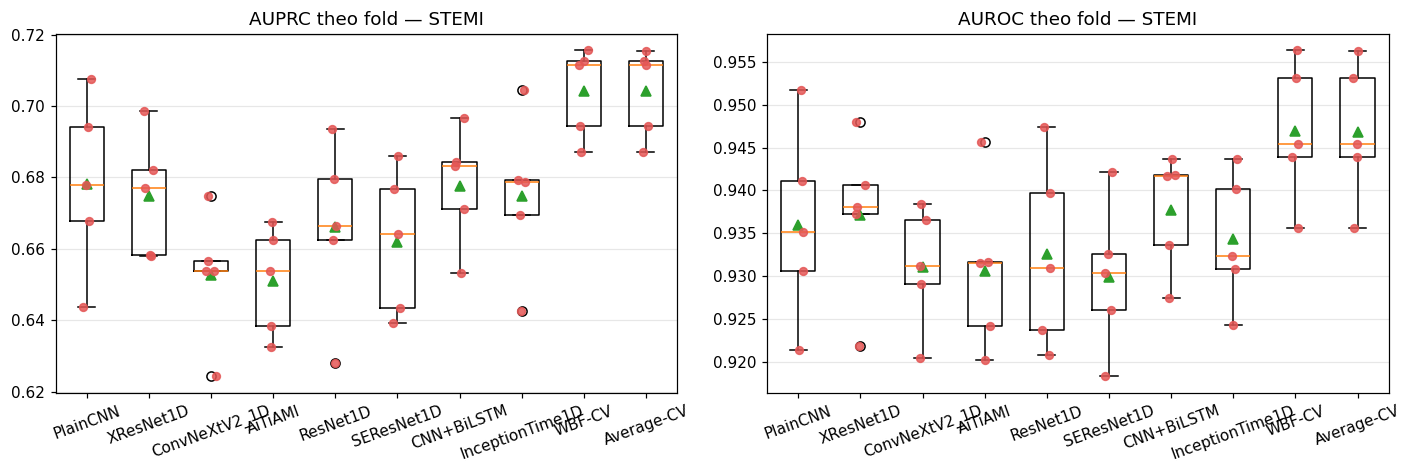

Các hộp chồng lấn nhiều = chênh lệch trung bình không đáng tin; xem lại p-value và CI ở trên trước khi kết luận.


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for j, metric in enumerate(["AUPRC", "AUROC"]):
    data = [FOLD_METRICS.loc[FOLD_METRICS["Model"] == n, metric].to_numpy() for n in ALL_NAMES]
    ax[j].boxplot(data, widths=.55, showmeans=True)   # không dùng labels=: bỏ ở matplotlib 3.9
    ax[j].set_xticks(range(1, len(ALL_NAMES) + 1))
    ax[j].set_xticklabels(ALL_NAMES)
    for i, vals in enumerate(data):
        ax[j].scatter(np.full(len(vals), i + 1) + np.random.uniform(-.08, .08, len(vals)),
                      vals, s=26, color="#E45756", zorder=3, alpha=.85)
    ax[j].set_title(f"{metric} theo fold — {CLASS_NAME}")
    ax[j].grid(alpha=.3, axis="y")
    ax[j].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()
print("Các hộp chồng lấn nhiều = chênh lệch trung bình không đáng tin; "
      "xem lại p-value và CI ở trên trước khi kết luận.")

## 17. So khớp ngưỡng: ép mọi model về cùng một điểm vận hành

`Sensitivity` ở bảng so sánh gốc được đo tại ngưỡng Youden's J **riêng của từng model**, nên hai model
có thể "recall khác nhau" chỉ vì ngưỡng của chúng khác nhau, không phải vì model khác nhau. Mục này
ép tất cả về **cùng Specificity = 0,85** (nội suy trên ROC) rồi mới so.

Hai bảng, **khác nguồn dữ liệu, không được đọc gộp**:

- **(a)** toàn bộ mười model của notebook 03 — nạp lại checkpoint cũ, chỉ chạy inference trên
  đúng tập val 85/15 gốc. Không huấn luyện gì thêm. Bảng này để *sàng* xem có ứng viên thứ tư không.
- **(b)** ba ứng viên + ensemble trên **OOF 5-fold** — chặt hơn hẳn, đây mới là bảng dùng để kết luận.

In [20]:
def find_low_threshold(y_true, y_prob, target_npv=0.99):
    """Ngưỡng THẤP lớn nhất sao cho NPV (của nhóm dưới ngưỡng) vẫn >= target_npv."""
    grid = np.linspace(0.0, 0.5, 501)
    best = 0.0
    for t in grid:
        below = y_prob < t
        if below.sum() == 0:
            continue
        npv = 1 - y_true[below].mean()
        if npv >= target_npv:
            best = t
        else:
            break
    return best


def find_high_threshold(y_true, y_prob, min_group_frac=0.01):
    """Ngưỡng CAO nhỏ nhất sao cho nhóm 'cao' (>= ngưỡng) còn chiếm >= min_group_frac tập."""
    grid = np.linspace(0.99, 0.05, 191)
    n = len(y_true)
    for t in grid:
        above = y_prob >= t
        if above.sum() / n >= min_group_frac:
            ppv = float(y_true[above].mean()) if above.sum() else float("nan")
            return float(t), ppv
    return 0.5, float("nan")


def threshold_at_specificity(y_true, y_prob, target_spec):
    """Ngưỡng cho Specificity = target_spec, nội suy tuyến tính trên đường ROC."""
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    thr = np.clip(thr, 0, 1)                 # thr[0] là +inf theo quy ước của sklearn
    return float(np.interp(1 - target_spec, fpr, thr))


def matched_row(name, y_true, y_prob):
    t_spec = threshold_at_specificity(y_true, y_prob, SPEC_TARGET)
    m = compute_metrics(y_true, y_prob, t_spec)
    t_ro = find_low_threshold(y_true.astype(int), y_prob, RULE_OUT_NPV)
    below = y_prob < t_ro
    return {"Model": name, "AUROC": m["auroc"], "AUPRC": m["auprc"],
            f"Thr@Spec{SPEC_TARGET:.2f}": t_spec, "Sensitivity": m["sensitivity"],
            "Specificity": m["specificity"], "PPV": m["ppv"], "NPV": m["npv"],
            f"Thr rule-out (NPV≥{RULE_OUT_NPV:.0%})": t_ro,
            "% loại được": float(below.mean()),
            "ca dương bị bỏ sót": int(y_true[below].sum())}


MATCH_PCT = ["AUROC", "AUPRC", f"Thr@Spec{SPEC_TARGET:.2f}", "Sensitivity", "Specificity",
             "PPV", "NPV", f"Thr rule-out (NPV≥{RULE_OUT_NPV:.0%})", "% loại được"]

# ---------- (a) inference-only: checkpoint của notebook 03 trên val 85/15 gốc ----------
orig_rows, ORIG_P = [], {}
for _name, _cls in MODELS.items():
    _ck = ORIG_MODEL_DIR / f"{_name.replace('+', '_')}_best.pt"
    if not _ck.exists():
        continue
    try:
        _state = torch.load(_ck, map_location=DEVICE, weights_only=False)
        _m = _cls().to(DEVICE)
        _m.load_state_dict(_state["model"])
    except Exception as e:                    # kiến trúc lệch so với lúc train -> bỏ qua model đó
        print(f"  bỏ qua {_name}: {type(e).__name__} — {e}")
        continue
    _yv, _pv = evaluate(_m, val_loader)
    ORIG_P[_name] = _pv
    orig_rows.append(matched_row(_name, _yv, _pv))
    del _m
    if GPU_AVAILABLE:
        torch.cuda.empty_cache()

if orig_rows:
    _wbf_w = {}
    for _n, _p in ORIG_P.items():
        _a = compute_metrics(y[val_idx], _p)["auroc"]
        _wbf_w[_n] = max((0.5 if np.isnan(_a) else _a) - 0.5, 1e-3)
    _s = sum(_wbf_w.values())
    orig_rows.append(matched_row("WBF-ensemble", y[val_idx],
                                 sum(_wbf_w[n] / _s * p for n, p in ORIG_P.items())))
    orig_rows.append(matched_row("Average-ensemble", y[val_idx],
                                 sum(ORIG_P.values()) / len(ORIG_P)))
    orig_df = pd.DataFrame(orig_rows).set_index("Model").sort_values("Sensitivity", ascending=False)
    print("=" * 78)
    print(f"(a) SÀNG — {len(ORIG_P)} model của notebook 03, checkpoint cũ, val 85/15 gốc "
          f"({len(val_idx):,} bản ghi)")
    print("    Nguồn dữ liệu KHÁC bảng (b) — không so trực tiếp hai bảng với nhau.")
    print("=" * 78)
    display(style_df(orig_df, MATCH_PCT))

    _cand_best = orig_df.loc[[c for c in CANDIDATES if c in orig_df.index], "Sensitivity"].max()
    _extra_candidates = orig_df[(~orig_df.index.isin(CANDIDATES + ["WBF-ensemble", "Average-ensemble"]))
                                & (orig_df["Sensitivity"] > _cand_best + 0.03)]
    if len(_extra_candidates):
        print(f"\n!! ỨNG VIÊN THỨ TƯ: {', '.join(_extra_candidates.index)} vượt ứng viên tốt nhất "
              f"({_cand_best:.4f}) hơn 0,03 Sensitivity tại Spec={SPEC_TARGET} — vượt mức nhiễu "
              f"ước lượng. Đề nghị bổ sung vào vòng K-Fold (thêm vào CANDIDATES ở mục 2, chạy lại).")
    else:
        print(f"\nKhông model nào ngoài ba ứng viên vượt quá +0,03 Sensitivity tại "
              f"Spec={SPEC_TARGET} -> giữ nguyên danh sách ứng viên.")
else:
    print("!! Không tìm thấy checkpoint nào trong", ORIG_MODEL_DIR)
    print("   Bảng (a) bị bỏ qua. Muốn có bảng này thì copy checkpoint của notebook 03 vào đó")
    print("   (Colab: thư mục outputs/models trên Drive) rồi chạy lại ô này.")

# ---------- (b) OOF 5-fold, ba ứng viên + ensemble ----------
oof_rows = [matched_row(n, y[VALID], OOF_P[n][0][VALID]) for n in ALL_NAMES]
oof_df = pd.DataFrame(oof_rows).set_index("Model").sort_values("Sensitivity", ascending=False)
print("\n" + "=" * 78)
print(f"(b) KẾT LUẬN — OOF {K_FOLDS} fold, {int(VALID.sum()):,} bản ghi, mọi model tại "
      f"Specificity = {SPEC_TARGET}")
print("=" * 78)
display(style_df(oof_df, MATCH_PCT))

!! Không tìm thấy checkpoint nào trong /content/drive/MyDrive/ACS-ECG-AI/outputs/models/stemi_compare
   Bảng (a) bị bỏ qua. Muốn có bảng này thì copy checkpoint của notebook 03 vào đó
   (Colab: thư mục outputs/models trên Drive) rồi chạy lại ô này.

(b) KẾT LUẬN — OOF 5 fold, 15,279 bản ghi, mọi model tại Specificity = 0.85


,AUROC,AUPRC,Thr@Spec0.85,Sensitivity,Specificity,PPV,NPV,Thr rule-out (NPV≥99%),% loại được,ca dương bị bỏ sót
Model,,,,,,,,,,
Average-CV,0.9454,0.7006,0.2464,0.9078,0.8499,0.3451,0.9906,0.2780,0.8029,122
WBF-CV,0.9454,0.7007,0.2466,0.9078,0.8502,0.3457,0.9906,0.2780,0.8028,121
PlainCNN,0.9338,0.6677,0.2834,0.8857,0.8499,0.3397,0.9884,0.1860,0.7505,114
InceptionTime1D,0.9313,0.6586,0.2856,0.8849,0.8500,0.3396,0.9883,0.1460,0.7353,112
CNN+BiLSTM,0.9336,0.6552,0.2395,0.8816,0.8500,0.3388,0.9880,0.1960,0.7702,117
XResNet1D,0.9312,0.6667,0.2111,0.8776,0.8500,0.3377,0.9876,0.0990,0.7432,113
ResNet1D,0.9320,0.6579,0.2522,0.8735,0.8500,0.3367,0.9872,0.1240,0.7343,112
ConvNeXtV2_1D,0.9216,0.6276,0.1410,0.8702,0.8500,0.3359,0.9869,0.0650,0.7179,109
AiTiAMI,0.9283,0.6428,0.2123,0.8669,0.8501,0.3351,0.9865,0.0660,0.7098,108


## 17b. Ép ngưỡng theo nhiều mức Sensitivity (91% – 95%)

Mục 17 ép mọi model về cùng **Specificity = 0,85** rồi đọc Sensitivity ra sao. Mục này làm **ngược
lại**: chọn trước một mức Sensitivity tối thiểu, xem Specificity/PPV/NPV còn lại bao nhiêu ở từng
mức — không train lại gì, chỉ chọn điểm khác trên đường ROC đã có sẵn từ `OOF_P`.

Thứ tự các dòng trong mỗi bảng **giữ nguyên theo AUPRC giảm dần** (AUPRC không phụ thuộc ngưỡng, nên
thứ tự này không đổi dù ép Sensitivity ở mức nào) — dễ so sánh xuyên suốt 5 bảng.

In [21]:
def threshold_at_sensitivity(y_true, y_prob, target_sens):
    """Ngưỡng LỚN NHẤT sao cho Sensitivity thực tế vẫn >= target_sens — đảm bảo chặn dưới thật,
    không xấp xỉ bằng nội suy (nội suy tuyến tính trên đường ROC dạng bậc thang có thể cho kết quả
    tụt dưới mục tiêu, như đã thấy: 94,94% thay vì 95%). Dò trực tiếp trên điểm số của các ca dương,
    giống cách find_low_threshold/find_high_threshold đã làm."""
    y_true = np.asarray(y_true).astype(int)
    pos_scores = np.sort(y_prob[y_true == 1])[::-1]        # điểm ca dương, giảm dần
    n_pos = len(pos_scores)
    k = min(int(np.ceil(target_sens * n_pos)), n_pos)       # cần bắt ít nhất k ca dương
    return float(pos_scores[k - 1]) if k > 0 else 1.0


SENS_TARGETS = [0.91, 0.92, 0.93, 0.94, 0.95]
_DISPLAY_NAME = {"Average-CV": "Average Ensemble", "WBF-CV": "WBF Ensemble"}
_ROW_NAMES = ["Average-CV"] + list(CANDIDATES)    # Average Ensemble + 8 model đơn, không có WBF
SENS_COLS = ["AUROC", "AUPRC", "Sensitivity", "Specificity", "F1", "NPV", "PPV"]

# thứ tự cố định theo AUPRC giảm dần (không đổi theo ngưỡng) -> tính 1 lần, dùng lại cho cả 5 bảng
_auprc_order = sorted(
    _ROW_NAMES,
    key=lambda n: -compute_metrics(y[VALID], OOF_P[n][0][VALID])["auprc"])

for target in SENS_TARGETS:
    rows = []
    for name in _auprc_order:
        p_ = OOF_P[name][0][VALID]
        t = threshold_at_sensitivity(y[VALID], p_, target)
        m = compute_metrics(y[VALID], p_, t)
        rows.append({"Model": _DISPLAY_NAME.get(name, name), "AUROC": m["auroc"],
                     "AUPRC": m["auprc"], "Sensitivity": m["sensitivity"],
                     "Specificity": m["specificity"], "F1": m["f1"], "NPV": m["npv"],
                     "PPV": m["ppv"], "_thr": t})
    _sens_df = pd.DataFrame(rows).set_index("Model")

    print("=" * 78)
    print(f"ÉP NGƯỠNG Sensitivity >= {target:.0%}  —  OOF {K_FOLDS} fold, {int(VALID.sum()):,} bản ghi")
    print("=" * 78)
    display(style_df(_sens_df[SENS_COLS], SENS_COLS))
    _champ = _sens_df.index[0]
    _thr_v, _spec_v, _ppv_v = _sens_df.loc[_champ, "_thr"], _sens_df.loc[_champ, "Specificity"], _sens_df.loc[_champ, "PPV"]
    print(f"Ngưỡng {_champ}: {_thr_v:.4f}  |  Specificity còn lại {_spec_v:.4f}  |  PPV {_ppv_v:.4f}\n")

ÉP NGƯỠNG Sensitivity >= 91%  —  OOF 5 fold, 15,279 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
Average Ensemble,0.9454,0.7006,0.9102,0.8482,0.4985,0.9909,0.3433
PlainCNN,0.9338,0.6677,0.9102,0.7981,0.4308,0.9903,0.2821
XResNet1D,0.9312,0.6667,0.9102,0.7954,0.4276,0.9903,0.2794
InceptionTime1D,0.9313,0.6586,0.9102,0.7885,0.4197,0.9902,0.2727
ResNet1D,0.9320,0.6579,0.9102,0.7889,0.4202,0.9902,0.2732
CNN+BiLSTM,0.9336,0.6552,0.9102,0.8182,0.4556,0.9905,0.3038
AiTiAMI,0.9283,0.6428,0.9102,0.7768,0.4072,0.9900,0.2622
SEResNet1D,0.9221,0.6400,0.9102,0.7615,0.3918,0.9898,0.2496
ConvNeXtV2_1D,0.9216,0.6276,0.9102,0.7746,0.4049,0.9900,0.2603


Ngưỡng Average Ensemble: 0.2417  |  Specificity còn lại 0.8482  |  PPV 0.3433

ÉP NGƯỠNG Sensitivity >= 92%  —  OOF 5 fold, 15,279 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
Average Ensemble,0.9454,0.7006,0.9200,0.8232,0.4660,0.9916,0.3120
PlainCNN,0.9338,0.6677,0.9200,0.7813,0.4154,0.9912,0.2683
XResNet1D,0.9312,0.6667,0.9200,0.7578,0.3916,0.9909,0.2487
InceptionTime1D,0.9313,0.6586,0.9200,0.7741,0.4078,0.9911,0.2620
ResNet1D,0.9320,0.6579,0.9208,0.7705,0.4044,0.9911,0.2591
CNN+BiLSTM,0.9336,0.6552,0.9200,0.7936,0.4291,0.9913,0.2798
AiTiAMI,0.9283,0.6428,0.9200,0.7511,0.3853,0.9908,0.2437
SEResNet1D,0.9221,0.6400,0.9200,0.7280,0.3651,0.9905,0.2277
ConvNeXtV2_1D,0.9216,0.6276,0.9200,0.7502,0.3844,0.9908,0.2430


Ngưỡng Average Ensemble: 0.1932  |  Specificity còn lại 0.8232  |  PPV 0.3120

ÉP NGƯỠNG Sensitivity >= 93%  —  OOF 5 fold, 15,279 bản ghi


...

Ngưỡng Average Ensemble: 0.1679  |  Specificity còn lại 0.8071  |  PPV 0.2960

ÉP NGƯỠNG Sensitivity >= 94%  —  OOF 5 fold, 15,279 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
Average Ensemble,0.9454,0.7006,0.9404,0.7936,0.4365,0.9935,0.2842
PlainCNN,0.9338,0.6677,0.9404,0.6814,0.3362,0.9924,0.2047
XResNet1D,0.9312,0.6667,0.9404,0.6786,0.3342,0.9924,0.2032
InceptionTime1D,0.9313,0.6586,0.9404,0.7039,0.3524,0.9927,0.2168
ResNet1D,0.9320,0.6579,0.9404,0.7010,0.3502,0.9926,0.2152
CNN+BiLSTM,0.9336,0.6552,0.9404,0.7116,0.3583,0.9928,0.2213
AiTiAMI,0.9283,0.6428,0.9404,0.6785,0.3342,0.9924,0.2032
SEResNet1D,0.9221,0.6400,0.9404,0.6264,0.3021,0.9918,0.1799
ConvNeXtV2_1D,0.9216,0.6276,0.9404,0.6624,0.3236,0.9922,0.1954


Ngưỡng Average Ensemble: 0.1507  |  Specificity còn lại 0.7936  |  PPV 0.2842

ÉP NGƯỠNG Sensitivity >= 95%  —  OOF 5 fold, 15,279 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
Average Ensemble,0.9454,0.7006,0.9502,0.7532,0.3975,0.9943,0.2513
PlainCNN,0.9338,0.6677,0.9502,0.6410,0.3131,0.9933,0.1874
XResNet1D,0.9312,0.6667,0.9502,0.6201,0.3012,0.9930,0.1790
InceptionTime1D,0.9313,0.6586,0.9502,0.6573,0.3231,0.9934,0.1946
ResNet1D,0.9320,0.6579,0.9502,0.6773,0.3362,0.9936,0.2042
CNN+BiLSTM,0.9336,0.6552,0.9502,0.6873,0.3432,0.9937,0.2094
AiTiAMI,0.9283,0.6428,0.9502,0.6483,0.3175,0.9933,0.1906
SEResNet1D,0.9221,0.6400,0.9502,0.5634,0.2731,0.9924,0.1595
ConvNeXtV2_1D,0.9216,0.6276,0.9502,0.5687,0.2755,0.9924,0.1611


Ngưỡng Average Ensemble: 0.1070  |  Specificity còn lại 0.7532  |  PPV 0.2513



## 18. Hiệu chuẩn xác suất bằng cross-fit

Dự án dùng **xác suất liên tục** chứ không phải nhãn nhị phân cứng, nên xác suất phải đọc được như
xác suất thật: trong nhóm được chấm 0,30 thì đúng khoảng 30% là ca dương.

Yêu cầu gốc có một mâu thuẫn: bước 4 cấm hiệu chuẩn trên chính tập dùng để chọn ngưỡng ở bước 5,
nhưng bước 5 lại đòi bootstrap trên *toàn bộ* OOF. Cách gỡ ở đây là **cross-fit**: xác suất của fold
*i* được hiệu chuẩn bằng bộ hiệu chuẩn fit trên OOF của **4 fold còn lại**. Ghép lại thì mọi bản ghi
đều có xác suất "honest" — không bản ghi nào tham gia fit bộ hiệu chuẩn của chính nó — mà vẫn dùng
được hết dữ liệu cho mục 19, thay vì hy sinh một fold (~540 bản ghi, ~35 ca dương, quá ít cho isotonic).

Cross-fit Platt cho WBF-CV ...
Cross-fit Isotonic cho WBF-CV ...

WBF-CV — OOF 15,279 bản ghi


,ECE,Brier,AUROC,AUPRC
Hiệu chuẩn,,,,
thô,0.0869,0.0622,0.9454,0.7007
Platt,0.0054,0.0391,0.9449,0.6996
Isotonic,0.0040,0.0393,0.9420,0.6837


  Platt     ECE 0.0869 -> 0.0054  GIẢM (đạt AC)
  Isotonic  ECE 0.0869 -> 0.0040  GIẢM (đạt AC)
-> Dùng Isotonic cho phần phân tầng nguy cơ (ECE thấp nhất).


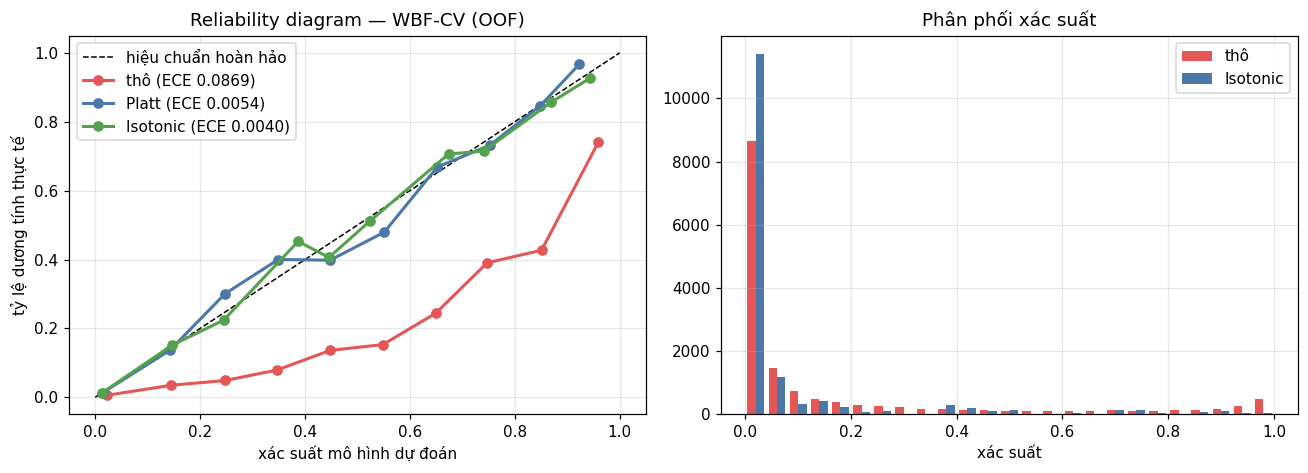


Bảng bin của bản đã hiệu chuẩn:


,bin,n,xác suất TB,tỷ lệ dương thật,lệch
0,"[0.0,0.1)",12860,0.0131,0.0130,-0.0001
1,"[0.1,0.2)",728,0.1463,0.1511,0.0048
2,"[0.2,0.3)",183,0.2447,0.2240,-0.0207
3,"[0.3,0.4)",316,0.3868,0.4525,0.0657
4,"[0.4,0.5)",394,0.4457,0.4061,-0.0396
5,"[0.5,0.6)",84,0.5240,0.5119,-0.0121
6,"[0.6,0.7)",160,0.6737,0.7062,0.0326
7,"[0.7,0.8)",256,0.7407,0.7148,-0.0259
8,"[0.8,0.9)",161,0.8698,0.8571,-0.0126
9,"[0.9,1.0)",137,0.9441,0.9270,-0.0171


In [22]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression


def ece_table(y_true, y_prob, n_bins=ECE_BINS):
    """Copy nguyên từ mục 16b của notebook 03."""
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_prob = np.asarray(y_prob, dtype=float).ravel()
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)
    ece, rows = 0.0, []
    for b in range(n_bins):
        m = idx == b
        if not m.sum():
            continue
        conf, acc = float(y_prob[m].mean()), float(y_true[m].mean())
        ece += m.sum() / len(y_prob) * abs(acc - conf)
        rows.append({"bin": f"[{edges[b]:.1f},{edges[b + 1]:.1f})", "n": int(m.sum()),
                     "xác suất TB": conf, "tỷ lệ dương thật": acc, "lệch": acc - conf})
    return float(ece), pd.DataFrame(rows)


def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def crossfit_calibrate(p_raw, method):
    """Fold i được hiệu chuẩn bằng bộ hiệu chuẩn fit trên OOF của các fold KHÁC."""
    out = np.full(len(p_raw), NAN)
    folds_present = [k for k in range(K_FOLDS) if (FOLD_ID[0] == k).any()]
    if len(folds_present) < 2:
        print("  (chỉ có 1 fold — không cross-fit được, fit và áp trên chính nó; chỉ dùng để test pipeline)")
        folds_present = folds_present or [0]
        m = FOLD_ID[0] == folds_present[0]
        fit_mask = apply_mask = m
        pairs = [(fit_mask, apply_mask)]
    else:
        pairs = [((FOLD_ID[0] != k) & VALID, FOLD_ID[0] == k) for k in folds_present]
    for fit_mask, apply_mask in pairs:
        if len(np.unique(y[fit_mask].astype(int))) < 2:
            out[apply_mask] = p_raw[apply_mask]
            continue
        if method == "platt":
            lr = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
            lr.fit(_logit(p_raw[fit_mask]).reshape(-1, 1), y[fit_mask].astype(int))
            out[apply_mask] = lr.predict_proba(_logit(p_raw[apply_mask]).reshape(-1, 1))[:, 1]
        else:
            iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
            iso.fit(p_raw[fit_mask], y[fit_mask].astype(int))
            out[apply_mask] = iso.predict(p_raw[apply_mask])
    return out


CAL_MODEL = CHAMPION
_p_raw = OOF_P[CAL_MODEL][0]
CAL_P = {"thô": _p_raw}
for _meth, _lbl in [("platt", "Platt"), ("isotonic", "Isotonic")]:
    print(f"Cross-fit {_lbl} cho {CAL_MODEL} ...")
    CAL_P[_lbl] = crossfit_calibrate(_p_raw, _meth)

ECE_ROWS, _tables = [], {}
for _lbl, _p in CAL_P.items():
    _e, _t = ece_table(y[VALID], _p[VALID])
    _tables[_lbl] = _t
    ECE_ROWS.append({"Hiệu chuẩn": _lbl, "ECE": _e,
                     "Brier": float(brier_score_loss(y[VALID].astype(int), _p[VALID])),
                     "AUROC": compute_metrics(y[VALID], _p[VALID])["auroc"],
                     "AUPRC": compute_metrics(y[VALID], _p[VALID])["auprc"]})
ece_df = pd.DataFrame(ECE_ROWS).set_index("Hiệu chuẩn")
print(f"\n{CAL_MODEL} — OOF {int(VALID.sum()):,} bản ghi")
display(style_df(ece_df, ["ECE", "Brier", "AUROC", "AUPRC"]))

_e0 = ece_df.loc["thô", "ECE"]
for _lbl in ["Platt", "Isotonic"]:
    _e1 = ece_df.loc[_lbl, "ECE"]
    print(f"  {_lbl:<9} ECE {_e0:.4f} -> {_e1:.4f}  "
          f"{'GIẢM (đạt AC)' if _e1 < _e0 else 'KHÔNG GIẢM (không đạt AC)'}")
BEST_CAL = min(["Platt", "Isotonic"], key=lambda l: ece_df.loc[l, "ECE"])
print(f"-> Dùng {BEST_CAL} cho phần phân tầng nguy cơ (ECE thấp nhất).")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="hiệu chuẩn hoàn hảo")
for _lbl, _c in zip(CAL_P, ["#E45756", "#4C78A8", "#54A24B"]):
    _t = _tables[_lbl]
    ax[0].plot(_t["xác suất TB"], _t["tỷ lệ dương thật"], marker="o", lw=2, color=_c,
               label=f"{_lbl} (ECE {ece_df.loc[_lbl, 'ECE']:.4f})")
ax[0].set_xlabel("xác suất mô hình dự đoán")
ax[0].set_ylabel("tỷ lệ dương tính thực tế")
ax[0].set_title(f"Reliability diagram — {CAL_MODEL} (OOF)")
ax[0].legend()
ax[0].grid(alpha=.3)
ax[1].hist([CAL_P["thô"][VALID], CAL_P[BEST_CAL][VALID]], bins=25, label=["thô", BEST_CAL],
           color=["#E45756", "#4C78A8"])
ax[1].set_title("Phân phối xác suất")
ax[1].set_xlabel("xác suất")
ax[1].legend()
ax[1].grid(alpha=.3)
plt.tight_layout()
plt.show()

print("\nBảng bin của bản đã hiệu chuẩn:")
display(_tables[BEST_CAL].round(4))

## 19. Phân tầng nguy cơ ba mức kèm khoảng tin cậy

Lặp lại đúng cách phân tầng ở mục 14c/15c của notebook 03 (ngưỡng thấp = mức cao nhất còn giữ
NPV ≥ 99%; ngưỡng cao = mức thấp nhất mà nhóm "cao" vẫn chiếm ≥ 1% tập), nhưng chạy trên xác suất
**đã hiệu chuẩn cross-fit** và kèm **95% CI** thay vì một con số điểm.

Bootstrap lấy mẫu lại **theo bệnh nhân**, không theo bản ghi: 855 bệnh nhân có nhiều hơn một ECG và
các bản ghi của cùng một người tương quan mạnh, nên lấy mẫu theo bản ghi sẽ coi chúng là độc lập và
cho ra khoảng tin cậy hẹp giả tạo. Ngưỡng giữ **cố định** ở giá trị chốt trên toàn bộ OOF — cái được
ước lượng khoảng là NPV/PPV *tại điểm vận hành đã chọn*, đúng như câu hỏi lâm sàng đặt ra.

In [23]:
def patient_groups(mask):
    idx_all = np.where(mask)[0]
    codes = PAT_CODES[idx_all]
    order = np.argsort(codes, kind="stable")
    idx_sorted, codes_sorted = idx_all[order], codes[order]
    return np.split(idx_sorted, np.searchsorted(codes_sorted, np.unique(codes_sorted))[1:])


def tier_report(label, p_all):
    yv, pv = y[VALID].astype(int), p_all[VALID]
    t_low = find_low_threshold(yv, pv, RULE_OUT_NPV)
    t_high, _ = find_high_threshold(yv, pv)
    tier = np.where(pv < t_low, "Thấp", np.where(pv >= t_high, "Cao", "Trung bình"))
    rows = []
    for lvl in ["Thấp", "Trung bình", "Cao"]:
        m = tier == lvl
        rows.append({"Mức": lvl, "n": int(m.sum()), "tỷ lệ n": m.mean(),
                     "dương": int(yv[m].sum()), "tỷ lệ dương trong nhóm": _div(int(yv[m].sum()), int(m.sum()))})
    print("=" * 78)
    print(f"{label}  |  ngưỡng thấp {t_low:.3f}  |  ngưỡng cao {t_high:.3f}")
    print("=" * 78)
    display(pd.DataFrame(rows).set_index("Mức").style.format(
        {"tỷ lệ n": "{:.2%}", "tỷ lệ dương trong nhóm": "{:.2%}", "n": "{:,d}", "dương": "{:,d}"}))

    groups = patient_groups(VALID)
    pos_in = {i: j for j, i in enumerate(np.where(VALID)[0])}
    rng = np.random.default_rng(SEED)
    npv_b, ppv_b, frac_b = [], [], []
    for _ in range(N_BOOTSTRAP):
        pick = rng.integers(0, len(groups), len(groups))
        sel = np.concatenate([groups[i] for i in pick])
        loc = np.array([pos_in[i] for i in sel])
        ys, ps = yv[loc], pv[loc]
        low, high = ps < t_low, ps >= t_high
        npv_b.append(1 - ys[low].mean() if low.any() else NAN)
        ppv_b.append(ys[high].mean() if high.any() else NAN)
        frac_b.append(low.mean())
    ci = lambda a: np.nanpercentile(np.asarray(a, dtype=float), [2.5, 97.5])
    npv_pt = 1 - yv[pv < t_low].mean() if (pv < t_low).any() else NAN
    ppv_pt = yv[pv >= t_high].mean() if (pv >= t_high).any() else NAN
    n_lo, h_lo = ci(npv_b), ci(ppv_b)
    f_lo = ci(frac_b)
    print(f"\nBootstrap {N_BOOTSTRAP:,} lần, lấy mẫu lại theo {len(groups):,} bệnh nhân:")
    display(pd.DataFrame([
        {"Chỉ số": f"NPV nhóm THẤP (rule-out)", "Điểm": npv_pt,
         "95% CI": f"[{n_lo[0]:.4f}, {n_lo[1]:.4f}]"},
        {"Chỉ số": f"PPV nhóm CAO (rule-in)", "Điểm": ppv_pt,
         "95% CI": f"[{h_lo[0]:.4f}, {h_lo[1]:.4f}]"},
        {"Chỉ số": "% bệnh nhân loại được ở nhóm THẤP", "Điểm": float((pv < t_low).mean()),
         "95% CI": f"[{f_lo[0]:.4f}, {f_lo[1]:.4f}]"},
    ]).set_index("Chỉ số").style.format({"Điểm": "{:.4f}"}))
    return {"t_low": t_low, "t_high": t_high, "npv_ci": n_lo, "ppv_ci": h_lo}


TIER_RAW = tier_report(f"{CAL_MODEL} — xác suất THÔ (OOF)", CAL_P["thô"])
print()
TIER_CAL = tier_report(f"{CAL_MODEL} — sau hiệu chuẩn {BEST_CAL} (cross-fit)", CAL_P[BEST_CAL])

WBF-CV — xác suất THÔ (OOF)  |  ngưỡng thấp 0.278  |  ngưỡng cao 0.980


,n,tỷ lệ n,dương,tỷ lệ dương trong nhóm
Mức,,,,
Thấp,"12,266",80.28%,121,0.99%
Trung bình,"2,776",18.17%,889,32.02%
Cao,237,1.55%,215,90.72%



Bootstrap 1,000 lần, lấy mẫu lại theo 14,465 bệnh nhân:


,Điểm,95% CI
Chỉ số,,
NPV nhóm THẤP (rule-out),0.9901,"[0.9883, 0.9919]"
PPV nhóm CAO (rule-in),0.9072,"[0.8697, 0.9395]"
% bệnh nhân loại được ở nhóm THẤP,0.8028,"[0.7961, 0.8092]"



WBF-CV — sau hiệu chuẩn Isotonic (cross-fit)  |  ngưỡng thấp 0.057  |  ngưỡng cao 0.886


,n,tỷ lệ n,dương,tỷ lệ dương trong nhóm
Mức,,,,
Thấp,"12,205",79.88%,121,0.99%
Trung bình,"2,894",18.94%,941,32.52%
Cao,180,1.18%,163,90.56%



Bootstrap 1,000 lần, lấy mẫu lại theo 14,465 bệnh nhân:


,Điểm,95% CI
Chỉ số,,
NPV nhóm THẤP (rule-out),0.9901,"[0.9882, 0.9918]"
PPV nhóm CAO (rule-in),0.9056,"[0.8618, 0.9471]"
% bệnh nhân loại được ở nhóm THẤP,0.7988,"[0.7922, 0.8052]"


## 20. (Tuỳ chọn) Sweep hyperparameter nhẹ

Mặc định **tắt** (`RUN_SWEEP = False` ở mục 2) vì tốn thêm nhiều giờ GPU. Bật lên thì chạy hai giai đoạn:

1. **Thô** — learning rate ∈ {5e-4, 1e-3, 2e-3}, **chỉ fold 0**, cho từng ứng viên.
2. **Tinh** — với LR tốt nhất của từng model: dropout ∈ {0.2, 0.3, 0.4} × loss ∈ {pos_weight, focal γ=2},
   vẫn ở fold 0; tổ hợp thắng của mỗi model mới chạy đủ 5 fold.

`PlainCNN` không có tham số `dropout` trong `__init__` nên phần dropout tự động bỏ qua với model này —
sweep của nó chỉ gồm learning rate và loss.

Kết quả sweep **không** dùng lại được số liệu CV ở mục 14: những con số đó chạy ở hyperparameter mặc
định, không áp cho tổ hợp mới.

In [24]:
import inspect
from functools import partial


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma, self.alpha = gamma, alpha

    def forward(self, logits, target):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, target, reduction="none")
        p_t = torch.exp(-bce)
        a_t = self.alpha * target + (1 - self.alpha) * (1 - target)
        return (a_t * (1 - p_t) ** self.gamma * bce).mean()


def train_variant(name, cls, rep, k, lr, loss_kind, pos_weight, tr_loader, va_loader, tag):
    """Như train_fold nhưng cho phép đổi LR / dropout / loss. Checkpoint riêng theo tag."""
    ckpt = MODEL_DIR / f"sweep_{tag.replace('+', '_').replace('=', '').replace(' ', '_')}.pt"
    fp = dict(CV_FP, model=name, rep=rep, fold=k, tag=tag)
    fp.pop("models"), fp.pop("n_folds_run")
    if ckpt.exists():
        ck = torch.load(ckpt, map_location=DEVICE, weights_only=False)
        if ck.get("fp") == fp:
            print(f"  [{tag}] có checkpoint khớp -> bỏ qua (AUPRC {ck['best']:.4f})")
            return ck["best"]

    torch.manual_seed(SEED + rep)
    model = cls().to(DEVICE)
    criterion = (FocalLoss() if loss_kind == "focal" else
                 nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=DEVICE)))
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    sched = ReduceLROnPlateau(opt, mode="max", factor=.5, patience=LR_PATIENCE)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    best, bad = -np.inf, 0
    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            if not torch.isfinite(loss):
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(opt)
            scaler.update()
        m = compute_metrics(*evaluate(model, va_loader))
        sched.step(m["auprc"] if not np.isnan(m["auprc"]) else -np.inf)
        if (not np.isnan(m["auprc"])) and m["auprc"] > best:
            best, bad = float(m["auprc"]), 0
            torch.save({"model": model.state_dict(), "fp": fp, "best": best}, ckpt)
        else:
            bad += 1
            if bad >= EARLY_STOP_PATIENCE:
                break
    del model
    if GPU_AVAILABLE:
        torch.cuda.empty_cache()
    print(f"  [{tag}] best AUPRC {best:.4f}")
    return best


if not RUN_SWEEP:
    print("RUN_SWEEP = False -> bỏ qua sweep. Đặt True ở mục 2 để chạy (tốn nhiều giờ GPU).")
else:
    _tr0, _va0 = FOLDS[(0, 0)]
    _mean0, _std0 = norm_stats(_tr0)
    _trl, _val = make_loaders(_tr0, _va0, _mean0, _std0)
    _npos0 = int(y[_tr0].sum())
    _pw0 = float((len(_tr0) - _npos0) / max(_npos0, 1))

    sweep_rows, BEST_HP = [], {}
    for _name in CANDIDATES:
        _cls = MODELS[_name]
        # --- giai đoạn thô: learning rate, chỉ fold 0 ---
        _lr_scores = {}
        for _lr in [5e-4, 1e-3, 2e-3]:
            _tag = f"{_name} lr={_lr}"
            _lr_scores[_lr] = train_variant(_name, _cls, 0, 0, _lr, "bce", _pw0, _trl, _val, _tag)
            sweep_rows.append({"Model": _name, "Giai đoạn": "thô", "LR": _lr, "dropout": None,
                               "loss": "bce", "AUPRC fold0": _lr_scores[_lr]})
        _best_lr = max(_lr_scores, key=_lr_scores.get)

        # --- giai đoạn tinh: dropout × loss, vẫn fold 0 ---
        _has_dropout = "dropout" in inspect.signature(_cls.__init__).parameters
        _drops = [0.2, 0.3, 0.4] if _has_dropout else [None]
        if not _has_dropout:
            print(f"  ({_name} không nhận tham số dropout -> chỉ sweep loss)")
        _fine = {}
        for _dp in _drops:
            for _loss in ["bce", "focal"]:
                _mk = partial(_cls, dropout=_dp) if _dp is not None else _cls
                _tag = f"{_name} lr={_best_lr} dp={_dp} {_loss}"
                _sc = train_variant(_name, _mk, 0, 0, _best_lr, _loss, _pw0, _trl, _val, _tag)
                _fine[(_dp, _loss)] = _sc
                sweep_rows.append({"Model": _name, "Giai đoạn": "tinh", "LR": _best_lr,
                                   "dropout": _dp, "loss": _loss, "AUPRC fold0": _sc})
        _bd, _bl = max(_fine, key=_fine.get)
        BEST_HP[_name] = {"lr": _best_lr, "dropout": _bd, "loss": _bl}
        print(f"-> {_name}: lr={_best_lr}, dropout={_bd}, loss={_bl}")

    display(style_df(pd.DataFrame(sweep_rows).set_index(["Model", "Giai đoạn"]), ["AUPRC fold0"]))

    # --- tổ hợp thắng của từng model chạy đủ K fold ---
    full_rows = []
    for _name, _hp in BEST_HP.items():
        _cls = MODELS[_name]
        _mk = partial(_cls, dropout=_hp["dropout"]) if _hp["dropout"] is not None else _cls
        for _k in range(N_FOLDS_RUN):
            _tr, _va = FOLDS[(0, _k)]
            _m, _s = norm_stats(_tr)
            _tl, _vl = make_loaders(_tr, _va, _m, _s)
            _np_ = int(y[_tr].sum())
            _pw = float((len(_tr) - _np_) / max(_np_, 1))
            _tag = f"{_name} TUNED f{_k}"
            full_rows.append({"Model": f"{_name} (tuned)", "fold": _k,
                              "AUPRC": train_variant(_name, _mk, 0, _k, _hp["lr"], _hp["loss"],
                                                     _pw, _tl, _vl, _tag)})
    tuned_df = pd.DataFrame(full_rows)
    display(style_df(tuned_df.groupby("Model")["AUPRC"].agg(["mean", "std"]), ["mean"]))
    print("So với mục 15 (hyperparameter mặc định) để biết tuning có đáng hay không.")

RUN_SWEEP = False -> bỏ qua sweep. Đặt True ở mục 2 để chạy (tốn nhiều giờ GPU).


## 21. Lưu ý khi kết luận

- **8 ứng viên (mở rộng theo ngưỡng ±0,015 AUROC), không phải mười.** Hai kiến trúc còn lại
  (`TCN1D`, `Transformer1D`) chỉ xuất hiện ở bảng sàng 17(a) với checkpoint cũ trên lần chia 85/15
  gốc. Chúng **chưa** qua K-Fold, nên không có khoảng tin cậy và không được xếp hạng chung với các
  ứng viên đã qua K-Fold.
- **Hai bảng ở mục 17 khác nguồn dữ liệu.** (a) là một lần chia 85/15; (b) là OOF 5 fold. Con số
  không so trực tiếp được với nhau.
- **Wilcoxon ở K = 5 không thể cho p hai phía < 0,05** (xem mục 16). Đọc kết luận dựa vào bootstrap
  CI của ΔAUPRC là chính.
- **Ngưỡng ở mục 19 chốt trên OOF, chưa phải trên dữ liệu độc lập.** Tập test ẩn 10% vẫn chưa được
  chạm tới ở bất kỳ bước nào của notebook này. Trước khi dùng lâm sàng, ngưỡng phải được xác nhận lại
  trên một tập độc lập.
- **Hiệu chuẩn phụ thuộc tỷ lệ mắc.** Tỷ lệ dương ở đây (8,05% STEMI) là của quần thể đã được chỉ định
  chụp mạch, cao hơn nhiều so với quần thể cấp cứu chung. Đưa sang nơi khác thì phải hiệu chuẩn lại.
- **Chưa làm:** kiểm tra ngoài phân phối trên Georgia / Chapman-Shaoxing (không có dữ liệu CinC2021
  trong `datasets/`) và phân tích lỗi false-negative kèm Grad-CAM — hai việc này để notebook riêng.

## 21b. Đánh giá cổ điển trên tập TEST giữ riêng (15%, chưa từng đụng tới)

Tập TEST (mục 12b) không tham gia bất kỳ bước nào ở trên — không train, không chọn ứng viên, không
chọn ngưỡng, không hiệu chuẩn. Đây là **lần duy nhất** nó được dùng, đúng tinh thần đánh giá cổ điển:
POOL (train/val, qua 5-fold) lo việc chọn model + ngưỡng + hiệu chuẩn; TEST chỉ đánh giá một lần cuối.

- **Xác suất trên TEST** cho mỗi kiến trúc = trung bình dự đoán của **cả 5 checkpoint fold** (bagging)
  — không train thêm model nào mới. Mỗi checkpoint chuẩn hoá dữ liệu bằng đúng z-score của fold nó
  từng train (không phải một bộ thống kê chung), khớp đúng cách nó được huấn luyện.
- **Ngưỡng và bộ hiệu chuẩn** dùng nguyên xi cái đã chốt từ OOF của POOL (mục 15-19) — **không refit
  lại trên TEST**, để tránh rò rỉ thông tin TEST vào bước chọn ngưỡng.

In [25]:
# ---- 1) Bagging: mỗi kiến trúc = trung bình 5 checkpoint fold, dự đoán trên TEST ----
_fold_stats = {k: norm_stats(FOLDS[(0, k)][0]) for k in range(N_FOLDS_RUN)}
TEST_P = {}
for name in CANDIDATES:
    preds = []
    for k in range(N_FOLDS_RUN):
        mean_k, std_k = _fold_stats[k]
        ckpt_path = MODEL_DIR / f"{name.replace('+', '_')}_r0f{k}_best.pt"
        if not ckpt_path.exists():
            print(f"  !! thiếu checkpoint {ckpt_path.name} -- bỏ qua fold {k} của {name}")
            continue
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model = MODELS[name]().to(DEVICE)
        model.load_state_dict(ck["model"])
        test_ds = ECGDataset(TEST_IDX, y[TEST_IDX], mean_k, std_k)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
        _, p = evaluate(model, test_loader)
        preds.append(p)
        del model
        if GPU_AVAILABLE:
            torch.cuda.empty_cache()
    TEST_P[name] = np.mean(preds, axis=0)
    print(f"  {name}: bagging {len(preds)}/{N_FOLDS_RUN} fold checkpoint xong")

y_test = y[TEST_IDX].astype(int)
TEST_P["Average-CV"] = np.mean([TEST_P[n] for n in CANDIDATES], axis=0)
_pool_w_raw = {}
for name in CANDIDATES:
    _a = compute_metrics(y[VALID], OOF_P[name][0][VALID])["auroc"]
    _pool_w_raw[name] = max((0.5 if np.isnan(_a) else _a) - 0.5, _EPS)
_pool_w_sum = sum(_pool_w_raw.values())
TEST_P["WBF-CV"] = sum(_pool_w_raw[n] / _pool_w_sum * TEST_P[n] for n in CANDIDATES)
print(f"\nTEST: {len(TEST_IDX):,} bản ghi, {int(y_test.sum())} dương ({y_test.mean():.2%})")

# ---- 1b) Model FINAL (train 1 lần trên 100% POOL, mục 14c) -- dự đoán trên TEST ----
TEST_P_FINAL = {}
_test_ds_final = ECGDataset(TEST_IDX, y[TEST_IDX], mean_pool, std_pool)
_test_loader_final = DataLoader(_test_ds_final, batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
for name in CANDIDATES:
    _, p = evaluate(FINAL_MODELS[name], _test_loader_final)
    TEST_P_FINAL[name] = p
TEST_P_FINAL["Average-CV"] = np.mean([TEST_P_FINAL[n] for n in CANDIDATES], axis=0)
TEST_P_FINAL["WBF-CV"] = sum(_pool_w_raw[n] / _pool_w_sum * TEST_P_FINAL[n] for n in CANDIDATES)

print("\n" + "=" * 78)
print("SO SÁNH TRÊN TEST: BAGGING (5 checkpoint/kiến trúc) vs FINAL (1 checkpoint/kiến trúc)")
print("=" * 78)
_cmp_rows = []
for name in CANDIDATES + ["Average-CV", "WBF-CV"]:
    _m_bag = compute_metrics(y_test, TEST_P[name])
    _m_fin = compute_metrics(y_test, TEST_P_FINAL[name])
    _cmp_rows.append({"Model": name, "AUROC bagging": _m_bag["auroc"], "AUROC final": _m_fin["auroc"],
                      "AUPRC bagging": _m_bag["auprc"], "AUPRC final": _m_fin["auprc"]})
display(style_df(pd.DataFrame(_cmp_rows).set_index("Model"),
                 ["AUROC bagging", "AUROC final", "AUPRC bagging", "AUPRC final"]))
print("\nTừ đây, hai bảng metric/hiệu chuẩn/phân tầng dưới đây dùng BAGGING (TEST_P) làm chính --")
print("đổi sang TEST_P_FINAL nếu muốn báo cáo theo model FINAL thay vì bagging.")

# ---- 2) Ngưỡng & bộ hiệu chuẩn: chốt từ POOL OOF, áp nguyên xi lên TEST (không refit) ----
_y_pool, _p_pool = y[VALID].astype(int), OOF_P[CHAMPION][0][VALID]
t_youden_pool = youden_threshold(_y_pool, _p_pool)
t_spec_pool = threshold_at_specificity(_y_pool, _p_pool, SPEC_TARGET)


def fit_calibrator(y_fit, p_fit, method):
    if method == "Platt":
        lr = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
        lr.fit(_logit(p_fit).reshape(-1, 1), y_fit)
        return lambda p: lr.predict_proba(_logit(p).reshape(-1, 1))[:, 1]
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
    iso.fit(p_fit, y_fit)
    return lambda p: iso.predict(p)


_final_cal = fit_calibrator(_y_pool, _p_pool, BEST_CAL)
TEST_P_CAL = _final_cal(TEST_P[CHAMPION])

# ---- 3) Bảng metric cổ điển tại 2 điểm neo (ngưỡng chốt từ POOL), cho mọi ứng viên ----
def test_row(name, threshold):
    m = compute_metrics(y_test, TEST_P[name], threshold)
    return {"Model": name, "AUROC": m["auroc"], "AUPRC": m["auprc"], "Sensitivity": m["sensitivity"],
            "Specificity": m["specificity"], "PPV": m["ppv"], "NPV": m["npv"], "F1": m["f1"]}


TEST_COLS = ["AUROC", "AUPRC", "Sensitivity", "Specificity", "PPV", "NPV", "F1"]
_all_test_names = CANDIDATES + ["Average-CV", "WBF-CV"]

print("\n" + "=" * 78)
print(f"KẾT QUẢ TEST -- ngưỡng Youden's J của {CHAMPION}, chốt từ POOL ({t_youden_pool:.4f})")
print("=" * 78)
display(style_df(pd.DataFrame([test_row(n, t_youden_pool) for n in _all_test_names])
                 .set_index("Model"), TEST_COLS))

print("\n" + "=" * 78)
print(f"KẾT QUẢ TEST -- ngưỡng Specificity={SPEC_TARGET} của {CHAMPION}, chốt từ POOL ({t_spec_pool:.4f})")
print("=" * 78)
display(style_df(pd.DataFrame([test_row(n, t_spec_pool) for n in _all_test_names])
                 .set_index("Model"), TEST_COLS))

# ---- 4) Hiệu chuẩn trên TEST ----
_ece_raw, _ = ece_table(y_test, TEST_P[CHAMPION])
_ece_cal, _ = ece_table(y_test, TEST_P_CAL)
_ece_verdict = "GIẢM" if _ece_cal < _ece_raw else "KHÔNG GIẢM"
print(f"\nHiệu chuẩn {CHAMPION} trên TEST -- ECE thô {_ece_raw:.4f} -> sau {BEST_CAL} "
      f"{_ece_cal:.4f}  ({_ece_verdict})")

# ---- 5) Ngưỡng rule-out/rule-in chốt từ POOL (mục 19), đo lại trên TEST kèm bootstrap CI ----
def test_tier_report(label, p_all, t_low, t_high):
    tier = np.where(p_all < t_low, "Thấp", np.where(p_all >= t_high, "Cao", "Trung bình"))
    rows = []
    for lvl in ["Thấp", "Trung bình", "Cao"]:
        m = tier == lvl
        rows.append({"Mức": lvl, "n": int(m.sum()), "tỷ lệ n": m.mean(),
                     "dương": int(y_test[m].sum()),
                     "tỷ lệ dương trong nhóm": _div(int(y_test[m].sum()), int(m.sum()))})
    print("=" * 78)
    print(f"{label}  |  ngưỡng thấp {t_low:.3f} (POOL)  |  ngưỡng cao {t_high:.3f} (POOL)")
    print("=" * 78)
    display(pd.DataFrame(rows).set_index("Mức").style.format(
        {"tỷ lệ n": "{:.2%}", "tỷ lệ dương trong nhóm": "{:.2%}", "n": "{:,d}", "dương": "{:,d}"}))

    test_mask_full = np.zeros(len(df), dtype=bool)
    test_mask_full[TEST_IDX] = True
    groups = patient_groups(test_mask_full)
    pos_in = {i: j for j, i in enumerate(TEST_IDX)}
    rng = np.random.default_rng(SEED + 999)
    npv_b, ppv_b = [], []
    for _ in range(N_BOOTSTRAP):
        pick = rng.integers(0, len(groups), len(groups))
        sel = np.concatenate([groups[i] for i in pick])
        loc = np.array([pos_in[i] for i in sel])
        ys, ps = y_test[loc], p_all[loc]
        low, high = ps < t_low, ps >= t_high
        npv_b.append(1 - ys[low].mean() if low.any() else NAN)
        ppv_b.append(ys[high].mean() if high.any() else NAN)
    ci = lambda a: np.nanpercentile(np.asarray(a, dtype=float), [2.5, 97.5])
    npv_pt = 1 - y_test[p_all < t_low].mean() if (p_all < t_low).any() else NAN
    ppv_pt = y_test[p_all >= t_high].mean() if (p_all >= t_high).any() else NAN
    n_lo, h_lo = ci(npv_b), ci(ppv_b)
    print(f"\nBootstrap {N_BOOTSTRAP:,} lần trên TEST, lấy mẫu theo {len(groups):,} bệnh nhân:")
    display(pd.DataFrame([
        {"Chỉ số": "NPV nhóm THẤP (rule-out)", "Điểm": npv_pt,
         "95% CI": f"[{n_lo[0]:.4f}, {n_lo[1]:.4f}]"},
        {"Chỉ số": "PPV nhóm CAO (rule-in)", "Điểm": ppv_pt,
         "95% CI": f"[{h_lo[0]:.4f}, {h_lo[1]:.4f}]"},
    ]).set_index("Chỉ số").style.format({"Điểm": "{:.4f}"}))


test_tier_report(f"{CHAMPION} -- TEST, xác suất THÔ", TEST_P[CHAMPION],
                 TIER_RAW["t_low"], TIER_RAW["t_high"])
print()
test_tier_report(f"{CHAMPION} -- TEST, sau hiệu chuẩn {BEST_CAL}", TEST_P_CAL,
                 TIER_CAL["t_low"], TIER_CAL["t_high"])

  PlainCNN: bagging 5/5 fold checkpoint xong
  XResNet1D: bagging 5/5 fold checkpoint xong
  ConvNeXtV2_1D: bagging 5/5 fold checkpoint xong
  AiTiAMI: bagging 5/5 fold checkpoint xong
  ResNet1D: bagging 5/5 fold checkpoint xong
  SEResNet1D: bagging 5/5 fold checkpoint xong
  CNN+BiLSTM: bagging 5/5 fold checkpoint xong
  InceptionTime1D: bagging 5/5 fold checkpoint xong

TEST: 2,681 bản ghi, 217 dương (8.09%)

SO SÁNH TRÊN TEST: BAGGING (5 checkpoint/kiến trúc) vs FINAL (1 checkpoint/kiến trúc)


,AUROC bagging,AUROC final,AUPRC bagging,AUPRC final
Model,,,,
PlainCNN,0.9462,0.9423,0.7436,0.6906
XResNet1D,0.9492,0.9452,0.7446,0.7008
ConvNeXtV2_1D,0.9482,0.9470,0.7241,0.7059
AiTiAMI,0.9416,0.9435,0.7277,0.6989
ResNet1D,0.9458,0.9377,0.7370,0.6968
SEResNet1D,0.9483,0.9432,0.7212,0.7201
CNN+BiLSTM,0.9506,0.9388,0.7517,0.7187
InceptionTime1D,0.9445,0.9399,0.7298,0.6928
Average-CV,0.9515,0.9517,0.7515,0.7435



Từ đây, hai bảng metric/hiệu chuẩn/phân tầng dưới đây dùng BAGGING (TEST_P) làm chính --
đổi sang TEST_P_FINAL nếu muốn báo cáo theo model FINAL thay vì bagging.

KẾT QUẢ TEST -- ngưỡng Youden's J của WBF-CV, chốt từ POOL (0.3202)


,AUROC,AUPRC,Sensitivity,Specificity,PPV,NPV,F1
Model,,,,,,,
PlainCNN,0.9462,0.7436,0.8848,0.8713,0.3772,0.9885,0.5289
XResNet1D,0.9492,0.7446,0.8664,0.8872,0.4034,0.9869,0.5505
ConvNeXtV2_1D,0.9482,0.7241,0.8571,0.8989,0.4276,0.9862,0.5706
AiTiAMI,0.9416,0.7277,0.8571,0.8884,0.4035,0.9860,0.5487
ResNet1D,0.9458,0.7370,0.8802,0.8791,0.3906,0.9881,0.5411
SEResNet1D,0.9483,0.7212,0.8710,0.8892,0.4091,0.9874,0.5567
CNN+BiLSTM,0.9506,0.7517,0.8848,0.8864,0.4068,0.9887,0.5573
InceptionTime1D,0.9445,0.7298,0.8894,0.8713,0.3784,0.9889,0.5309
Average-CV,0.9515,0.7515,0.8756,0.8868,0.4051,0.9878,0.5539



KẾT QUẢ TEST -- ngưỡng Specificity=0.85 của WBF-CV, chốt từ POOL (0.2466)


...

,Điểm,95% CI
Chỉ số,,
NPV nhóm THẤP (rule-out),0.9890,"[0.9841, 0.9935]"
PPV nhóm CAO (rule-in),0.9750,"[0.9143, 1.0000]"



WBF-CV -- TEST, sau hiệu chuẩn Isotonic  |  ngưỡng thấp 0.057 (POOL)  |  ngưỡng cao 0.886 (POOL)


,n,tỷ lệ n,dương,tỷ lệ dương trong nhóm
Mức,,,,
Thấp,"2,179",81.28%,24,1.10%
Trung bình,489,18.24%,180,36.81%
Cao,13,0.48%,13,100.00%



Bootstrap 1,000 lần trên TEST, lấy mẫu theo 2,553 bệnh nhân:


,Điểm,95% CI
Chỉ số,,
NPV nhóm THẤP (rule-out),0.9890,"[0.9841, 0.9935]"
PPV nhóm CAO (rule-in),1.0000,"[1.0000, 1.0000]"


In [26]:
# ---- mục 21c: Ép ngưỡng Sensitivity 91-95% trên TEST giữ riêng (kết quả cuối cùng) ----
_test_auprc_order = sorted(
    _ROW_NAMES,
    key=lambda n: -compute_metrics(y_test, TEST_P[n])["auprc"])

for target in SENS_TARGETS:
    rows = []
    for name in _test_auprc_order:
        p_pool_ = OOF_P[name][0][VALID]
        t = threshold_at_sensitivity(y[VALID], p_pool_, target)   # chốt ngưỡng từ POOL
        m = compute_metrics(y_test, TEST_P[name], t)              # áp lên TEST, không refit

        rows.append({"Model": _DISPLAY_NAME.get(name, name), "AUROC": m["auroc"],
                     "AUPRC": m["auprc"], "Sensitivity": m["sensitivity"],
                     "Specificity": m["specificity"], "F1": m["f1"], "NPV": m["npv"],
                     "PPV": m["ppv"], "_thr": t})
    _sens_test_df = pd.DataFrame(rows).set_index("Model")

    print("=" * 78)
    print(f"ÉP NGƯỠNG Sensitivity >= {target:.0%}  —  TEST giữ riêng, {len(TEST_IDX):,} bản ghi")
    print("=" * 78)
    display(style_df(_sens_test_df[SENS_COLS], SENS_COLS))
    _champ = _sens_test_df.index[0]
    _thr_v, _spec_v, _ppv_v = (_sens_test_df.loc[_champ, "_thr"],
                               _sens_test_df.loc[_champ, "Specificity"],
                               _sens_test_df.loc[_champ, "PPV"])
    print(f"Ngưỡng {_champ}: {_thr_v:.4f}  |  Specificity còn lại {_spec_v:.4f}  |  PPV {_ppv_v:.4f}\n")


ÉP NGƯỠNG Sensitivity >= 91%  —  TEST giữ riêng, 2,681 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
CNN+BiLSTM,0.9506,0.7517,0.9217,0.8190,0.4635,0.9916,0.3096
Average Ensemble,0.9515,0.7515,0.8940,0.8592,0.5119,0.9893,0.3586
XResNet1D,0.9492,0.7446,0.9355,0.7650,0.4064,0.9926,0.2596
PlainCNN,0.9462,0.7436,0.9263,0.7942,0.4346,0.9919,0.2839
ResNet1D,0.9458,0.7370,0.9447,0.7837,0.4293,0.9938,0.2778
InceptionTime1D,0.9445,0.7298,0.9401,0.7772,0.4206,0.9933,0.2709
AiTiAMI,0.9416,0.7277,0.9401,0.7330,0.3781,0.9929,0.2367
ConvNeXtV2_1D,0.9482,0.7241,0.9585,0.7512,0.4008,0.9952,0.2533
SEResNet1D,0.9483,0.7212,0.9677,0.7204,0.3763,0.9961,0.2336


Ngưỡng CNN+BiLSTM: 0.1765  |  Specificity còn lại 0.8190  |  PPV 0.3096

ÉP NGƯỠNG Sensitivity >= 92%  —  TEST giữ riêng, 2,681 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
CNN+BiLSTM,0.9506,0.7517,0.9493,0.7845,0.4319,0.9943,0.2795
Average Ensemble,0.9515,0.7515,0.9124,0.8340,0.4806,0.9908,0.3262
XResNet1D,0.9492,0.7446,0.9677,0.7094,0.3675,0.9960,0.2268
PlainCNN,0.9462,0.7436,0.9355,0.7748,0.4164,0.9927,0.2678
ResNet1D,0.9458,0.7370,0.9493,0.7622,0.4083,0.9942,0.2601
InceptionTime1D,0.9445,0.7298,0.9447,0.7573,0.4020,0.9936,0.2553
AiTiAMI,0.9416,0.7277,0.9585,0.7013,0.3583,0.9948,0.2203
ConvNeXtV2_1D,0.9482,0.7241,0.9631,0.7281,0.3814,0.9956,0.2378
SEResNet1D,0.9483,0.7212,0.9677,0.6705,0.3390,0.9958,0.2055


Ngưỡng CNN+BiLSTM: 0.1410  |  Specificity còn lại 0.7845  |  PPV 0.2795

ÉP NGƯỠNG Sensitivity >= 93%  —  TEST giữ riêng, 2,681 bản ghi


...

Ngưỡng CNN+BiLSTM: 0.1065  |  Specificity còn lại 0.7504  |  PPV 0.2536

ÉP NGƯỠNG Sensitivity >= 94%  —  TEST giữ riêng, 2,681 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
CNN+BiLSTM,0.9506,0.7517,0.9770,0.6960,0.3599,0.9971,0.2206
Average Ensemble,0.9515,0.7515,0.9401,0.8040,0.4513,0.9935,0.2969
XResNet1D,0.9492,0.7446,0.9816,0.5986,0.3002,0.9973,0.1772
PlainCNN,0.9462,0.7436,0.9631,0.6425,0.3198,0.9950,0.1917
ResNet1D,0.9458,0.7370,0.9677,0.6688,0.3379,0.9958,0.2047
InceptionTime1D,0.9445,0.7298,0.9677,0.6571,0.3302,0.9957,0.1991
AiTiAMI,0.9416,0.7277,0.9677,0.5990,0.2968,0.9953,0.1753
ConvNeXtV2_1D,0.9482,0.7241,0.9770,0.6461,0.3259,0.9969,0.1956
SEResNet1D,0.9483,0.7212,0.9816,0.5296,0.2681,0.9969,0.1552


Ngưỡng CNN+BiLSTM: 0.0754  |  Specificity còn lại 0.6960  |  PPV 0.2206

ÉP NGƯỠNG Sensitivity >= 95%  —  TEST giữ riêng, 2,681 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
CNN+BiLSTM,0.9506,0.7517,0.9816,0.6717,0.3438,0.9976,0.2084
Average Ensemble,0.9515,0.7515,0.9539,0.7569,0.4047,0.9947,0.2568
XResNet1D,0.9492,0.7446,0.9908,0.4959,0.2569,0.9984,0.1476
PlainCNN,0.9462,0.7436,0.9770,0.5917,0.2955,0.9966,0.1741
ResNet1D,0.9458,0.7370,0.9724,0.6282,0.3140,0.9961,0.1872
InceptionTime1D,0.9445,0.7298,0.9724,0.5970,0.2970,0.9959,0.1752
AiTiAMI,0.9416,0.7277,0.9724,0.5637,0.2808,0.9957,0.1641
ConvNeXtV2_1D,0.9482,0.7241,0.9770,0.5718,0.2857,0.9965,0.1673
SEResNet1D,0.9483,0.7212,0.9954,0.4367,0.2372,0.9991,0.1347


Ngưỡng CNN+BiLSTM: 0.0641  |  Specificity còn lại 0.6717  |  PPV 0.2084



In [27]:
# ---- mục 21d: Ép ngưỡng Sensitivity 91-95% trên TEST -- dùng model FINAL (1 checkpoint, không bagging) ----
_test_final_auprc_order = sorted(
    _ROW_NAMES,
    key=lambda n: -compute_metrics(y_test, TEST_P_FINAL[n])["auprc"])

for target in SENS_TARGETS:
    rows = []
    for name in _test_final_auprc_order:
        p_pool_ = OOF_P[name][0][VALID]
        t = threshold_at_sensitivity(y[VALID], p_pool_, target)   # chốt ngưỡng từ POOL (giống mục 21c)
        m = compute_metrics(y_test, TEST_P_FINAL[name], t)        # áp lên TEST, dùng model FINAL

        rows.append({"Model": _DISPLAY_NAME.get(name, name), "AUROC": m["auroc"],
                     "AUPRC": m["auprc"], "Sensitivity": m["sensitivity"],
                     "Specificity": m["specificity"], "F1": m["f1"], "NPV": m["npv"],
                     "PPV": m["ppv"], "_thr": t})
    _sens_test_final_df = pd.DataFrame(rows).set_index("Model")

    print("=" * 78)
    print(f"ÉP NGƯỠNG Sensitivity >= {target:.0%} -- MODEL FINAL  —  TEST giữ riêng, {len(TEST_IDX):,} bản ghi")
    print("=" * 78)
    display(style_df(_sens_test_final_df[SENS_COLS], SENS_COLS))
    _champ = _sens_test_final_df.index[0]
    _thr_v, _spec_v, _ppv_v = (_sens_test_final_df.loc[_champ, "_thr"],
                               _sens_test_final_df.loc[_champ, "Specificity"],
                               _sens_test_final_df.loc[_champ, "PPV"])
    print(f"Ngưỡng {_champ}: {_thr_v:.4f}  |  Specificity còn lại {_spec_v:.4f}  |  PPV {_ppv_v:.4f}\n")


ÉP NGƯỠNG Sensitivity >= 91% -- MODEL FINAL  —  TEST giữ riêng, 2,681 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
Average Ensemble,0.9517,0.7435,0.9447,0.8231,0.4779,0.9941,0.3198
SEResNet1D,0.9432,0.7201,0.9724,0.6335,0.3171,0.9962,0.1894
CNN+BiLSTM,0.9388,0.7187,0.9263,0.7829,0.4218,0.9918,0.2731
ConvNeXtV2_1D,0.9470,0.7059,0.9724,0.6607,0.3339,0.9963,0.2015
XResNet1D,0.9452,0.7008,0.9124,0.8336,0.4800,0.9908,0.3257
AiTiAMI,0.9435,0.6989,0.9263,0.8080,0.4512,0.9920,0.2982
ResNet1D,0.9377,0.6968,0.9355,0.7390,0.3819,0.9924,0.2400
InceptionTime1D,0.9399,0.6928,0.9263,0.8166,0.4621,0.9921,0.3078
PlainCNN,0.9423,0.6906,0.9724,0.6619,0.3347,0.9963,0.2021


Ngưỡng Average Ensemble: 0.2417  |  Specificity còn lại 0.8231  |  PPV 0.3198

ÉP NGƯỠNG Sensitivity >= 92% -- MODEL FINAL  —  TEST giữ riêng, 2,681 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
Average Ensemble,0.9517,0.7435,0.9493,0.7861,0.4337,0.9944,0.2810
SEResNet1D,0.9432,0.7201,0.9816,0.5873,0.2944,0.9972,0.1732
CNN+BiLSTM,0.9388,0.7187,0.9493,0.7480,0.3946,0.9941,0.2491
ConvNeXtV2_1D,0.9470,0.7059,0.9724,0.6124,0.3051,0.9960,0.1810
XResNet1D,0.9452,0.7008,0.9263,0.8084,0.4517,0.9920,0.2987
AiTiAMI,0.9435,0.6989,0.9401,0.7914,0.4364,0.9934,0.2841
ResNet1D,0.9377,0.6968,0.9401,0.7192,0.3666,0.9927,0.2277
InceptionTime1D,0.9399,0.6928,0.9263,0.8044,0.4467,0.9920,0.2943
PlainCNN,0.9423,0.6906,0.9770,0.6339,0.3186,0.9968,0.1903


Ngưỡng Average Ensemble: 0.1932  |  Specificity còn lại 0.7861  |  PPV 0.2810

ÉP NGƯỠNG Sensitivity >= 93% -- MODEL FINAL  —  TEST giữ riêng, 2,681 bản ghi


...

Ngưỡng Average Ensemble: 0.1679  |  Specificity còn lại 0.7711  |  PPV 0.2694

ÉP NGƯỠNG Sensitivity >= 94% -- MODEL FINAL  —  TEST giữ riêng, 2,681 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
Average Ensemble,0.9517,0.7435,0.9585,0.7557,0.4051,0.9952,0.2568
SEResNet1D,0.9432,0.7201,0.9908,0.4472,0.2397,0.9982,0.1363
CNN+BiLSTM,0.9388,0.7187,0.9631,0.6558,0.3281,0.9951,0.1977
ConvNeXtV2_1D,0.9470,0.7059,0.9862,0.4728,0.2474,0.9974,0.1414
XResNet1D,0.9452,0.7008,0.9447,0.7549,0.3996,0.9936,0.2534
AiTiAMI,0.9435,0.6989,0.9724,0.7236,0.3805,0.9966,0.2365
ResNet1D,0.9377,0.6968,0.9631,0.6372,0.3167,0.9949,0.1895
InceptionTime1D,0.9399,0.6928,0.9677,0.7553,0.4078,0.9963,0.2583
PlainCNN,0.9423,0.6906,0.9908,0.4963,0.2570,0.9984,0.1477


Ngưỡng Average Ensemble: 0.1507  |  Specificity còn lại 0.7557  |  PPV 0.2568

ÉP NGƯỠNG Sensitivity >= 95% -- MODEL FINAL  —  TEST giữ riêng, 2,681 bản ghi


,AUROC,AUPRC,Sensitivity,Specificity,F1,NPV,PPV
Model,,,,,,,
Average Ensemble,0.9517,0.7435,0.9724,0.7001,0.3616,0.9965,0.2221
SEResNet1D,0.9432,0.7201,0.9908,0.3685,0.2163,0.9978,0.1214
CNN+BiLSTM,0.9388,0.7187,0.9631,0.6266,0.3105,0.9948,0.1851
ConvNeXtV2_1D,0.9470,0.7059,0.9908,0.3523,0.2120,0.9977,0.1187
XResNet1D,0.9452,0.7008,0.9585,0.7074,0.3630,0.9949,0.2239
AiTiAMI,0.9435,0.6989,0.9724,0.7045,0.3651,0.9966,0.2247
ResNet1D,0.9377,0.6968,0.9631,0.6136,0.3033,0.9947,0.1800
InceptionTime1D,0.9399,0.6928,0.9677,0.7183,0.3747,0.9961,0.2323
PlainCNN,0.9423,0.6906,0.9908,0.4403,0.2374,0.9982,0.1349


Ngưỡng Average Ensemble: 0.1070  |  Specificity còn lại 0.7001  |  PPV 0.2221



# PHẦN BỔ SUNG — PHÂN TÍCH SÂU (STEMI)

Hai mục dưới đây (22, 23) không thay đổi bất cứ gì ở pipeline train/chọn model/chọn ngưỡng phía
trên — chúng chỉ **đọc lại** các biến đã có sẵn trong bộ nhớ (`df`, `y`, `CACHE`, `POOL_IDX`,
`TEST_IDX`, `OOF_P`, `TEST_P_FINAL`, `FINAL_MODELS`, `mean_pool`/`std_pool`, ...) sau khi đã chạy
xong toàn bộ notebook (mục 1–21d). Vì vậy chạy được ngay cả trên máy không có GPU, miễn là các
checkpoint/OOF/`.npz` đã tồn tại trên đĩa — không train lại gì.


## 22. Phân tích sâu tiền xử lý dữ liệu (processing deep-dive)

Các mục 7–9 đã mô tả pipeline tiền xử lý (đọc WFDB → NaN→0 → cắt/đệm 5.000 mẫu → bandpass
Butterworth 0,5–40 Hz → cache → z-score fit trên train). Mục này đi sâu hơn để trả lời bốn câu hỏi
mà pipeline gốc chưa tự trả lời:

1. Bộ lọc bandpass thực sự làm gì với tín hiệu (trực quan hoá trước/sau)?
2. Hai bản ghi bị cắt ngắn phải zero-pad (`03228`, `14262`) rơi vào POOL hay TEST, và xác suất dự
   đoán của chúng có gì bất thường không — hay "hack" zero-pad này đang âm thầm gây lỗi?
3. Biên độ tín hiệu (sau lọc, trước chuẩn hoá) có phân phối giống nhau giữa POOL và TEST không —
   nếu lệch nhiều, đó là dấu hiệu covariate shift giữa hai tập bệnh nhân, có thể giải thích một phần
   lỗi trên TEST thay vì đổ hết cho model.
4. z-score fit trên POOL (`mean_pool`/`std_pool`, dùng cho model FINAL) có thực sự đưa TEST về
   quanh 0 hay không — kiểm định trực tiếp giả định "chuẩn hoá fit trên train áp được cho tập
   ngoài", thay vì chỉ tin vào lý thuyết.


### 22a. Hiệu ứng bộ lọc bandpass: tín hiệu thô vs đã lọc

Thứ tự 12 chuyển đạo theo file gốc: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


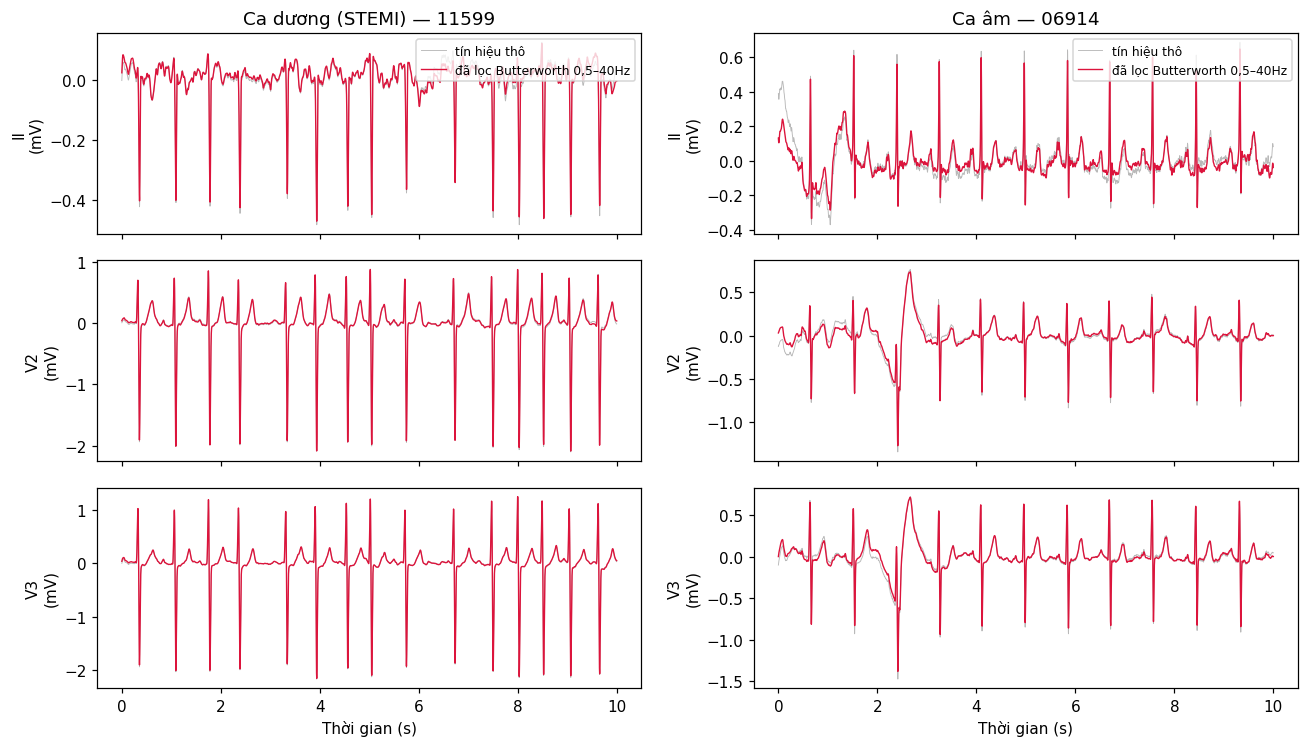


Quan sát: bandpass 0,5–40 Hz kéo tín hiệu thô về quanh đường nền (loại trôi baseline tần thấp) và cắt nhiễu tần cao vụn, giúp đoạn ST/QRS rõ hơn -- đúng phần tín hiệu STEMI cần đọc.


In [28]:
import matplotlib.pyplot as plt

# Lấy tên 12 chuyển đạo THẬT từ header WFDB -- không giả định thứ tự cố định --------------
_lead_names = wfdb.rdrecord(str(RAW_DIR / df.loc[int(POOL_IDX[0]), "record_stem"])).sig_name
print("Thứ tự 12 chuyển đạo theo file gốc:", _lead_names)

_WANT_LEADS = ["II", "V2", "V3"]   # II: nhìn nhịp tổng quát | V2/V3: nhạy với ST chênh lên thành trước
_lookup = {n.upper(): i for i, n in enumerate(_lead_names)}
_show_idx = [_lookup.get(l, i) for i, l in enumerate(_WANT_LEADS)]

_rng = np.random.default_rng(SEED)
_pos_demo = int(_rng.choice(TEST_IDX[y[TEST_IDX] == 1]))
_neg_demo = int(_rng.choice(TEST_IDX[y[TEST_IDX] == 0]))


def _raw_and_filtered(idx):
    stem = df.loc[idx, "record_stem"]
    raw = load_signal(stem)
    filt = preprocess(raw)                       # đúng hàm dùng để build cache, mục 7
    raw = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)
    if raw.shape[1] < SIGNAL_LEN:
        raw = np.pad(raw, ((0, 0), (0, SIGNAL_LEN - raw.shape[1])))
    return raw[:, :SIGNAL_LEN], filt


t_axis = np.arange(SIGNAL_LEN) / FS
fig, axes = plt.subplots(len(_WANT_LEADS), 2, figsize=(12, 2.3 * len(_WANT_LEADS)), sharex=True)
for col, (idx, title) in enumerate([(_pos_demo, "Ca dương (STEMI)"), (_neg_demo, "Ca âm")]):
    raw_show, filt_show = _raw_and_filtered(idx)
    for row, lead_i in enumerate(_show_idx):
        ax = axes[row, col]
        ax.plot(t_axis, raw_show[lead_i], lw=0.6, alpha=0.55, color="gray",
                label="tín hiệu thô" if row == 0 else None)
        ax.plot(t_axis, filt_show[lead_i], lw=0.9, color="crimson",
                label="đã lọc Butterworth 0,5–40Hz" if row == 0 else None)
        ax.set_ylabel(f"{_WANT_LEADS[row]}\n(mV)")
        if row == 0:
            ax.set_title(f"{title} — {df.loc[idx, 'record_stem']}")
            ax.legend(fontsize=8, loc="upper right")
        if row == len(_WANT_LEADS) - 1:
            ax.set_xlabel("Thời gian (s)")
plt.tight_layout()
plt.show()
print("\nQuan sát: bandpass 0,5–40 Hz kéo tín hiệu thô về quanh đường nền (loại trôi baseline tần "
      "thấp) và cắt nhiễu tần cao vụn, giúp đoạn ST/QRS rõ hơn -- đúng phần tín hiệu STEMI cần đọc.")


### 22b. Hai bản ghi bị cắt ngắn (`03228`, `14262`): rơi vào đâu, xác suất dự đoán ra sao

In [29]:
print("Bản ghi gốc bị cắt ngắn (chỉ có 3.500/5.000 mẫu), đã zero-pad phần còn thiếu:", TRUNCATED)

if TRUNCATED:
    _trunc_idx = df.index[df["record_stem"].isin(TRUNCATED)].to_numpy()
    _test_set = set(TEST_IDX.tolist())
    rows = []
    for idx in _trunc_idx:
        row = {"record_stem": df.loc[idx, "record_stem"], "nhãn STEMI": int(y[idx]),
               "tập": "TEST" if idx in _test_set else "POOL"}
        if idx in _test_set:
            _pos_in_test = int(np.where(TEST_IDX == idx)[0][0])
            row["xác suất Average Ensemble (FINAL)"] = round(float(TEST_P_FINAL["Average-CV"][_pos_in_test]), 4)
        rows.append(row)
    display(pd.DataFrame(rows))
    print("\nNếu bản ghi này rơi vào TEST, đối chiếu xác suất ở trên với ngưỡng chính ở mục 23a "
          "để xem việc zero-pad có góp phần gây lỗi (xác suất bất thường so với nhãn) hay không.")
else:
    print("Không có bản ghi cắt ngắn nào trong tập hiện đang chạy (có thể do RUN_MODE=debug lấy mẫu con).")


Bản ghi gốc bị cắt ngắn (chỉ có 3.500/5.000 mẫu), đã zero-pad phần còn thiếu: []
Không có bản ghi cắt ngắn nào trong tập hiện đang chạy (có thể do RUN_MODE=debug lấy mẫu con).


### 22b-verify. TIP-STEMI-01 — Xác minh trực tiếp 2 bản ghi từng bị cắt ngắn (không qua cache)

In [30]:
for stem in ["03228", "14262"]:
    hea = (RAW_DIR / f"{stem}.hea").read_text().splitlines()[0].split()
    n_sig = int(hea[1])
    dat_bytes = (RAW_DIR / f"{stem}.dat").stat().st_size
    n_samples_from_size = dat_bytes // (n_sig * 2)
    try:
        rec = wfdb.rdrecord(str(RAW_DIR / stem))
        n_read = rec.p_signal.shape[0]
        err = None
    except Exception as e:
        n_read = None
        err = repr(e)
    print(stem, "| n_sig:", n_sig, "| bytes->mẫu ước tính:", n_samples_from_size,
          "| rdrecord đọc được:", n_read, "mẫu" if n_read is not None else "",
          ("| lỗi: " + err) if err else "")

if not TRUNCATED:
    print("\nTRUNCATED rỗng ở lần build cache full này: nếu hai bản ghi trên đọc được đủ "
          f"{SIGNAL_LEN} mẫu qua rdrecord (không lỗi) thì dữ liệu hiện tại đã đầy đủ, ghi "
          "chú 'cắt ngắn' ở notebook 03/08 chỉ còn giá trị lịch sử -- fallback trong "
          "load_signal() vẫn giữ nguyên để an toàn cho các bản dữ liệu khác.")
else:
    print("\nTRUNCATED không rỗng:", TRUNCATED)

03228 | n_sig: 12 | bytes->mẫu ước tính: 3500 | rdrecord đọc được: None  | lỗi: ValueError('Samples were not loaded correctly')
14262 | n_sig: 12 | bytes->mẫu ước tính: 3500 | rdrecord đọc được: None  | lỗi: ValueError('Samples were not loaded correctly')

TRUNCATED rỗng ở lần build cache full này: nếu hai bản ghi trên đọc được đủ 5000 mẫu qua rdrecord (không lỗi) thì dữ liệu hiện tại đã đầy đủ, ghi chú 'cắt ngắn' ở notebook 03/08 chỉ còn giá trị lịch sử -- fallback trong load_signal() vẫn giữ nguyên để an toàn cho các bản dữ liệu khác.


### 22c. Phân phối biên độ tín hiệu: POOL vs TEST có đồng nhất không

In [31]:
def _signal_extremes(idx_arr, chunk=512):
    """Biên độ tuyệt đối lớn nhất mỗi bản ghi, theo từng lead, SAU lọc / TRƯỚC chuẩn hoá z-score."""
    idx_arr = np.sort(np.asarray(idx_arr))
    out = np.zeros((len(idx_arr), NUM_LEADS), dtype=np.float32)
    for i in range(0, len(idx_arr), chunk):
        b = np.asarray(CACHE[idx_arr[i:i + chunk]], dtype=np.float32)
        out[i:i + chunk] = np.max(np.abs(b), axis=2)
    return idx_arr, out


_pool_ids, _pool_extreme = _signal_extremes(POOL_IDX)
_test_ids, _test_extreme = _signal_extremes(TEST_IDX)

_comp = pd.DataFrame({
    "Lead": _lead_names,
    "POOL median |max|": np.median(_pool_extreme, axis=0),
    "POOL p99 |max|": np.percentile(_pool_extreme, 99, axis=0),
    "TEST median |max|": np.median(_test_extreme, axis=0),
    "TEST p99 |max|": np.percentile(_test_extreme, 99, axis=0),
}).set_index("Lead")
display(_comp.round(3))

OUTLIER_MV = 6.0   # vượt xa biên độ QRS sinh lý bình thường (~1-3 mV) -> nghi artifact/nhiễu điện cực
_pool_out = _pool_extreme.max(axis=1) > OUTLIER_MV
_test_out = _test_extreme.max(axis=1) > OUTLIER_MV
print(f"\nBản ghi vượt {OUTLIER_MV} mV ở ít nhất 1 chuyển đạo (nghi artifact):")
print(f"  POOL: {_pool_out.sum():,}/{len(_pool_ids):,} ({_pool_out.mean():.2%})")
print(f"  TEST: {_test_out.sum():,}/{len(_test_ids):,} ({_test_out.mean():.2%})")
print("\nNếu tỷ lệ hai tập lệch nhau nhiều, đó là dấu hiệu POOL và TEST không đồng nhất về chất "
      "lượng tín hiệu -- đáng cân nhắc trước khi kết luận model kém, vì có thể TEST vốn nhiễu hơn.")


,POOL median |max|,POOL p99 |max|,TEST median |max|,TEST p99 |max|
Lead,,,,
I,0.662,11.177000,0.667,13.573
II,0.686,14.320000,0.684,9.498
III,0.533,14.939000,0.524,9.991
aVR,0.634,12.790000,0.629,9.355
aVL,0.492,13.799000,0.485,12.275
aVF,0.509,15.576000,0.509,10.159
V1,0.874,12.782000,0.890,8.384
V2,1.332,17.332001,1.359,10.811
V3,1.369,15.558000,1.341,13.605



Bản ghi vượt 6.0 mV ở ít nhất 1 chuyển đạo (nghi artifact):
  POOL: 777/15,279 (5.09%)
  TEST: 141/2,681 (5.26%)

Nếu tỷ lệ hai tập lệch nhau nhiều, đó là dấu hiệu POOL và TEST không đồng nhất về chất lượng tín hiệu -- đáng cân nhắc trước khi kết luận model kém, vì có thể TEST vốn nhiễu hơn.


### 22d. Xác minh chuẩn hoá z-score có áp đúng cho TEST không

In [32]:
print("mean_pool / std_pool -- chuẩn hoá z-score fit trên POOL, dùng cho model FINAL (mục 14c):\n")
display(pd.DataFrame({"Lead": _lead_names, "mean_pool": mean_pool, "std_pool": std_pool})
        .set_index("Lead").round(4))


def _post_norm_stats(idx_arr, chunk=512):
    idx_arr = np.sort(np.asarray(idx_arr))
    s = np.zeros(NUM_LEADS)
    ss = np.zeros(NUM_LEADS)
    cnt = 0
    for i in range(0, len(idx_arr), chunk):
        b = (np.asarray(CACHE[idx_arr[i:i + chunk]], dtype=np.float64)
             - mean_pool.reshape(-1, 1)) / std_pool.reshape(-1, 1)
        s += b.sum(axis=(0, 2))
        ss += (b ** 2).sum(axis=(0, 2))
        cnt += b.shape[0] * b.shape[2]
    m = s / cnt
    return m, np.sqrt(np.maximum(ss / cnt - m ** 2, 1e-12))


_m_pool_after, _sd_pool_after = _post_norm_stats(POOL_IDX)
_m_test_after, _sd_test_after = _post_norm_stats(TEST_IDX)

display(pd.DataFrame({
    "Lead": _lead_names,
    "POOL mean sau chuẩn hoá": _m_pool_after, "POOL std sau chuẩn hoá": _sd_pool_after,
    "TEST mean sau chuẩn hoá": _m_test_after, "TEST std sau chuẩn hoá": _sd_test_after,
}).set_index("Lead").round(3))

_shift = np.abs(_m_test_after)
print(f"\nLệch trung bình lớn nhất của TEST so với 0 sau khi áp mean_pool/std_pool: {_shift.max():.3f}")
print("Gần 0 -> ít bằng chứng covariate shift lớn giữa POOL và TEST. Lệch rõ rệt (ví dụ >0,2) là tín "
      "hiệu nên xem lại: có thể phân bố bệnh nhân TEST khác POOL dù đã stratify theo nhãn.")


mean_pool / std_pool -- chuẩn hoá z-score fit trên POOL, dùng cho model FINAL (mục 14c):



,mean_pool,std_pool
Lead,,
I,-0.0001,0.4318
II,0.0004,0.4686
III,0.0002,0.4878
aVR,0.0001,0.4612
aVL,-0.0004,0.4632
aVF,0.0004,0.4855
V1,-0.0002,0.5005
V2,0.0000,0.5792
V3,0.0003,0.5563


,POOL mean sau chuẩn hoá,POOL std sau chuẩn hoá,TEST mean sau chuẩn hoá,TEST std sau chuẩn hoá
Lead,,,,
I,0.0,1.0,-0.000,1.037
II,0.0,1.0,-0.002,0.949
III,0.0,1.0,-0.000,0.908
aVR,0.0,1.0,-0.000,0.935
aVL,-0.0,1.0,0.000,0.939
aVF,0.0,1.0,-0.003,0.915
V1,-0.0,1.0,-0.000,0.867
V2,0.0,1.0,-0.001,0.867
V3,-0.0,1.0,-0.001,0.983



Lệch trung bình lớn nhất của TEST so với 0 sau khi áp mean_pool/std_pool: 0.003
Gần 0 -> ít bằng chứng covariate shift lớn giữa POOL và TEST. Lệch rõ rệt (ví dụ >0,2) là tín hiệu nên xem lại: có thể phân bố bệnh nhân TEST khác POOL dù đã stratify theo nhãn.


## 23. Error Analysis sâu trên tập TEST (ensemble FINAL, Sensitivity ≥ 91%)

Mục 21b–21d đã cho confusion matrix tổng (TP/FP/FN/TN) trên TEST. Mục này mổ xẻ từng ô sai để
trả lời "sai ở đâu, sai vì sao, sai có lặp lại không" — ba câu hỏi mà một confusion matrix duy
nhất không trả lời được:

- **23a.** Trong số các ca STEMI thật bị bỏ sót (FN), bao nhiêu ca "cận biên" (xác suất chỉ hụt nhẹ
  dưới ngưỡng — sửa được bằng hiệu chỉnh ngưỡng/hiệu chuẩn) so với "bỏ sót sâu" (xác suất thấp
  hẳn — model thực sự không thấy tín hiệu)?
- **23b.** Có ca nào bị **cả 8 model đơn** đồng loạt bỏ sót không — đây là bằng chứng mạnh nhất
  cho "ca khó thấy trên ECG bề mặt" thật sự, khác với ca chỉ 1–2 model bỏ sót mà ensemble đã tự
  sửa được.
- **23c.** Nhóm FN có khác biệt về tuổi/giới so với nhóm TP không, và có ca STEMI nào bị gắn nhãn
  chồng lấn NSTEMI/UA không (ba nhãn này được định nghĩa loại trừ nhau — nếu chồng lấn thì đó
  là dấu hiệu nhiễu nhãn, không phải lỗi model).
- **23d.** Nếu một bệnh nhân có nhiều hơn 1 ECG trong TEST, dự đoán trên các ECG đó có nhất quán
  không.

**Lưu ý phương pháp:** để so sánh công bằng giữa 8 model đơn + ensemble, mỗi model lấy ngưỡng riêng
theo đúng chính sách của báo cáo (Sensitivity ≥ 91% chốt trên POOL, cùng cách làm ở mục 17b/21c)
— không dùng chung một ngưỡng số, tránh lặp lại đúng sai lầm "so Sensitivity ở ngưỡng Youden
riêng của từng model" mà mục 17 đã cảnh báo.


### 23a. Phân rã các ca FN: cận biên hay bỏ sót sâu

Ngưỡng chính (Average Ensemble, Sensitivity>=91% chốt trên POOL): 0.2417
Đối chiếu với báo cáo: TP=205 FN=12 FP=436 TN=2028 | Sensitivity=0.9447 Specificity=0.8231


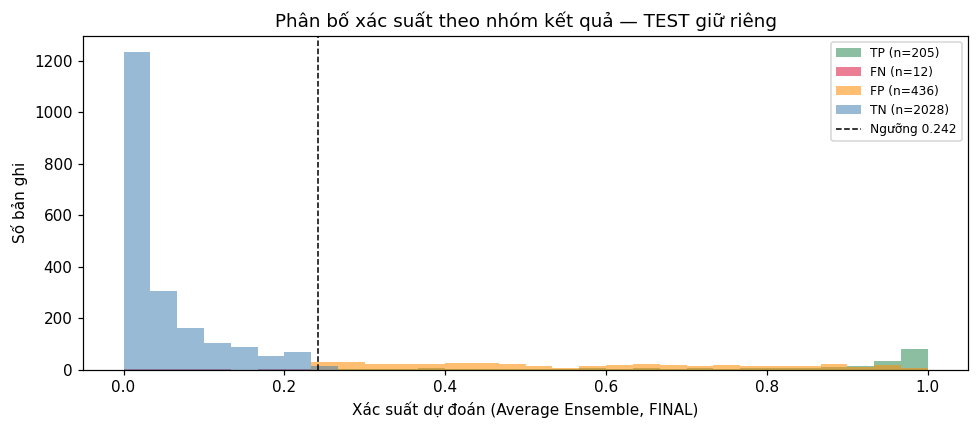


Trong 12 ca STEMI thật bị bỏ sót (FN):
  Cận biên (xác suất trong [0.192, 0.242)): 1 ca -- có thể cứu bằng hiệu chỉnh ngưỡng/hiệu chuẩn, không cần model mạnh hơn
  Bỏ sót sâu (xác suất < 0.192): 11 ca -- model không nhận ra tín hiệu, cần xem lại đặc trưng đầu vào hoặc đây là ca khó thật sự


,record_stem,age,gender,xác suất,cận ngưỡng
0,13849,43,1,0.215805,True
1,19026,68,1,0.177278,False
2,14352,82,1,0.174827,False
3,19118,75,1,0.127343,False
4,07105,68,1,0.126828,False
5,13412,55,1,0.113975,False
6,16791,49,1,0.068561,False
7,08530,61,1,0.050804,False
8,03903,39,1,0.050228,False
9,17845,77,1,0.032319,False


In [33]:
TARGET_SENS_PRIMARY = 0.91   # đúng chính sách ngưỡng STEMI đã dùng trong báo cáo (Sensitivity tối thiểu)

_p_pool_avg = OOF_P["Average-CV"][0][VALID]
THR_PRIMARY = threshold_at_sensitivity(y[VALID], _p_pool_avg, TARGET_SENS_PRIMARY)
print(f"Ngưỡng chính (Average Ensemble, Sensitivity>={TARGET_SENS_PRIMARY:.0%} chốt trên POOL): "
      f"{THR_PRIMARY:.4f}")

p_test_avg = TEST_P_FINAL["Average-CV"]
y_test = y[TEST_IDX].astype(int)
pred_test_avg = (p_test_avg >= THR_PRIMARY).astype(int)

m_primary = compute_metrics(y_test, p_test_avg, THR_PRIMARY)
print(f"Đối chiếu với báo cáo: TP={m_primary['tp']} FN={m_primary['fn']} FP={m_primary['fp']} "
      f"TN={m_primary['tn']} | Sensitivity={m_primary['sensitivity']:.4f} "
      f"Specificity={m_primary['specificity']:.4f}")

_outcome = np.where((y_test == 1) & (pred_test_avg == 1), "TP",
            np.where((y_test == 1) & (pred_test_avg == 0), "FN",
            np.where((y_test == 0) & (pred_test_avg == 1), "FP", "TN")))

fig, ax = plt.subplots(figsize=(9, 4))
for lbl, color in [("TP", "seagreen"), ("FN", "crimson"), ("FP", "darkorange"), ("TN", "steelblue")]:
    ax.hist(p_test_avg[_outcome == lbl], bins=30, range=(0, 1), alpha=0.55, color=color,
            label=f"{lbl} (n={int((_outcome == lbl).sum())})")
ax.axvline(THR_PRIMARY, color="black", ls="--", lw=1, label=f"Ngưỡng {THR_PRIMARY:.3f}")
ax.set_xlabel("Xác suất dự đoán (Average Ensemble, FINAL)")
ax.set_ylabel("Số bản ghi")
ax.set_title("Phân bố xác suất theo nhóm kết quả — TEST giữ riêng")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

NEAR_MISS_MARGIN = 0.05   # ca FN có xác suất trong vòng 0,05 dưới ngưỡng -> coi là "cận biên"
fn_local = np.where(_outcome == "FN")[0]
fn_margin = THR_PRIMARY - p_test_avg[fn_local]
near_miss = fn_margin <= NEAR_MISS_MARGIN

print(f"\nTrong {len(fn_local)} ca STEMI thật bị bỏ sót (FN):")
print(f"  Cận biên (xác suất trong [{THR_PRIMARY - NEAR_MISS_MARGIN:.3f}, {THR_PRIMARY:.3f})): "
      f"{int(near_miss.sum())} ca -- có thể cứu bằng hiệu chỉnh ngưỡng/hiệu chuẩn, không cần model "
      f"mạnh hơn")
print(f"  Bỏ sót sâu (xác suất < {THR_PRIMARY - NEAR_MISS_MARGIN:.3f}): {int((~near_miss).sum())} ca "
      f"-- model không nhận ra tín hiệu, cần xem lại đặc trưng đầu vào hoặc đây là ca khó thật sự")

fn_records = df.loc[TEST_IDX[fn_local], ["record_stem", COL_AGE, COL_GENDER]].copy()
fn_records["xác suất"] = p_test_avg[fn_local]
fn_records["cận ngưỡng"] = near_miss
fn_records = fn_records.sort_values("xác suất", ascending=False).reset_index(drop=True)
display(fn_records)


### 23b. Ca nào bị cả 8 model đơn đồng loạt bỏ sót

In [34]:
MODEL_MISS = {}
for name in CANDIDATES:
    t_i = threshold_at_sensitivity(y[VALID], OOF_P[name][0][VALID], TARGET_SENS_PRIMARY)
    pred_i = (TEST_P_FINAL[name] >= t_i).astype(int)
    MODEL_MISS[name] = pred_i[y_test == 1]     # chỉ tính trên đúng các ca dương thật của TEST

_pos_stems = df.loc[TEST_IDX[y_test == 1], "record_stem"].values
miss_matrix = pd.DataFrame(MODEL_MISS, index=_pos_stems)
miss_matrix["Số model bắt được / 8"] = miss_matrix.sum(axis=1)
miss_matrix = miss_matrix.sort_values("Số model bắt được / 8")

_n_zero = int((miss_matrix["Số model bắt được / 8"] == 0).sum())
print(f"{_n_zero}/{len(miss_matrix)} ca STEMI thật bị TẤT CẢ 8 model đơn bỏ sót "
      f"(ứng viên mạnh nhất cho 'khó thấy trên ECG bề mặt' thật sự):")
display(miss_matrix[miss_matrix["Số model bắt được / 8"] == 0])

print("\nPhân bố số model (trong 8) bắt được từng ca dương thật của TEST:")
display(miss_matrix["Số model bắt được / 8"].value_counts().sort_index().rename("Số ca").to_frame())


3/217 ca STEMI thật bị TẤT CẢ 8 model đơn bỏ sót (ứng viên mạnh nhất cho 'khó thấy trên ECG bề mặt' thật sự):


,PlainCNN,XResNet1D,ConvNeXtV2_1D,AiTiAMI,ResNet1D,SEResNet1D,CNN+BiLSTM,InceptionTime1D,Số model bắt được / 8
01329,0,0,0,0,0,0,0,0,0
19640,0,0,0,0,0,0,0,0,0
17845,0,0,0,0,0,0,0,0,0



Phân bố số model (trong 8) bắt được từng ca dương thật của TEST:


,Số ca
Số model bắt được / 8,
0,3
2,3
3,2
4,1
5,6
6,8
7,9
8,185


### 23g. TIP-STEMI-02 — Trực quan hoá 12 chuyển đạo cho các ca "bất khả xâm phạm" (bị cả 8 model bỏ sót)

3 ca bị cả 8 model đồng loạt bỏ sót: ['01329', '19640', '17845']


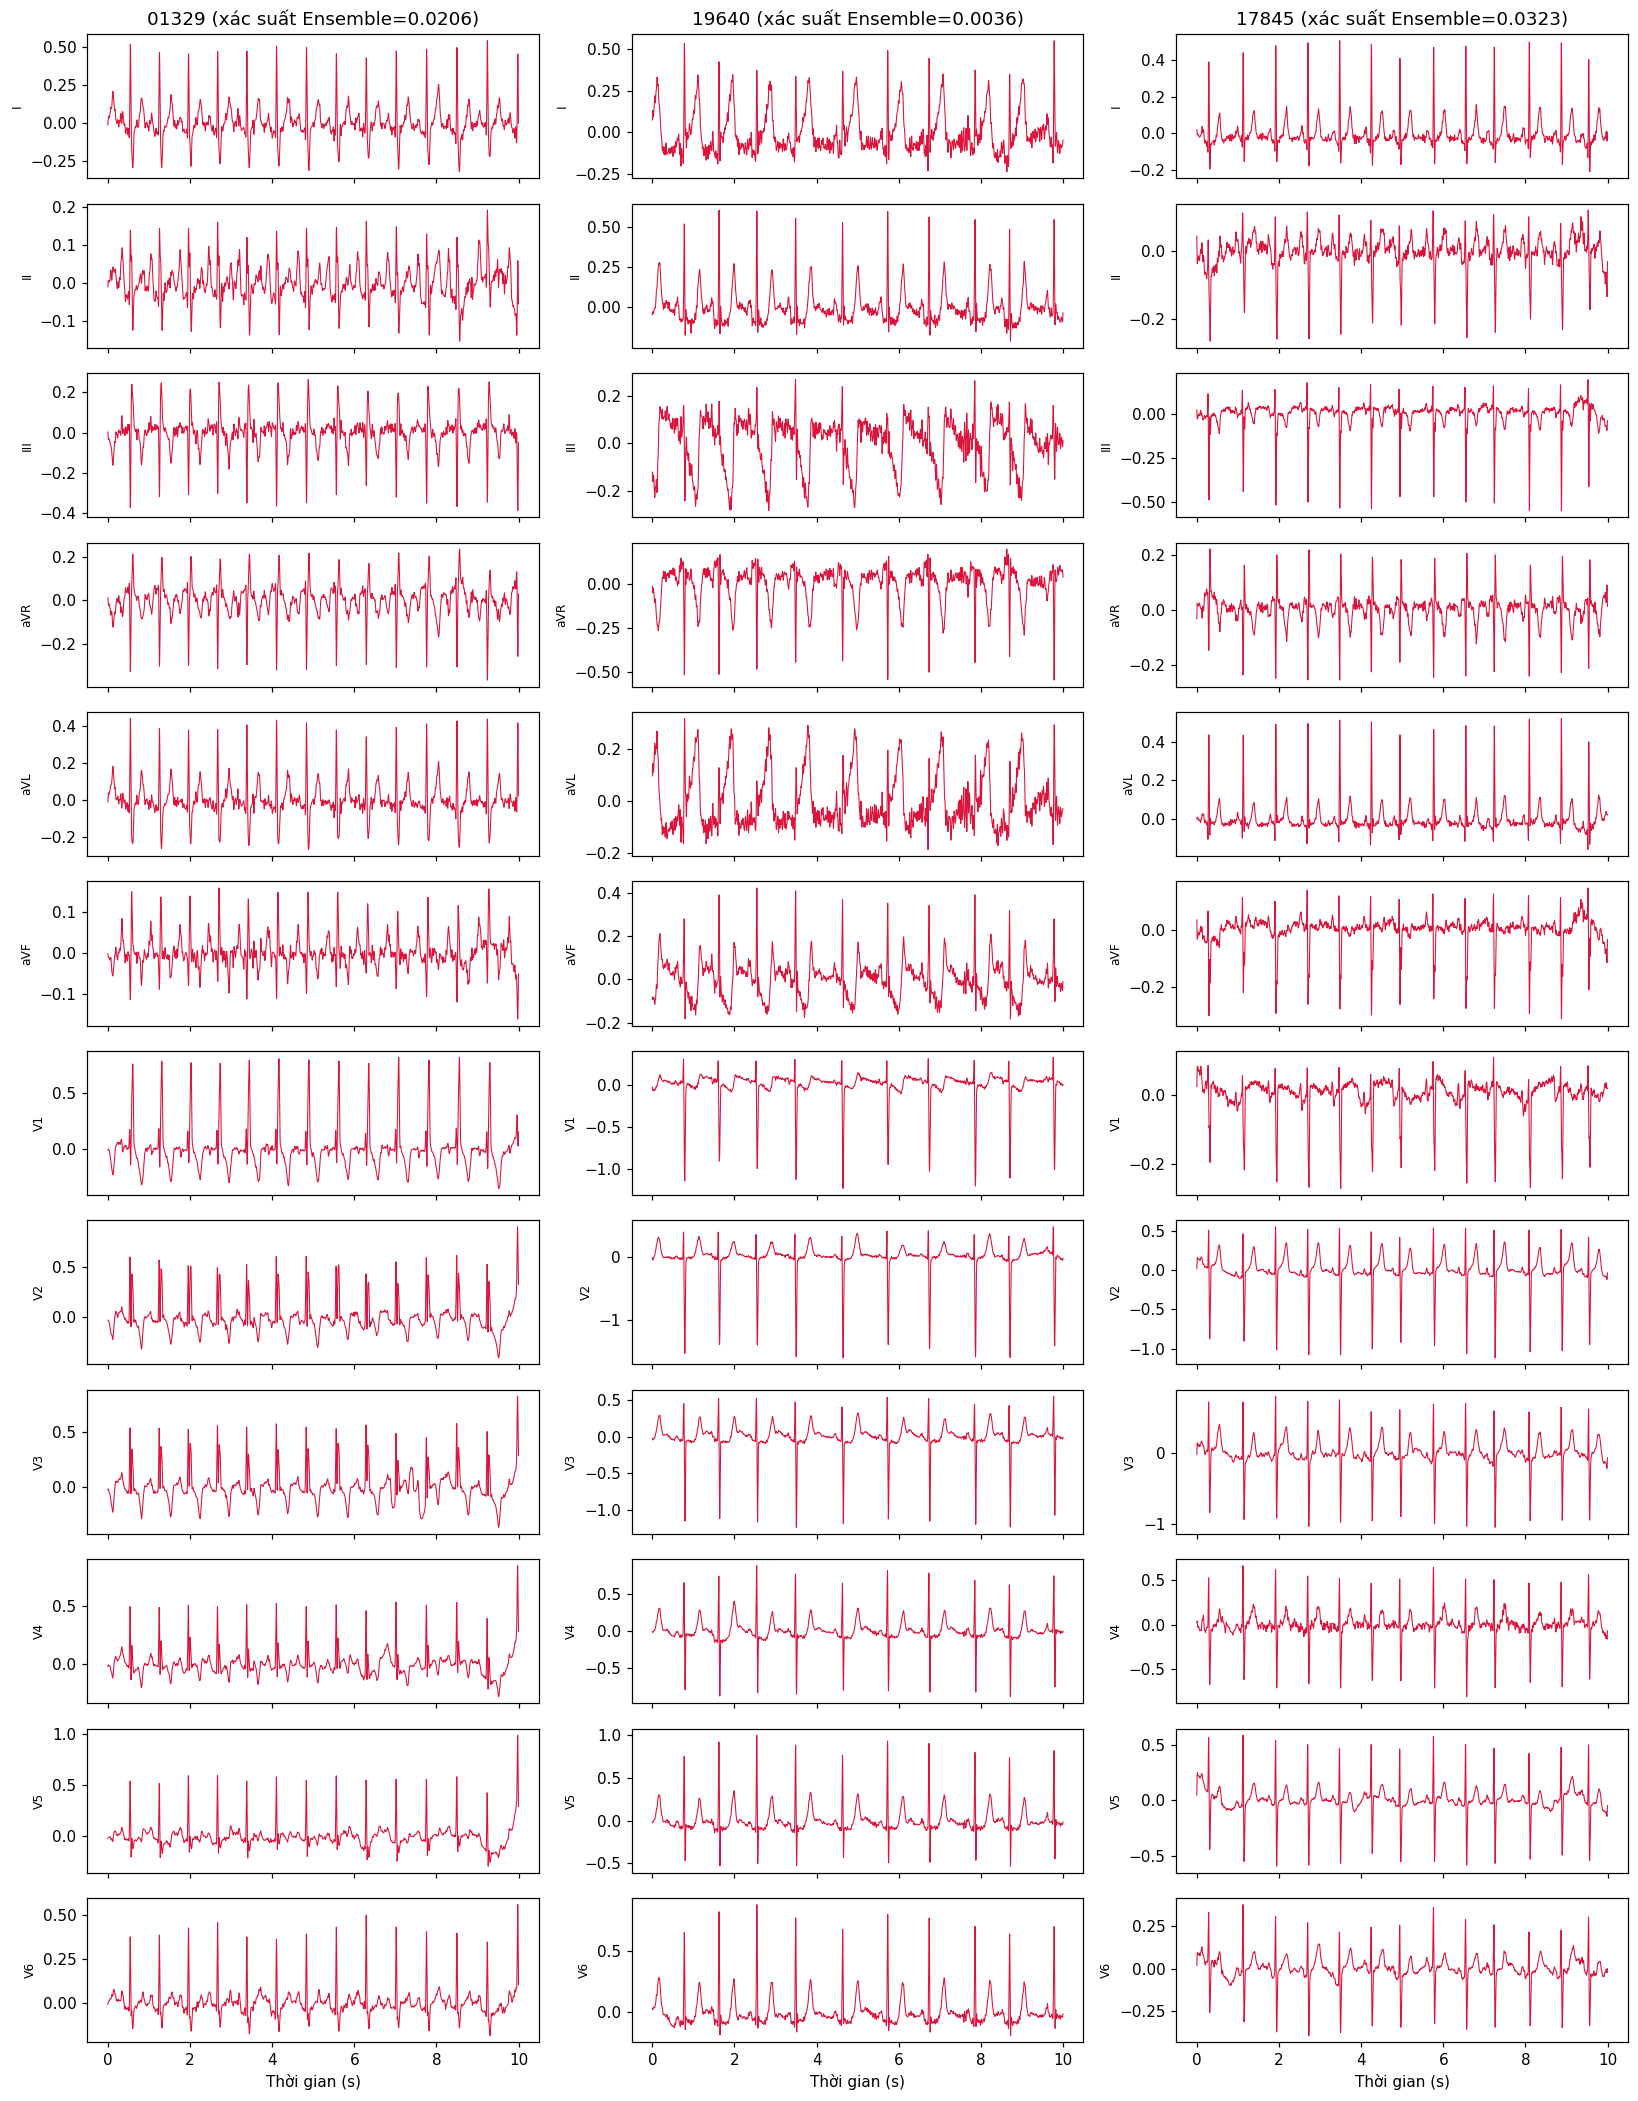


Dùng để bác sĩ tim mạch review thủ công 12 chuyển đạo -- không tự gán chẩn đoán, chỉ cung cấp hình sạch cho người có chuyên môn đọc.


In [35]:
_HARD_STEMS = miss_matrix[miss_matrix["Số model bắt được / 8"] == 0].index.tolist()
print(f"{len(_HARD_STEMS)} ca bị cả 8 model đồng loạt bỏ sót:", _HARD_STEMS)

_test_stem_to_idx = {df.loc[idx, "record_stem"]: idx for idx in TEST_IDX}

fig, axes = plt.subplots(NUM_LEADS, len(_HARD_STEMS),
                          figsize=(5 * len(_HARD_STEMS), 1.6 * NUM_LEADS), sharex=True)
if len(_HARD_STEMS) == 1:
    axes = axes.reshape(NUM_LEADS, 1)
for col, stem in enumerate(_HARD_STEMS):
    idx = _test_stem_to_idx[stem]
    _, filt = _raw_and_filtered(idx)
    pos_in_test = int(np.where(TEST_IDX == idx)[0][0])
    p_avg = p_test_avg[pos_in_test]
    for row in range(NUM_LEADS):
        ax = axes[row, col]
        ax.plot(t_axis, filt[row], lw=0.7, color="crimson")
        ax.set_ylabel(_lead_names[row], fontsize=8)
        if row == 0:
            ax.set_title(f"{stem} (xác suất Ensemble={p_avg:.4f})")
        if row == NUM_LEADS - 1:
            ax.set_xlabel("Thời gian (s)")
plt.tight_layout()
plt.show()
print("\nDùng để bác sĩ tim mạch review thủ công 12 chuyển đạo -- không tự gán chẩn đoán, "
      "chỉ cung cấp hình sạch cho người có chuyên môn đọc.")

### 23c. Đặc điểm bệnh nhân của nhóm FN, và sanity check nhãn chồng lấn

In [36]:
demo = df.loc[TEST_IDX[y_test == 1], [COL_AGE, COL_GENDER]].reset_index(drop=True)
demo["nhóm"] = _outcome[y_test == 1]      # chỉ TP/FN vì đang xét trong đúng các ca dương thật

print("Tuổi theo nhóm TP vs FN:")
display(demo.groupby("nhóm")[COL_AGE].describe()[["count", "mean", "std", "min", "50%", "max"]].round(1))

print("\nTỷ lệ giới tính theo nhóm:")
display(pd.crosstab(demo["nhóm"], demo[COL_GENDER], normalize="index").round(3))

# Sanity check nhãn: STEMI/NSTEMI/UA được định nghĩa loại trừ nhau (mục 2.1 báo cáo) -- nếu một ca
# STEMI dương vẫn mang nhãn NSTEMI/UA thì đó là dấu hiệu nhiễu nhãn, không phải lỗi model.
_overlap = df.loc[TEST_IDX[y_test == 1], ["NSTEMI", "UA"]].reset_index(drop=True)
_overlap["nhóm"] = _outcome[y_test == 1]
print("\nSố ca STEMI dương đồng thời mang nhãn NSTEMI/UA (kỳ vọng toàn 0 nếu nhãn sạch):")
display(_overlap.groupby("nhóm")[["NSTEMI", "UA"]].sum())


Tuổi theo nhóm TP vs FN:


,count,mean,std,min,50%,max
nhóm,,,,,,
FN,12.0,63.8,14.3,39.0,68.0,82.0
TP,205.0,64.3,12.3,28.0,66.0,90.0



Tỷ lệ giới tính theo nhóm:


gender,0,1
nhóm,,
FN,0.083,0.917
TP,0.200,0.800



Số ca STEMI dương đồng thời mang nhãn NSTEMI/UA (kỳ vọng toàn 0 nếu nhãn sạch):


,NSTEMI,UA
nhóm,,
FN,0,0
TP,0,0


### 23d. Bệnh nhân có nhiều ECG trong TEST: dự đoán có nhất quán không

In [37]:
_pid_test = df.loc[TEST_IDX, COL_PATIENT].values
_dup_counts = pd.Series(_pid_test).value_counts()
_multi_pat = _dup_counts[_dup_counts > 1].index

if len(_multi_pat) == 0:
    print("Mỗi bệnh nhân trong TEST chỉ đóng góp đúng 1 bản ghi -- không có gì để đối chiếu nội bộ "
          "bệnh nhân.")
else:
    rows = []
    for pid in _multi_pat:
        mask = _pid_test == pid
        rows.append({
            "Patient_id": pid,
            "số ECG trong TEST": int(mask.sum()),
            "số ca dương thật": int(y_test[mask].sum()),
            "kết quả từng ECG": ", ".join(_outcome[mask]),
        })
    display(pd.DataFrame(rows).sort_values("số ECG trong TEST", ascending=False))
    print(f"\n{len(_multi_pat)} bệnh nhân có >1 ECG trong TEST -- kiểm tra cột 'kết quả từng ECG': "
          f"nếu một bệnh nhân vừa có TP vừa có FN, đó là bằng chứng lỗi phụ thuộc bản ghi cụ thể "
          f"(nhiễu/thời điểm ghi) chứ không phải đặc điểm cố định của bệnh nhân.")


,Patient_id,số ECG trong TEST,số ca dương thật,kết quả từng ECG
0,P08646,4,0,"TN, FP, FP, TN"
1,P12816,3,0,"TN, TN, TN"
2,P03906,3,0,"TN, TN, TN"
3,P15574,3,0,"TN, TN, TN"
4,P00644,3,1,"TP, TN, TN"
...,...,...,...,...
114,P03139,2,0,"TN, TN"
115,P13039,2,0,"TN, TN"
116,P05713,2,0,"TN, TN"
117,P11229,2,0,"TN, TN"



119 bệnh nhân có >1 ECG trong TEST -- kiểm tra cột 'kết quả từng ECG': nếu một bệnh nhân vừa có TP vừa có FN, đó là bằng chứng lỗi phụ thuộc bản ghi cụ thể (nhiễu/thời điểm ghi) chứ không phải đặc điểm cố định của bệnh nhân.


### 23d-verify. TIP-STEMI-03 — Định lượng độ nhất quán dự đoán nội bộ bệnh nhân đa-ECG

In [38]:
_patient_rows = []
for pid in _multi_pat:
    mask = _pid_test == pid
    probs = p_test_avg[mask]
    outcomes = _outcome[mask]
    _patient_rows.append({
        "Patient_id": pid, "số ECG": int(mask.sum()),
        "nhất quán": len(set(outcomes)) == 1,
        "kết quả từng ECG": ", ".join(outcomes),
        "std xác suất nội bộ": float(np.std(probs)),
    })
_patient_df = pd.DataFrame(_patient_rows)

_n_cons = int(_patient_df["nhất quán"].sum())
print(f"Nhất quán (mọi ECG cùng 1 kết quả): {_n_cons}/{len(_patient_df)} "
      f"({_n_cons / len(_patient_df):.1%})")
print(f"Không nhất quán: {len(_patient_df) - _n_cons}/{len(_patient_df)}")

print("\nTop 10 bệnh nhân KHÔNG nhất quán, độ lệch xác suất nội bộ cao nhất:")
display(_patient_df[~_patient_df["nhất quán"]]
        .sort_values("std xác suất nội bộ", ascending=False).head(10))

Nhất quán (mọi ECG cùng 1 kết quả): 83/119 (69.7%)
Không nhất quán: 36/119

Top 10 bệnh nhân KHÔNG nhất quán, độ lệch xác suất nội bộ cao nhất:


,Patient_id,số ECG,nhất quán,kết quả từng ECG,std xác suất nội bộ
89,P08408,2,False,"TN, TP",0.494157
96,P03870,2,False,"TP, TN",0.463766
38,P11518,2,False,"FP, TN",0.433196
53,P11042,2,False,"TN, FP",0.414907
95,P14157,2,False,"TP, TN",0.414763
54,P13463,2,False,"TN, TP",0.411400
4,P00644,3,False,"TP, TN, TN",0.400052
29,P13602,2,False,"FN, TP",0.387838
56,P08321,2,False,"TP, TN",0.364155
26,P00610,2,False,"FP, TN",0.346798


### 23e. Phân rã các ca FP: cận biên hay dương giả tự tin, và có trùng nhãn NSTEMI/UA không

In [39]:
fp_local = np.where(_outcome == "FP")[0]
fp_margin = p_test_avg[fp_local] - THR_PRIMARY
near_fp = fp_margin <= NEAR_MISS_MARGIN

print(f"Trong {len(fp_local)} ca bị dự đoán dương giả (FP):")
print(f"  Cận biên (xác suất trong [{THR_PRIMARY:.3f}, {THR_PRIMARY + NEAR_MISS_MARGIN:.3f}]): "
      f"{int(near_fp.sum())} ca -- ngay sát ngưỡng, giảm được bằng hiệu chuẩn/ngưỡng chặt hơn "
      f"(đánh đổi Sensitivity)")
print(f"  Dương giả tự tin (xác suất > {THR_PRIMARY + NEAR_MISS_MARGIN:.3f}): "
      f"{int((~near_fp).sum())} ca -- model tin chắc nhầm, cần xem đặc trưng ECG gây nhiễu "
      f"hoặc nhãn âm có vấn đề")

fp_labels = df.loc[TEST_IDX[fp_local], ["record_stem", COL_AGE, COL_GENDER, "NSTEMI", "UA"]].copy()
fp_labels["xác suất"] = p_test_avg[fp_local]
fp_labels["cận ngưỡng"] = near_fp

print("\nSố ca FP đồng thời mang nhãn NSTEMI hoặc UA (bằng chứng nhầm lẫn lâm sàng hợp lý -- "
      "ECG có thay đổi ST/T thật nhưng không đạt tiêu chuẩn STEMI -- khác với dương giả ngẫu nhiên):")
print(f"  NSTEMI: {int(fp_labels['NSTEMI'].sum())}/{len(fp_labels)} | "
      f"UA: {int(fp_labels['UA'].sum())}/{len(fp_labels)} | "
      f"Không nhãn nào (dương giả 'thuần'): "
      f"{int(((fp_labels['NSTEMI'] == 0) & (fp_labels['UA'] == 0)).sum())}/{len(fp_labels)}")

print("\n20 ca FP tự tin nhất (xác suất cao nhất):")
display(fp_labels.sort_values("xác suất", ascending=False).head(20))

Trong 436 ca bị dự đoán dương giả (FP):
  Cận biên (xác suất trong [0.242, 0.292]): 56 ca -- ngay sát ngưỡng, giảm được bằng hiệu chuẩn/ngưỡng chặt hơn (đánh đổi Sensitivity)
  Dương giả tự tin (xác suất > 0.292): 380 ca -- model tin chắc nhầm, cần xem đặc trưng ECG gây nhiễu hoặc nhãn âm có vấn đề

Số ca FP đồng thời mang nhãn NSTEMI hoặc UA (bằng chứng nhầm lẫn lâm sàng hợp lý -- ECG có thay đổi ST/T thật nhưng không đạt tiêu chuẩn STEMI -- khác với dương giả ngẫu nhiên):
  NSTEMI: 101/436 | UA: 141/436 | Không nhãn nào (dương giả 'thuần'): 194/436

20 ca FP tự tin nhất (xác suất cao nhất):


,record_stem,age,gender,NSTEMI,UA,xác suất,cận ngưỡng
3000,08984,65,1,1,0,0.987869,False
8184,00990,56,1,1,0,0.981465,False
2910,03648,55,1,1,0,0.975934,False
1324,00109,75,1,0,0,0.973214,False
17952,01478,60,1,0,0,0.972498,False
11113,19117,80,1,0,0,0.970454,False
6737,10573,63,0,0,0,0.970080,False
14680,02038,42,1,0,0,0.968145,False
5809,11210,70,0,1,0,0.966333,False
3931,18872,75,1,0,1,0.963574,False


### 23f. Ca nào bị cả 8 model đơn đồng loạt báo dương giả

In [40]:
MODEL_FP = {}
for name in CANDIDATES:
    t_i = threshold_at_sensitivity(y[VALID], OOF_P[name][0][VALID], TARGET_SENS_PRIMARY)
    pred_i = (TEST_P_FINAL[name] >= t_i).astype(int)
    MODEL_FP[name] = pred_i[y_test == 0]     # chỉ tính trên đúng các ca âm thật của TEST

_neg_stems = df.loc[TEST_IDX[y_test == 0], "record_stem"].values
fp_matrix = pd.DataFrame(MODEL_FP, index=_neg_stems)
fp_matrix["Số model báo dương / 8"] = fp_matrix.sum(axis=1)
fp_matrix = fp_matrix[fp_matrix["Số model báo dương / 8"] > 0].sort_values(
    "Số model báo dương / 8", ascending=False)

_n_all8 = int((fp_matrix["Số model báo dương / 8"] == 8).sum())
print(f"{_n_all8}/{len(_neg_stems)} ca âm thật bị TẤT CẢ 8 model đơn đồng loạt báo dương giả "
      f"(ứng viên mạnh nhất cho 'nhiễu hệ thống trong tiền xử lý/tín hiệu', khác với dương giả "
      f"riêng của 1-2 model mà ensemble lẽ ra phải tự sửa được):")
display(fp_matrix[fp_matrix["Số model báo dương / 8"] == 8])

print("\nPhân bố số model (trong 8) báo dương trên từng ca âm thật của TEST (chỉ những ca có ",
      ">=1 model báo dương):")
display(fp_matrix["Số model báo dương / 8"].value_counts().sort_index().rename("Số ca").to_frame())

246/2464 ca âm thật bị TẤT CẢ 8 model đơn đồng loạt báo dương giả (ứng viên mạnh nhất cho 'nhiễu hệ thống trong tiền xử lý/tín hiệu', khác với dương giả riêng của 1-2 model mà ensemble lẽ ra phải tự sửa được):


,PlainCNN,XResNet1D,ConvNeXtV2_1D,AiTiAMI,ResNet1D,SEResNet1D,CNN+BiLSTM,InceptionTime1D,Số model báo dương / 8
19675,1,1,1,1,1,1,1,1,8
05837,1,1,1,1,1,1,1,1,8
16064,1,1,1,1,1,1,1,1,8
03813,1,1,1,1,1,1,1,1,8
00505,1,1,1,1,1,1,1,1,8
...,...,...,...,...,...,...,...,...,...
02044,1,1,1,1,1,1,1,1,8
17101,1,1,1,1,1,1,1,1,8
10643,1,1,1,1,1,1,1,1,8
10766,1,1,1,1,1,1,1,1,8



Phân bố số model (trong 8) báo dương trên từng ca âm thật của TEST (chỉ những ca có  >=1 model báo dương):


,Số ca
Số model báo dương / 8,
1,324
2,194
3,129
4,105
5,87
6,83
7,95
8,246


### 23f-verify. TIP-STEMI-04 — Đối chiếu nhãn NSTEMI/UA riêng cho đúng cụm FP bị cả 8 model đồng loạt sai

In [41]:
_hard_fp_stems = fp_matrix[fp_matrix["Số model báo dương / 8"] == 8].index
_hard_fp_labels = df.set_index("record_stem").loc[_hard_fp_stems, ["NSTEMI", "UA"]]

_n_hard = len(_hard_fp_labels)
_n_nstemi = int(_hard_fp_labels["NSTEMI"].sum())
_n_ua = int(_hard_fp_labels["UA"].sum())
_n_none = int(((_hard_fp_labels["NSTEMI"] == 0) & (_hard_fp_labels["UA"] == 0)).sum())

print(f"Trong {_n_hard} ca FP bị CẢ 8 model đồng loạt báo sai:")
print(f"  NSTEMI: {_n_nstemi}/{_n_hard} ({_n_nstemi / _n_hard:.1%}) | "
      f"UA: {_n_ua}/{_n_hard} ({_n_ua / _n_hard:.1%}) | "
      f"Không nhãn nào: {_n_none}/{_n_hard} ({_n_none / _n_hard:.1%})")

_n_overlap_all = int(((fp_labels["NSTEMI"] == 1) | (fp_labels["UA"] == 1)).sum())
_rate_all = _n_overlap_all / len(fp_labels)
_rate_hard = (_n_nstemi + _n_ua - int(((_hard_fp_labels["NSTEMI"] == 1) &
             (_hard_fp_labels["UA"] == 1)).sum())) / _n_hard if _n_hard else float("nan")
print(f"\nSo với tỷ lệ chung của toàn bộ {len(fp_labels)} FP: "
      f"{_n_overlap_all}/{len(fp_labels)} ({_rate_all:.1%}) mang ít nhất 1 trong 2 nhãn.")
print(f"Chênh lệch cụm cứng nhất so với tỷ lệ chung: {(_rate_hard - _rate_all) * 100:+.1f} "
      f"điểm %")

if _rate_hard > _rate_all:
    print("\n=> Cụm khó nhất không phải nhiễu ngẫu nhiên mà tập trung ở các ca có bệnh lý "
          "ACS thật (NSTEMI/UA) không đạt tiêu chí ST-chênh -- đây là giới hạn cấu trúc của "
          "bài toán STEMI nhị phân, không phải điểm yếu của riêng model nào.")

Trong 246 ca FP bị CẢ 8 model đồng loạt báo sai:
  NSTEMI: 65/246 (26.4%) | UA: 76/246 (30.9%) | Không nhãn nào: 105/246 (42.7%)

So với tỷ lệ chung của toàn bộ 436 FP: 242/436 (55.5%) mang ít nhất 1 trong 2 nhãn.
Chênh lệch cụm cứng nhất so với tỷ lệ chung: +1.8 điểm %

=> Cụm khó nhất không phải nhiễu ngẫu nhiên mà tập trung ở các ca có bệnh lý ACS thật (NSTEMI/UA) không đạt tiêu chí ST-chênh -- đây là giới hạn cấu trúc của bài toán STEMI nhị phân, không phải điểm yếu của riêng model nào.


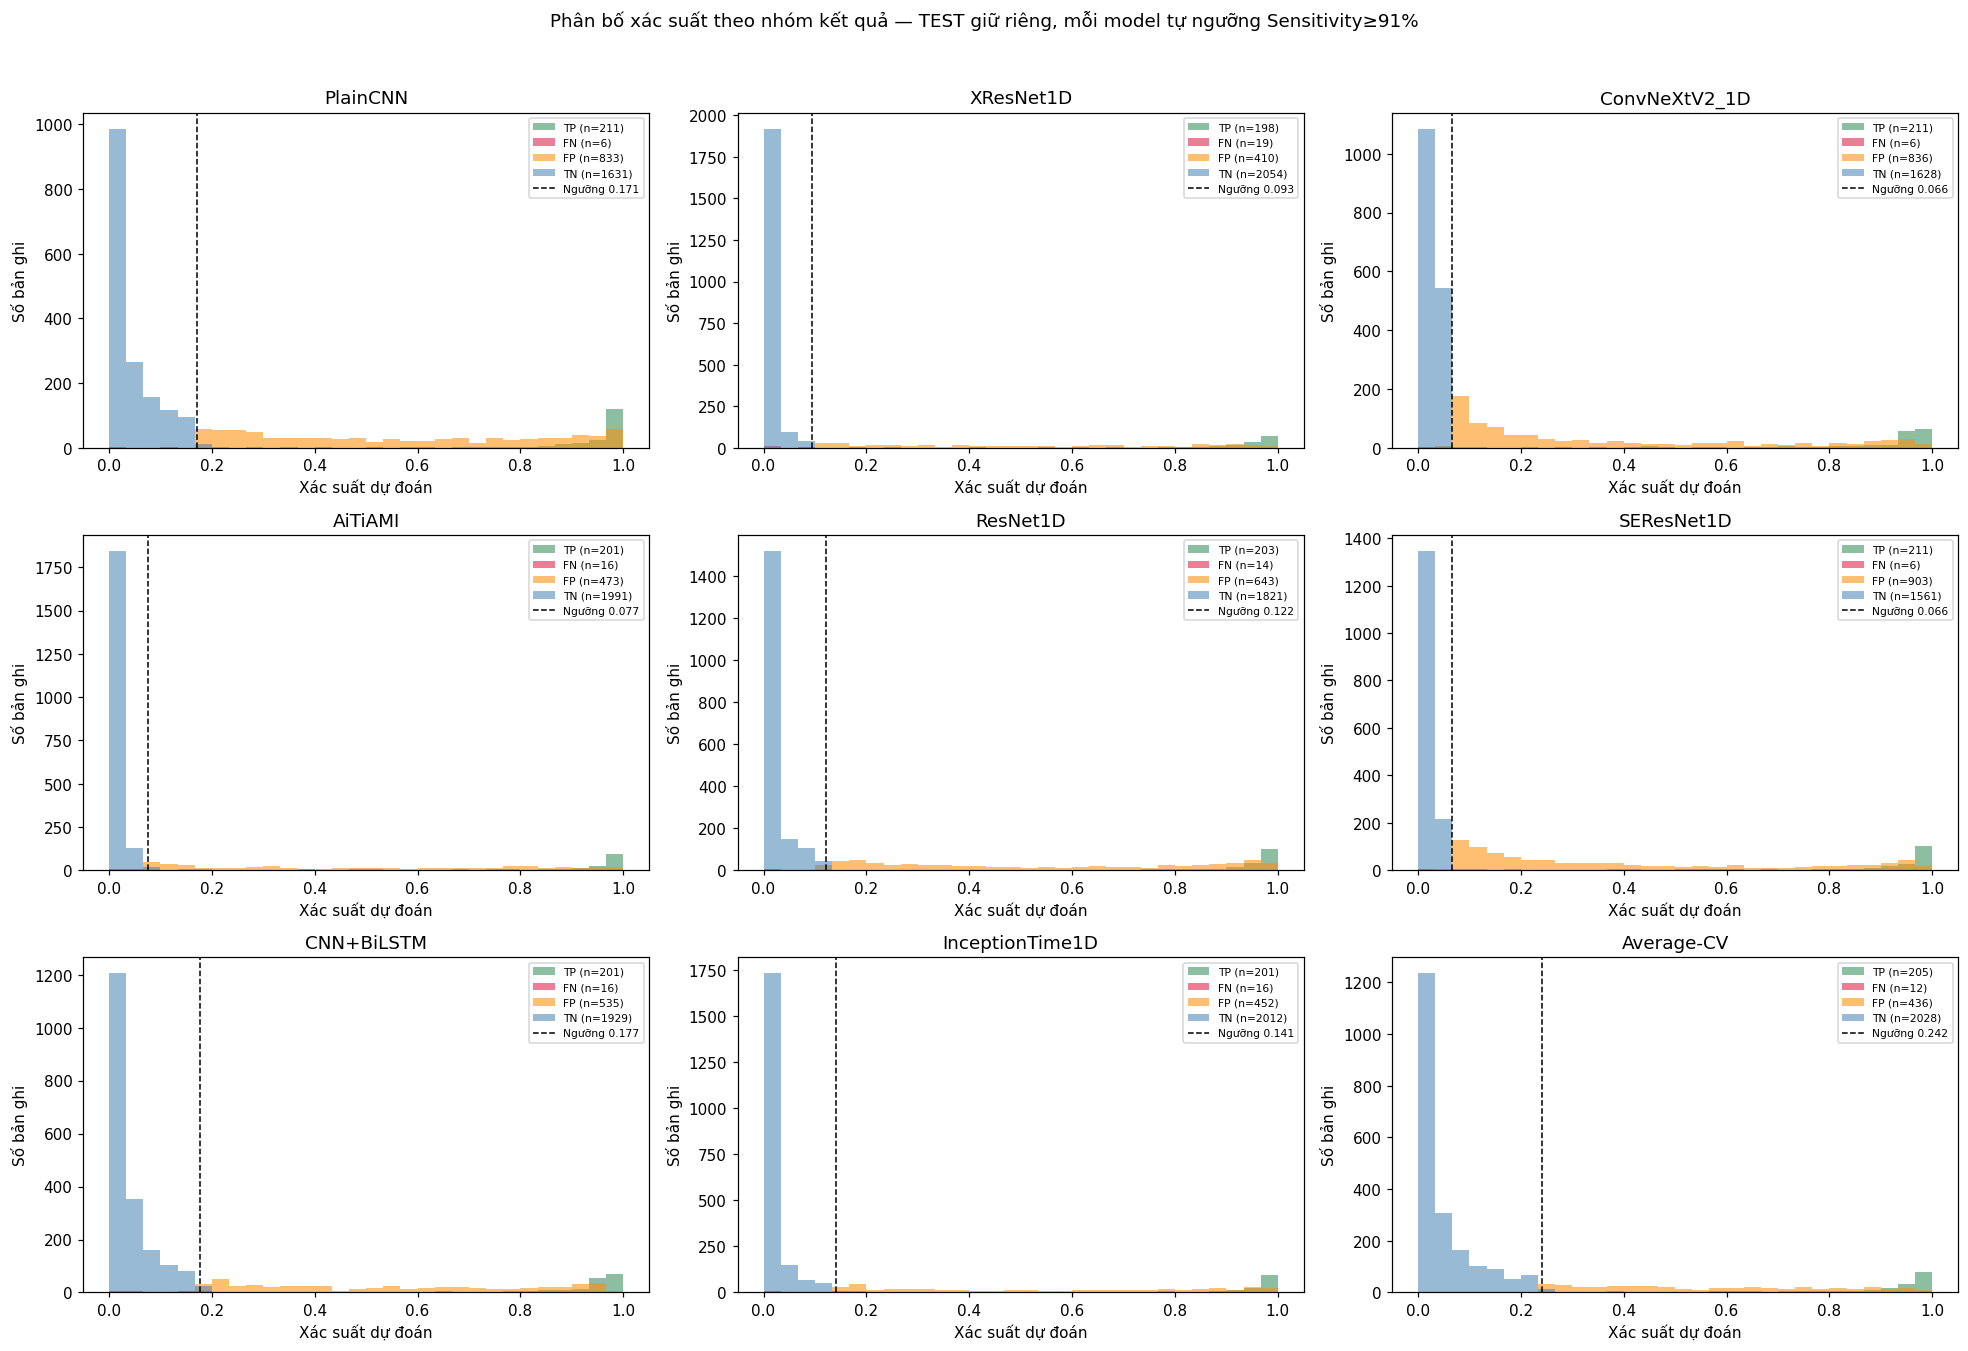

In [42]:
ALL_NAMES = CANDIDATES + ["Average-CV"]
n_cols = 3
n_rows = -(-len(ALL_NAMES) // n_cols)   # ceil

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, name in zip(axes, ALL_NAMES):
    thr_i = threshold_at_sensitivity(y[VALID], OOF_P[name][0][VALID], TARGET_SENS_PRIMARY)
    p_test_i = TEST_P_FINAL[name]
    pred_i = (p_test_i >= thr_i).astype(int)

    outcome_i = np.where((y_test == 1) & (pred_i == 1), "TP",
                np.where((y_test == 1) & (pred_i == 0), "FN",
                np.where((y_test == 0) & (pred_i == 1), "FP", "TN")))

    for lbl, color in [("TP", "seagreen"), ("FN", "crimson"), ("FP", "darkorange"), ("TN", "steelblue")]:
        ax.hist(p_test_i[outcome_i == lbl], bins=30, range=(0, 1), alpha=0.55, color=color,
                label=f"{lbl} (n={int((outcome_i == lbl).sum())})")
    ax.axvline(thr_i, color="black", ls="--", lw=1, label=f"Ngưỡng {thr_i:.3f}")
    ax.set_xlabel("Xác suất dự đoán")
    ax.set_ylabel("Số bản ghi")
    ax.set_title(name)
    ax.legend(fontsize=7)

for ax in axes[len(ALL_NAMES):]:
    ax.axis("off")

fig.suptitle("Phân bố xác suất theo nhóm kết quả — TEST giữ riêng, mỗi model tự ngưỡng Sensitivity≥91%", y=1.02)
plt.tight_layout()
plt.show()


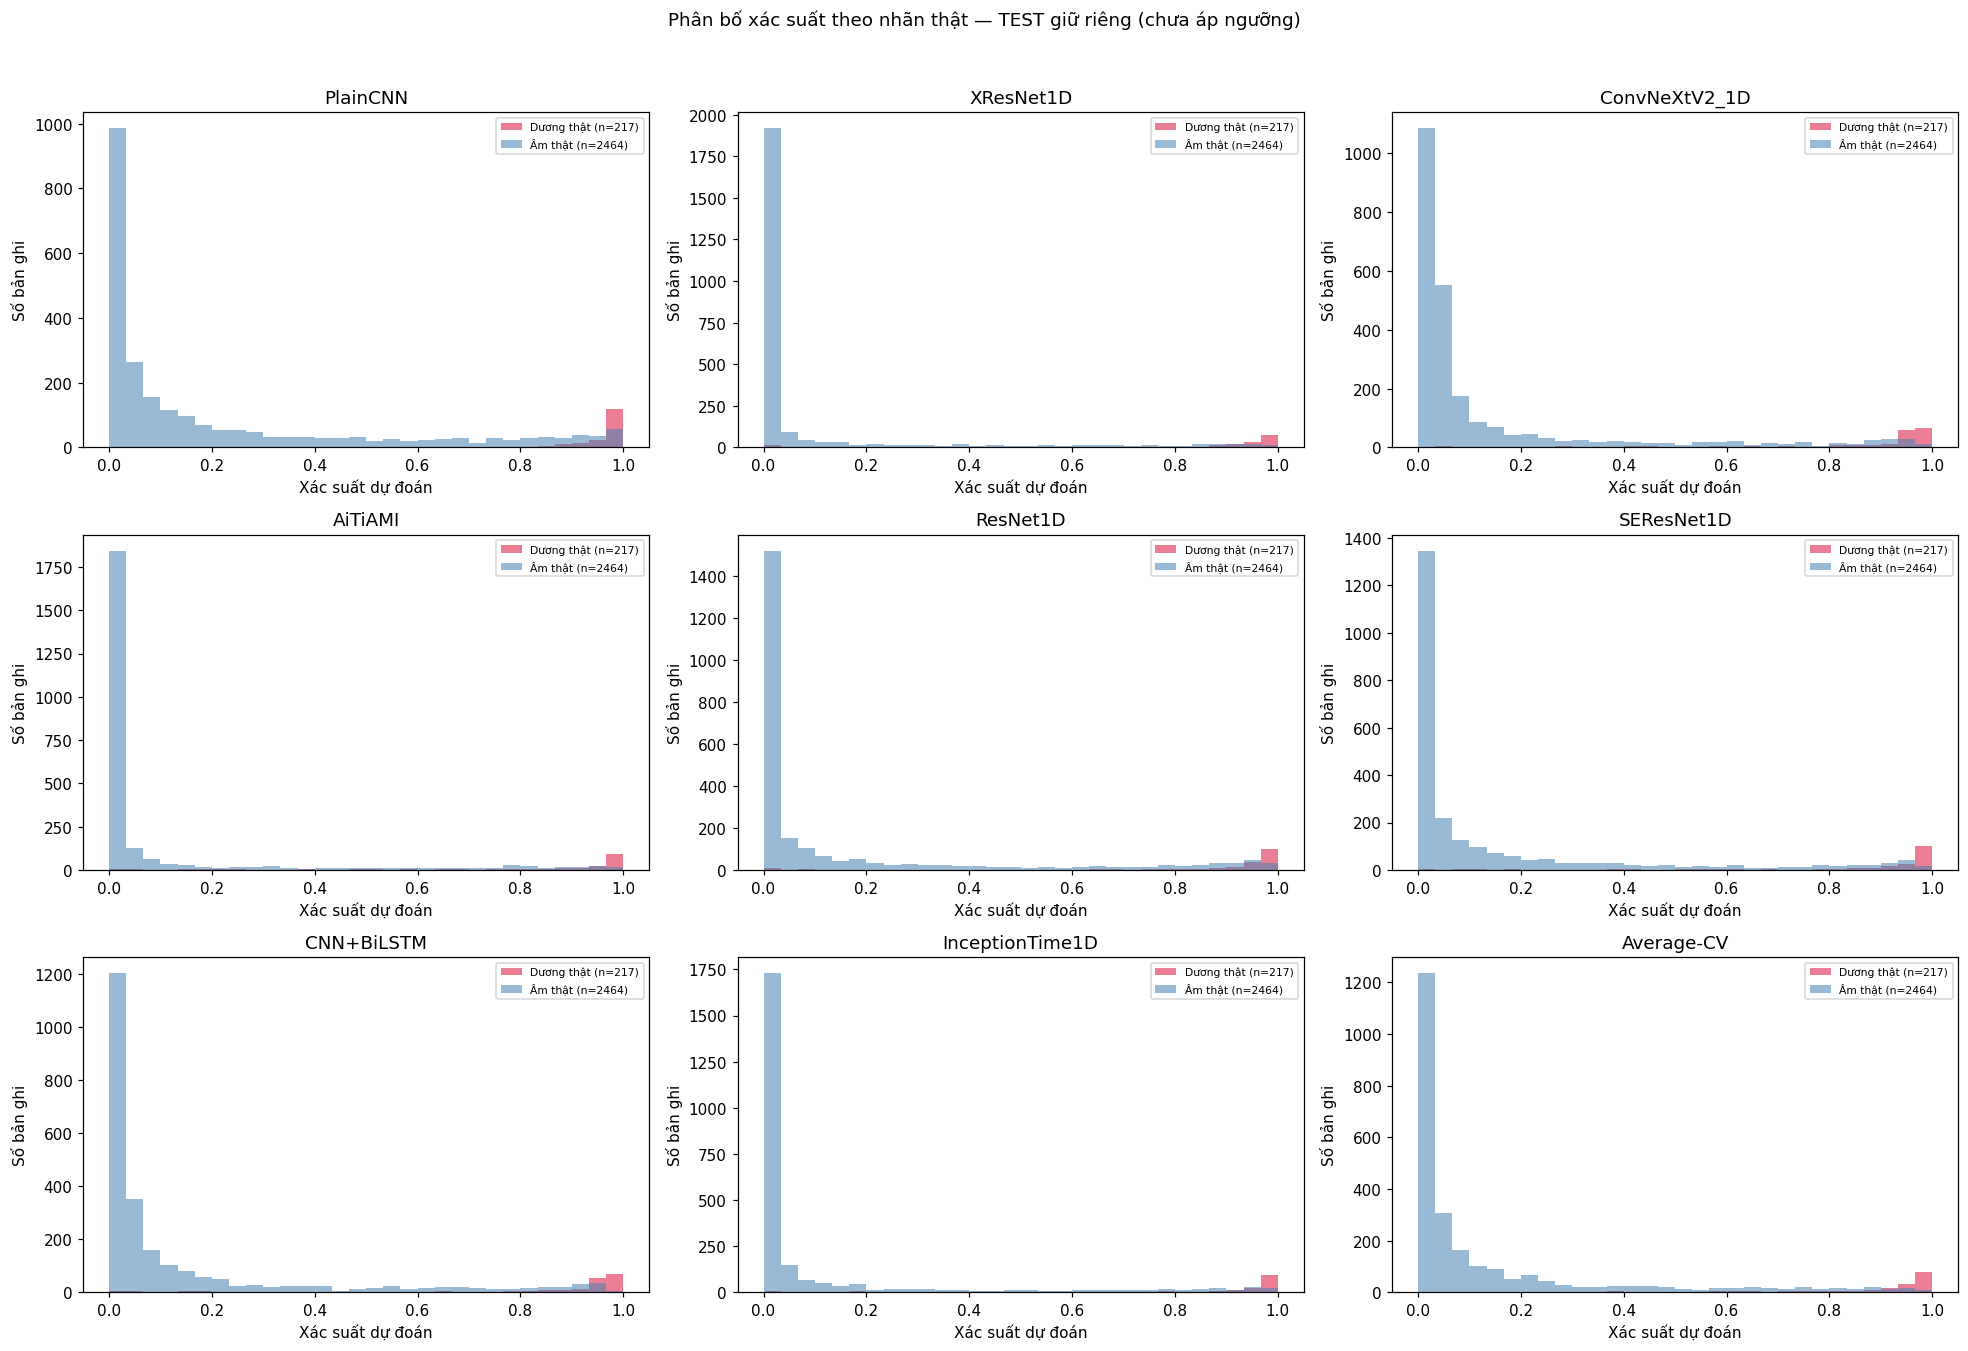

In [43]:
ALL_NAMES = CANDIDATES + ["Average-CV"]
n_cols = 3
n_rows = -(-len(ALL_NAMES) // n_cols)   # ceil

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, name in zip(axes, ALL_NAMES):
    p_test_i = TEST_P_FINAL[name]

    ax.hist(p_test_i[y_test == 1], bins=30, range=(0, 1), alpha=0.55, color="crimson",
            label=f"Dương thật (n={int((y_test == 1).sum())})")
    ax.hist(p_test_i[y_test == 0], bins=30, range=(0, 1), alpha=0.55, color="steelblue",
            label=f"Âm thật (n={int((y_test == 0).sum())})")
    ax.set_xlabel("Xác suất dự đoán")
    ax.set_ylabel("Số bản ghi")
    ax.set_title(name)
    ax.legend(fontsize=7)

for ax in axes[len(ALL_NAMES):]:
    ax.axis("off")

fig.suptitle("Phân bố xác suất theo nhãn thật — TEST giữ riêng (chưa áp ngưỡng)", y=1.02)
plt.tight_layout()
plt.show()


## 24. TIP-STEMI-05 — Ensemble với hiệu chuẩn Platt cross-fit riêng từng model

So sánh biến thể ensemble mới `Average-Calibrated` (Platt scaling cross-fit cho từng model trước khi trung bình cộng) với `Average-CV` gốc — không train lại model, chỉ hậu xử lý xác suất đã lưu. Cả hai biến thể được giữ song song để đối chiếu.

In [44]:
from sklearn.linear_model import LogisticRegression

OOF_P["Average-Calibrated"] = np.full((N_REPEATS, len(df)), np.nan)
for rep in range(N_REPEATS):
    for k in range(N_FOLDS_RUN):
        m_fold = FOLD_ID[rep] == k
        if not m_fold.any():
            continue
        other_folds = (FOLD_ID[rep] != k) & (FOLD_ID[rep] >= 0)
        calibrated_probs = []
        for name in CANDIDATES:
            lr = LogisticRegression()
            lr.fit(OOF_P[name][rep, other_folds].reshape(-1, 1), y[other_folds])
            p_cal = lr.predict_proba(OOF_P[name][rep, m_fold].reshape(-1, 1))[:, 1]
            calibrated_probs.append(p_cal)
        OOF_P["Average-Calibrated"][rep, m_fold] = np.mean(calibrated_probs, axis=0)
print("OOF_P['Average-Calibrated'] đã tạo xong, không ghi đè Average-CV/WBF-CV.")

OOF_P['Average-Calibrated'] đã tạo xong, không ghi đè Average-CV/WBF-CV.


In [45]:
_calibrated_test_probs = []
for name in CANDIDATES:
    lr = LogisticRegression()
    lr.fit(OOF_P[name][0, VALID].reshape(-1, 1), y[VALID])
    _calibrated_test_probs.append(lr.predict_proba(TEST_P_FINAL[name].reshape(-1, 1))[:, 1])
TEST_P_FINAL["Average-Calibrated"] = np.mean(_calibrated_test_probs, axis=0)
print("TEST_P_FINAL['Average-Calibrated'] đã tạo xong.")

TEST_P_FINAL['Average-Calibrated'] đã tạo xong.


In [46]:
_rows = []
for name in ["Average-CV", "Average-Calibrated"]:
    thr_i = threshold_at_sensitivity(y[VALID], OOF_P[name][0][VALID], TARGET_SENS_PRIMARY)
    m = compute_metrics(y_test, TEST_P_FINAL[name], thr_i)
    _rows.append({
        "Ensemble": name, "Ngưỡng (Sens>=91% trên OOF)": round(thr_i, 4),
        "AUROC (TEST)": round(roc_auc_score(y_test, TEST_P_FINAL[name]), 4),
        "AUPRC (TEST)": round(average_precision_score(y_test, TEST_P_FINAL[name]), 4),
        "Sensitivity": round(m["sensitivity"], 4), "Specificity": round(m["specificity"], 4),
        "TP": m["tp"], "FN": m["fn"], "FP": m["fp"], "TN": m["tn"],
    })
_cmp_df = pd.DataFrame(_rows)
print("So sánh Average-CV (gốc) vs Average-Calibrated (Platt cross-fit từng model):")
display(_cmp_df)
print("\nKết quả này trung thực dù Average-Calibrated có cải thiện hay không -- việc hiệu "
      "chuẩn không cải thiện AUPRC vẫn là kết quả hợp lệ cần báo cáo, không phải lỗi cần sửa.")

So sánh Average-CV (gốc) vs Average-Calibrated (Platt cross-fit từng model):


,Ensemble,Ngưỡng (Sens>=91% trên OOF),AUROC (TEST),AUPRC (TEST),Sensitivity,Specificity,TP,FN,FP,TN
0,Average-CV,0.2417,0.9517,0.7435,0.9447,0.8231,205,12,436,2028
1,Average-Calibrated,0.0653,0.9509,0.7436,0.9447,0.8275,205,12,425,2039



Kết quả này trung thực dù Average-Calibrated có cải thiện hay không -- việc hiệu chuẩn không cải thiện AUPRC vẫn là kết quả hợp lệ cần báo cáo, không phải lỗi cần sửa.
